In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import r2_score, mean_squared_error

In [16]:
df = pd.read_excel("Latihan UV Vis 21 Juli 2022.xlsx")

print("Ukuran Dataset Awal :", df.shape)

display(df.head())

Ukuran Dataset Awal : (5, 186)


,No.,Type,Name,Date/Time,Note,200,205,210,215,220,...,1055,1060,1065,1070,1075,1080,1085,1090,1095,1100
0,1,Sample,UV 1264,2022-07-20 15:02:00,NaN,4.8830,4.6093,4.3077,3.9963,3.6904,...,0.2748,0.2741,0.2733,0.2726,0.2719,0.2711,0.2702,0.2692,0.2681,0.2669
1,2,Sample,UV 1265,2022-07-20 15:13:00,NaN,6.0962,5.5991,5.0360,4.4370,3.8294,...,0.1760,0.1747,0.1733,0.1721,0.1708,0.1695,0.1683,0.1670,0.1657,0.1644
2,3,Sample,UV 1266,2022-07-20 15:11:00,NaN,5.2437,5.1079,4.9146,4.6848,4.4369,...,0.1762,0.1748,0.1735,0.1722,0.1709,0.1697,0.1685,0.1673,0.1661,0.1649
3,4,Sample,UV 1267,2022-07-20 15:19:00,NaN,1.4835,1.4050,1.3324,1.2672,1.2108,...,0.1498,0.1481,0.1465,0.1450,0.1434,0.1420,0.1405,0.1392,0.1378,0.1365
4,5,Sample,UV 1268,2022-07-20 15:22:00,NaN,0.8686,1.0941,1.2534,1.3570,1.4148,...,0.3507,0.3501,0.3495,0.3489,0.3483,0.3476,0.3469,0.3461,0.3452,0.3442


In [17]:
drop_cols = [
    'No.',
    'Type',
    'Date/Time',
    'Note'
]

df_clean = df.drop(
    columns=drop_cols,
    errors='ignore'
)

print("Ukuran Setelah Cleaning :", df_clean.shape)

display(df_clean.head())

Ukuran Setelah Cleaning : (5, 182)


,Name,200,205,210,215,220,225,230,235,240,...,1055,1060,1065,1070,1075,1080,1085,1090,1095,1100
0,UV 1264,4.8830,4.6093,4.3077,3.9963,3.6904,3.4028,3.1441,2.9223,2.7428,...,0.2748,0.2741,0.2733,0.2726,0.2719,0.2711,0.2702,0.2692,0.2681,0.2669
1,UV 1265,6.0962,5.5991,5.0360,4.4370,3.8294,3.2368,2.6797,2.1752,1.7371,...,0.1760,0.1747,0.1733,0.1721,0.1708,0.1695,0.1683,0.1670,0.1657,0.1644
2,UV 1266,5.2437,5.1079,4.9146,4.6848,4.4369,4.1872,3.9494,3.7349,3.5529,...,0.1762,0.1748,0.1735,0.1722,0.1709,0.1697,0.1685,0.1673,0.1661,0.1649
3,UV 1267,1.4835,1.4050,1.3324,1.2672,1.2108,1.1642,1.1279,1.1021,1.0870,...,0.1498,0.1481,0.1465,0.1450,0.1434,0.1420,0.1405,0.1392,0.1378,0.1365
4,UV 1268,0.8686,1.0941,1.2534,1.3570,1.4148,1.4359,1.4285,1.4000,1.3570,...,0.3507,0.3501,0.3495,0.3489,0.3483,0.3476,0.3469,0.3461,0.3452,0.3442


In [18]:
# Ambil kolom wavelength

wavelength_cols = [
    col for col in df_clean.columns
    if isinstance(col, (int, float))
]

print("Jumlah wavelength :", len(wavelength_cols))

print("Wavelength pertama :", wavelength_cols)

Jumlah wavelength : 181
Wavelength pertama : [200, 205, 210, 215, 220, 225, 230, 235, 240, 245, 250, 255, 260, 265, 270, 275, 280, 285, 290, 295, 300, 305, 310, 315, 320, 325, 330, 335, 340, 345, 350, 355, 360, 365, 370, 375, 380, 385, 390, 395, 400, 405, 410, 415, 420, 425, 430, 435, 440, 445, 450, 455, 460, 465, 470, 475, 480, 485, 490, 495, 500, 505, 510, 515, 520, 525, 530, 535, 540, 545, 550, 555, 560, 565, 570, 575, 580, 585, 590, 595, 600, 605, 610, 615, 620, 625, 630, 635, 640, 645, 650, 655, 660, 665, 670, 675, 680, 685, 690, 695, 700, 705, 710, 715, 720, 725, 730, 735, 740, 745, 750, 755, 760, 765, 770, 775, 780, 785, 790, 795, 800, 805, 810, 815, 820, 825, 830, 835, 840, 845, 850, 855, 860, 865, 870, 875, 880, 885, 890, 895, 900, 905, 910, 915, 920, 925, 930, 935, 940, 945, 950, 955, 960, 965, 970, 975, 980, 985, 990, 995, 1000, 1005, 1010, 1015, 1020, 1025, 1030, 1035, 1040, 1045, 1050, 1055, 1060, 1065, 1070, 1075, 1080, 1085, 1090, 1095, 1100]


In [19]:
wavelength = np.array(
    wavelength_cols
)

print(wavelength.shape)

print(wavelength)

(181,)
[ 200  205  210  215  220  225  230  235  240  245  250  255  260  265
  270  275  280  285  290  295  300  305  310  315  320  325  330  335
  340  345  350  355  360  365  370  375  380  385  390  395  400  405
  410  415  420  425  430  435  440  445  450  455  460  465  470  475
  480  485  490  495  500  505  510  515  520  525  530  535  540  545
  550  555  560  565  570  575  580  585  590  595  600  605  610  615
  620  625  630  635  640  645  650  655  660  665  670  675  680  685
  690  695  700  705  710  715  720  725  730  735  740  745  750  755
  760  765  770  775  780  785  790  795  800  805  810  815  820  825
  830  835  840  845  850  855  860  865  870  875  880  885  890  895
  900  905  910  915  920  925  930  935  940  945  950  955  960  965
  970  975  980  985  990  995 1000 1005 1010 1015 1020 1025 1030 1035
 1040 1045 1050 1055 1060 1065 1070 1075 1080 1085 1090 1095 1100]


## Transformasi Data

In [20]:
def transform_sample(df_clean, sample_index):

    sample_name = df_clean.iloc[
        sample_index
    ]['Name']

    absorbance = df_clean.iloc[
        sample_index
    ][wavelength_cols].values

    transformed = pd.DataFrame({

        'Wavelength': wavelength,

        'Absorbance': absorbance

    })

    return sample_name, transformed

In [21]:
for i in range(len(df_clean)):

    sample_name, data = transform_sample(
        df_clean,
        i
    )

    print("\n")
    print("="*30)
    print(sample_name)
    print("="*30)

    display(data)



UV 1264


,Wavelength,Absorbance
0,200,4.883
1,205,4.6093
2,210,4.3077
3,215,3.9963
4,220,3.6904
...,...,...
176,1080,0.2711
177,1085,0.2702
178,1090,0.2692
179,1095,0.2681




UV 1265


,Wavelength,Absorbance
0,200,6.0962
1,205,5.5991
2,210,5.036
3,215,4.437
4,220,3.8294
...,...,...
176,1080,0.1695
177,1085,0.1683
178,1090,0.167
179,1095,0.1657




UV 1266


,Wavelength,Absorbance
0,200,5.2437
1,205,5.1079
2,210,4.9146
3,215,4.6848
4,220,4.4369
...,...,...
176,1080,0.1697
177,1085,0.1685
178,1090,0.1673
179,1095,0.1661




UV 1267


,Wavelength,Absorbance
0,200,1.4835
1,205,1.405
2,210,1.3324
3,215,1.2672
4,220,1.2108
...,...,...
176,1080,0.142
177,1085,0.1405
178,1090,0.1392
179,1095,0.1378




UV 1268


,Wavelength,Absorbance
0,200,0.8686
1,205,1.0941
2,210,1.2534
3,215,1.357
4,220,1.4148
...,...,...
176,1080,0.3476
177,1085,0.3469
178,1090,0.3461
179,1095,0.3452


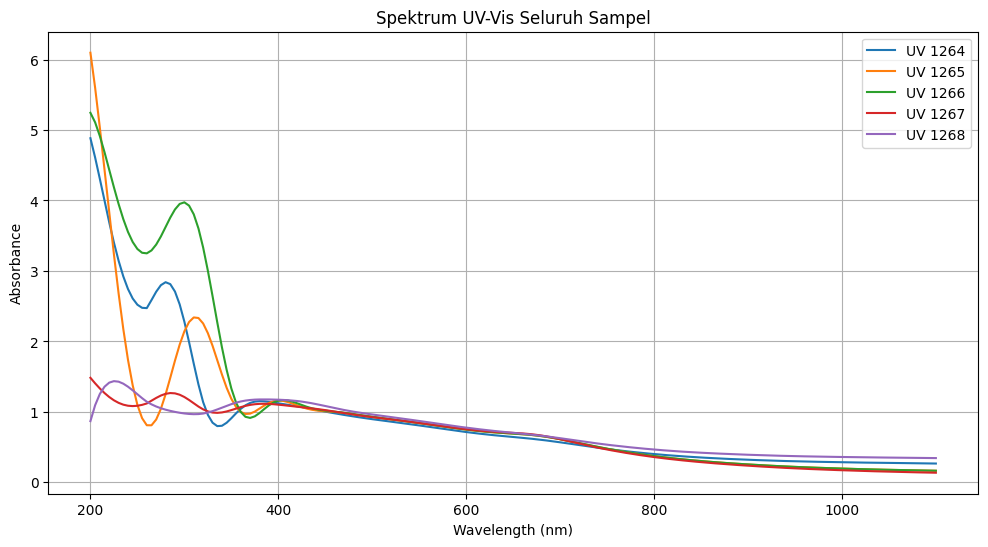

In [22]:
plt.figure(figsize=(12,6))

for i in range(len(df_clean)):

    sample_name = df_clean.iloc[i]['Name']

    absorbance = df_clean.iloc[
        i
    ][wavelength_cols].values

    plt.plot(

        wavelength,

        absorbance,

        label=sample_name

    )

plt.xlabel(
    'Wavelength (nm)'
)

plt.ylabel(
    'Absorbance'
)

plt.title(
    'Spektrum UV-Vis Seluruh Sampel'
)

plt.legend()

plt.grid(True)

plt.show()

## Evaluasi Model

In [23]:
def evaluate_model(model_name, y_test, y_pred):

    r2 = r2_score(
        y_test,
        y_pred
    )
    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            y_pred
        )
    )

    return [
        model_name,
        r2,
        rmse
    ]

## Fungsi Visualisasi

In [37]:
# Menampilkan setiap grafik prediksi terhadap data pembanding
def plot_comparison_grid(
        comparison_df,
        predictions,
        evaluation_df,
        sample_name,
        comparison_name,
        split_label):

    fig = plt.figure(figsize=(14, 10))

    # Layout 2 atas 1 bawah
    gs = fig.add_gridspec(2, 2)

    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[0, 1])
    ax3 = fig.add_subplot(gs[1, :])   # memenuhi satu baris

    axes = [ax1, ax2, ax3]

    model_names = [
        "Linear Regression",
        "Polynomial Regression",
        "Random Forest"
    ]

    for ax, model in zip(axes, model_names):

        ax.plot(
            comparison_df["Wavelength"],
            comparison_df["Absorbance"],
            color="blue",
            linewidth=2.5,
            label=f"Aktual ({comparison_name})"
        )

        ax.plot(
            comparison_df["Wavelength"],
            predictions[model],
            '--',
            color="red",
            linewidth=2,
            label="Prediksi"
        )

        ax.set_title(model, fontsize=12, fontweight='bold')
        ax.set_xlabel("Wavelength (nm)")
        ax.set_ylabel("Absorbance")
        ax.grid(True, alpha=0.3)

        # Legend di masing-masing grafik
        ax.legend(
            loc="upper right",
            fontsize=9
        )

        r2 = evaluation_df.loc[
            evaluation_df["Model"] == model,
            "R2"
        ].values[0]

        rmse = evaluation_df.loc[
            evaluation_df["Model"] == model,
            "RMSE"
        ].values[0]

        ax.text(
            0.03,
            0.97,
            f"R² = {r2:.3f}\nRMSE = {rmse:.3f}",
            transform=ax.transAxes,
            fontsize=9,
            verticalalignment='top',
            bbox=dict(
                facecolor='white',
                edgecolor='gray',
                alpha=0.8
            )
        )

    fig.suptitle(
        f"Perbandingan Prediksi {sample_name} terhadap Data Pembanding {comparison_name}\nSplit {split_label}",
        fontsize=16,
        fontweight="bold"
    )

    plt.tight_layout(rect=[0, 0, 1, 0.94])

    plt.savefig(
        f"Compare_{sample_name}_{comparison_name}_{split_label}.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()

# Menampilkan semua grafik prediksi terhadap data test

def plot_test_grid(
        X_test,
        y_test,
        predictions,
        evaluation_df,
        sample_name,
        split_label):

    fig = plt.figure(figsize=(14,10))

    gs = fig.add_gridspec(2,2)

    ax1 = fig.add_subplot(gs[0,0])
    ax2 = fig.add_subplot(gs[0,1])
    ax3 = fig.add_subplot(gs[1,:])

    axes = [ax1, ax2, ax3]

    model_names = [
        "Linear Regression",
        "Polynomial Regression",
        "Random Forest"
    ]

    wavelength = X_test.flatten()

    idx = np.argsort(wavelength)

    wavelength = wavelength[idx]
    y_actual = y_test[idx]

    for ax, model in zip(axes, model_names):

        pred = predictions[model][idx]

        r2 = evaluation_df.loc[
            evaluation_df["Model"] == model,
            "R2"
        ].values[0]

        rmse = evaluation_df.loc[
            evaluation_df["Model"] == model,
            "RMSE"
        ].values[0]

        ax.plot(
            wavelength,
            y_actual,
            linewidth=3,
            color="blue",
            label=f"Aktual ({sample_name})"
        )

        ax.plot(
            wavelength,
            pred,
            "--",
            linewidth=2,
            color="red",
            label="Prediksi"
        )

        ax.set_title(
            model,
            fontsize=12,
            fontweight="bold"
        )

        ax.set_xlabel("Wavelength (nm)")
        ax.set_ylabel("Absorbance")

        ax.grid(True, alpha=0.3)

        ax.legend(fontsize=9)

        ax.text(
            0.03,
            0.97,
            f"R² = {r2:.3f}\nRMSE = {rmse:.3f}",
            transform=ax.transAxes,
            fontsize=9,
            verticalalignment='top',
            bbox=dict(
                facecolor='white',
                alpha=0.8
            )
        )

    fig.suptitle(
        f"Hasil Prediksi terhadap Spektrum {sample_name}\nSplit {split_label}",
        fontsize=16,
        fontweight="bold"
    )

    plt.tight_layout(rect=[0,0,1,0.95])
    
    plt.savefig(
        f"Test_{sample_name}_{split_label}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

## Main Function

In [38]:
def run_sample(
        sample_name,
        transformed_data,
        test_size=0.3,
        show_plot=True):

    print("\n")
    print("="*60)
    print(
        f"SAMPEL : {sample_name}"
    )
    print("="*60)
    
    split_label = (
        f"{int((1-test_size)*100)}:"
        f"{int(test_size*100)}"
    )

    # Bentuk X dan y

    X = transformed_data[['Wavelength']].values
    y = transformed_data['Absorbance'].values
    print("Shape X :",X.shape)
    print("Shape y :",y.shape)

    # Split Data

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        shuffle=True,
        random_state=42
    )

    # Tampilkan Train dan Test

    train_df = pd.DataFrame({

        'Wavelength':
            X_train.flatten(),
        'Absorbance':
            y_train
    })

    test_df = pd.DataFrame({

        'Wavelength':
            X_test.flatten(),
        'Absorbance':
            y_test
    })

    print("\nTRAIN DATA")
    display(train_df)

    print("\nTEST DATA")
    display(test_df)

    # StandardScaler

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    X_full_scaled = scaler.transform(X)
    results = []
    trained_models = {}
    test_predictions = {}

    # Linear Regression

    linear = LinearRegression() 
    linear.fit(
        X_train_scaled,
        y_train
    )
    pred_test = linear.predict(
        X_test_scaled
    )
    pred_full = linear.predict(
        X_full_scaled
    )

    trained_models["Linear Regression"] = linear
    test_predictions["Linear Regression"] = pred_test

    # # Residu
    # residu = y_test - pred_test

    # df_residu = pd.DataFrame({
    # 'Wavelength': X_test.flatten(),
    # 'Aktual': y_test,
    # 'Prediksi': pred_test,
    # 'Residu': residu
    # })
    # df_residu = df_residu.sort_values(
    #     by='Wavelength'
    # ).reset_index(drop=True)

    # print("\nResidu Linear Regression")
    # display(df_residu)

    results.append(
        evaluate_model(
            "Linear Regression",
            y_test,
            pred_test
        )
    )

    # Polynomial Regression

    poly = Pipeline([
        ('poly',PolynomialFeatures(degree=2, include_bias=False)),
        ('linear', LinearRegression())
    ])
    poly.fit(
        X_train_scaled,
        y_train
    )
    pred_test = poly.predict(
        X_test_scaled
    )
    pred_full = poly.predict(
        X_full_scaled
    )
    
    trained_models["Polynomial Regression"] = poly
    test_predictions["Polynomial Regression"] = pred_test

    # residu = y_test - pred_test
    # df_residu = pd.DataFrame({
    # 'Wavelength': X_test.flatten(),
    # 'Aktual': y_test,
    # 'Prediksi': pred_test,
    # 'Residu': residu
    # })
    # df_residu = df_residu.sort_values(
    #     by='Wavelength'
    # ).reset_index(drop=True)

    # print("\nResidu Polynomial Regression")
    # display(df_residu)

    results.append(
        evaluate_model(
            "Polynomial Regression",
            y_test,
            pred_test
        )
    )

    # Random Forest

    rf = RandomForestRegressor(
        n_estimators=100,
        random_state=42
    )

    rf.fit(
        X_train_scaled,
        y_train
    )
    pred_test = rf.predict(
        X_test_scaled
    )
    pred_full = rf.predict(
        X_full_scaled
    )

    trained_models["Random Forest"] = rf
    test_predictions["Random Forest"] = pred_test
    
    # residu = y_test - pred_test
    # df_residu = pd.DataFrame({
    # 'Wavelength': X_test.flatten(),
    # 'Aktual': y_test,
    # 'Prediksi': pred_test,
    # 'Residu': residu
    # })
    # df_residu = df_residu.sort_values(
    #     by='Wavelength'
    # ).reset_index(drop=True)

    # print("\nResidu Random Forest")
    # display(df_residu)

    results.append(
        evaluate_model(
            "Random Forest",
            y_test,
            pred_test
        )
    )

    hasil = pd.DataFrame(
        results,
        columns=[
            "Model",
            "R2",
            "RMSE"
        ]
    )
    hasil.insert(
        0,
        "Split",
        split_label
    )

    hasil.insert(
        0,
        "Sample",
        sample_name
    )

    print("\nHASIL EVALUASI")

    display(hasil)

    plot_test_grid(
        X_test,
        y_test,
        test_predictions,
        hasil,
        sample_name,
        split_label
    )

    return hasil, trained_models, scaler
    # return hasil, best_model, best_pred

In [26]:
sample_data = {}

for i in range(len(df_clean)):

    sample_name, transformed = transform_sample(
        df_clean,
        i
    )

    sample_data[sample_name] = transformed

print(sample_data.keys())

dict_keys(['UV 1264', 'UV 1265', 'UV 1266', 'UV 1267', 'UV 1268'])


## Daftar Split Data

In [27]:
split_list = [

    0.4,   # 60:40
    0.3,   # 70:30
    0.2,   # 80:20
    0.1    # 90:10

]



SAMPEL : UV 1264
Shape X : (181, 1)
Shape y : (181,)

TRAIN DATA


,Wavelength,Absorbance
0,760,0.4573
1,220,3.6904
2,360,1.0427
3,705,0.5584
4,840,0.3606
...,...,...
103,730,0.5099
104,270,2.7046
105,660,0.6311
106,1095,0.2681



TEST DATA


,Wavelength,Absorbance
0,295,2.5257
1,410,1.1009
2,965,0.2942
3,590,0.7313
4,925,0.3086
...,...,...
68,575,0.7594
69,930,0.3065
70,255,2.4765
71,230,3.1441



HASIL EVALUASI


,Sample,Split,Model,R2,RMSE
0,UV 1264,60:40,Linear Regression,0.596734,0.521653
1,UV 1264,60:40,Polynomial Regression,0.754241,0.407231
2,UV 1264,60:40,Random Forest,0.995025,0.057941


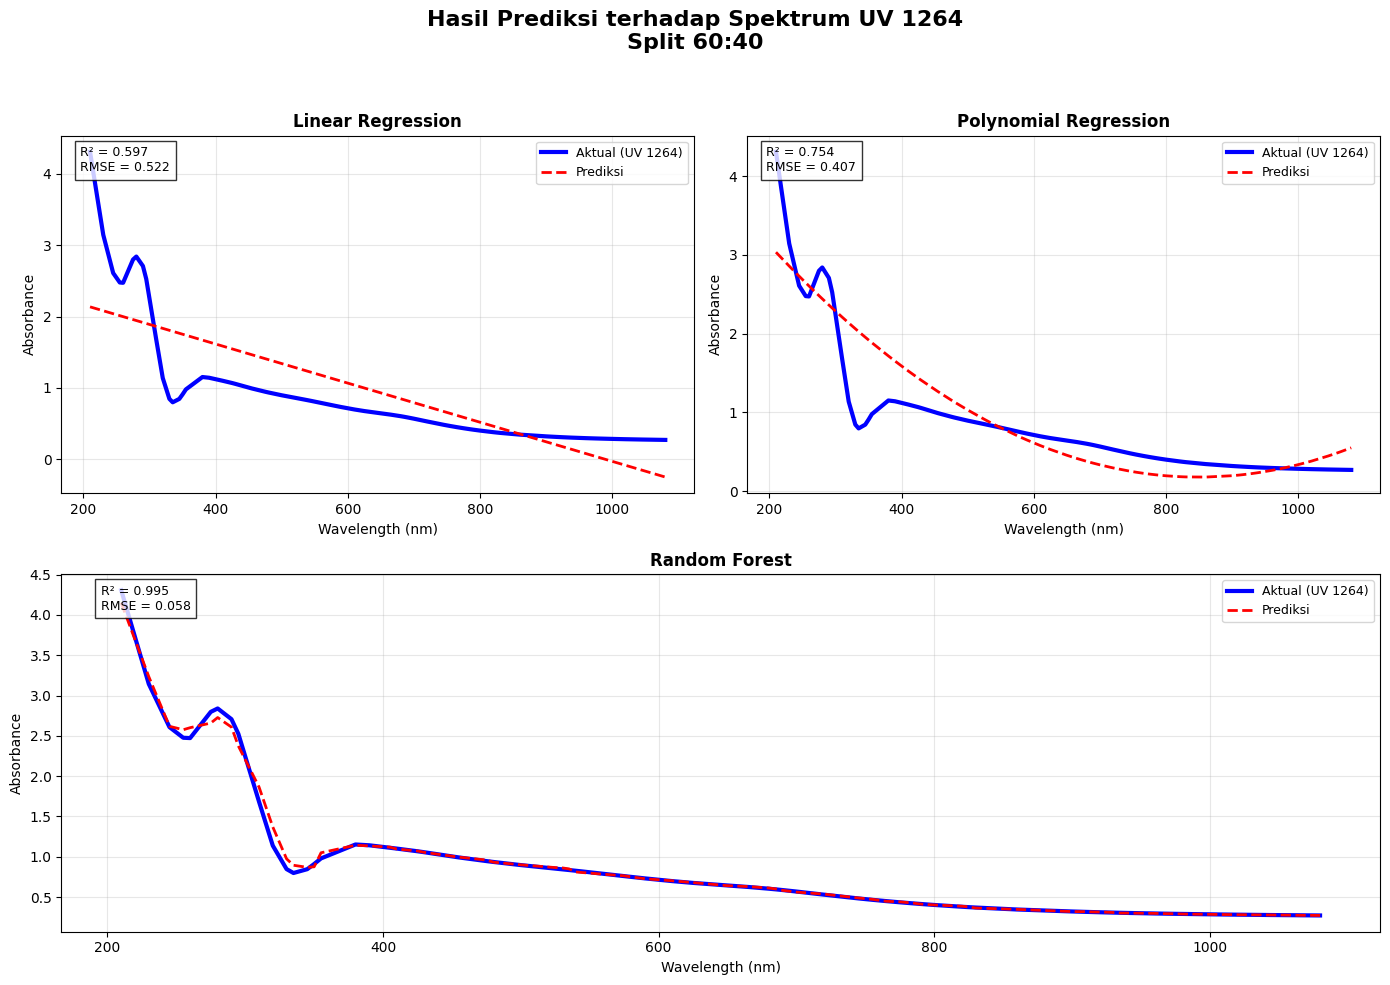

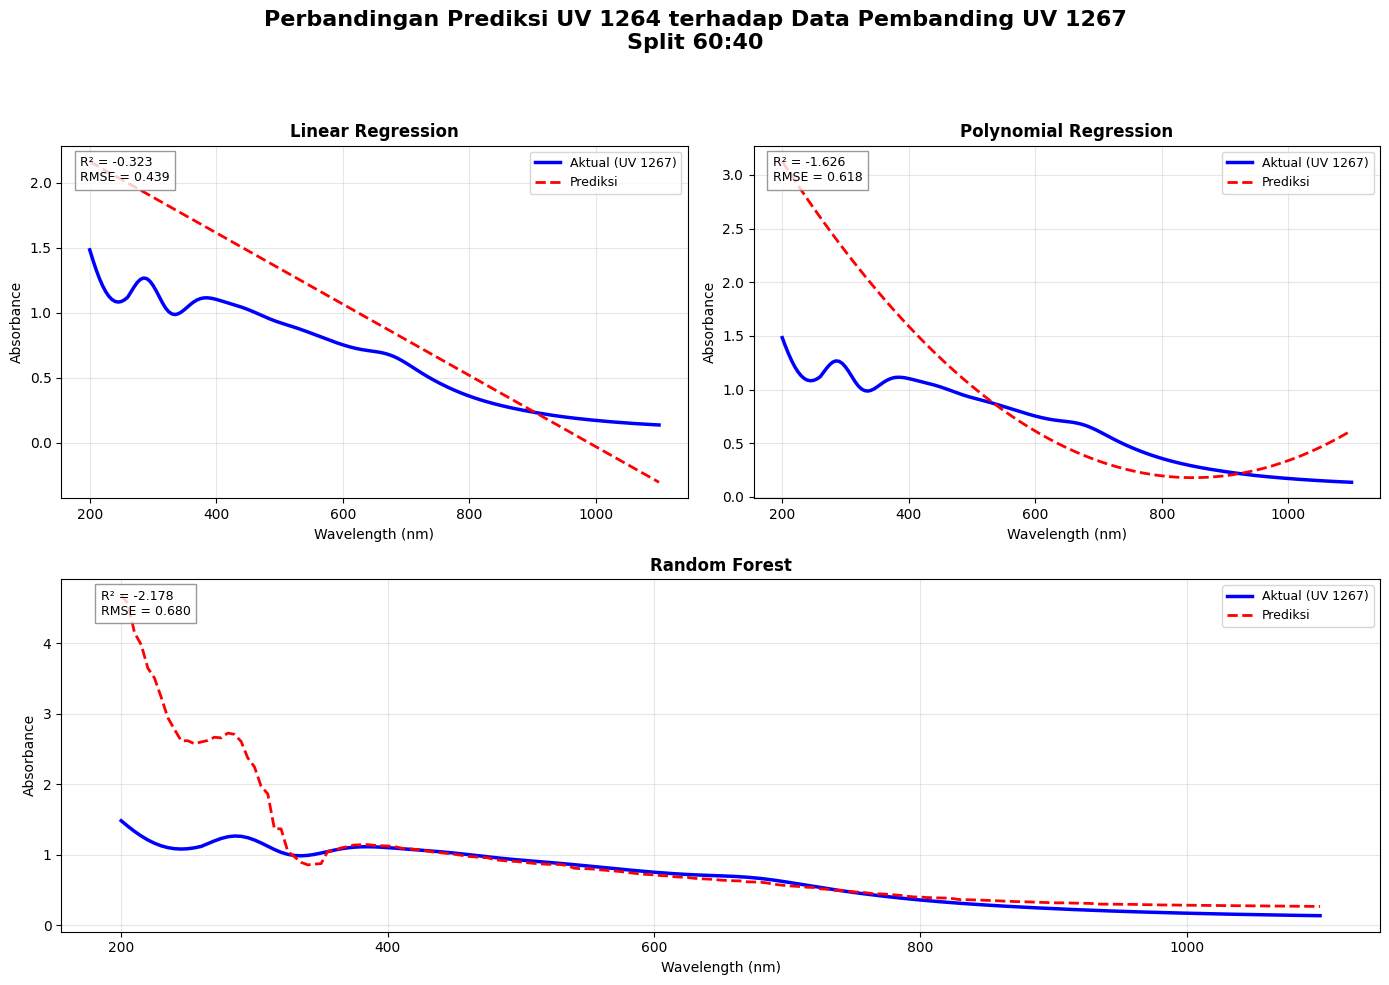

,Scenario,Sample,Comparison,Split,Model,R2,RMSE
0,Scenario 1,UV 1264,UV 1267,60:40,Linear Regression,-0.323175,0.438864
1,Scenario 1,UV 1264,UV 1267,60:40,Polynomial Regression,-1.626451,0.618309
2,Scenario 1,UV 1264,UV 1267,60:40,Random Forest,-2.177769,0.680115




SAMPEL : UV 1264
Shape X : (181, 1)
Shape y : (181,)

TRAIN DATA


,Wavelength,Absorbance
0,625,0.675
1,960,0.2957
2,610,0.6972
3,935,0.3044
4,330,0.8463
...,...,...
121,730,0.5099
122,270,2.7046
123,660,0.6311
124,1095,0.2681



TEST DATA


,Wavelength,Absorbance
0,295,2.5257
1,410,1.1009
2,965,0.2942
3,590,0.7313
4,925,0.3086
5,275,2.7978
6,320,1.1376
7,540,0.8257
8,765,0.4494
9,790,0.4139



HASIL EVALUASI


,Sample,Split,Model,R2,RMSE
0,UV 1264,70:30,Linear Regression,0.606055,0.526247
1,UV 1264,70:30,Polynomial Regression,0.796119,0.378583
2,UV 1264,70:30,Random Forest,0.996370,0.050512


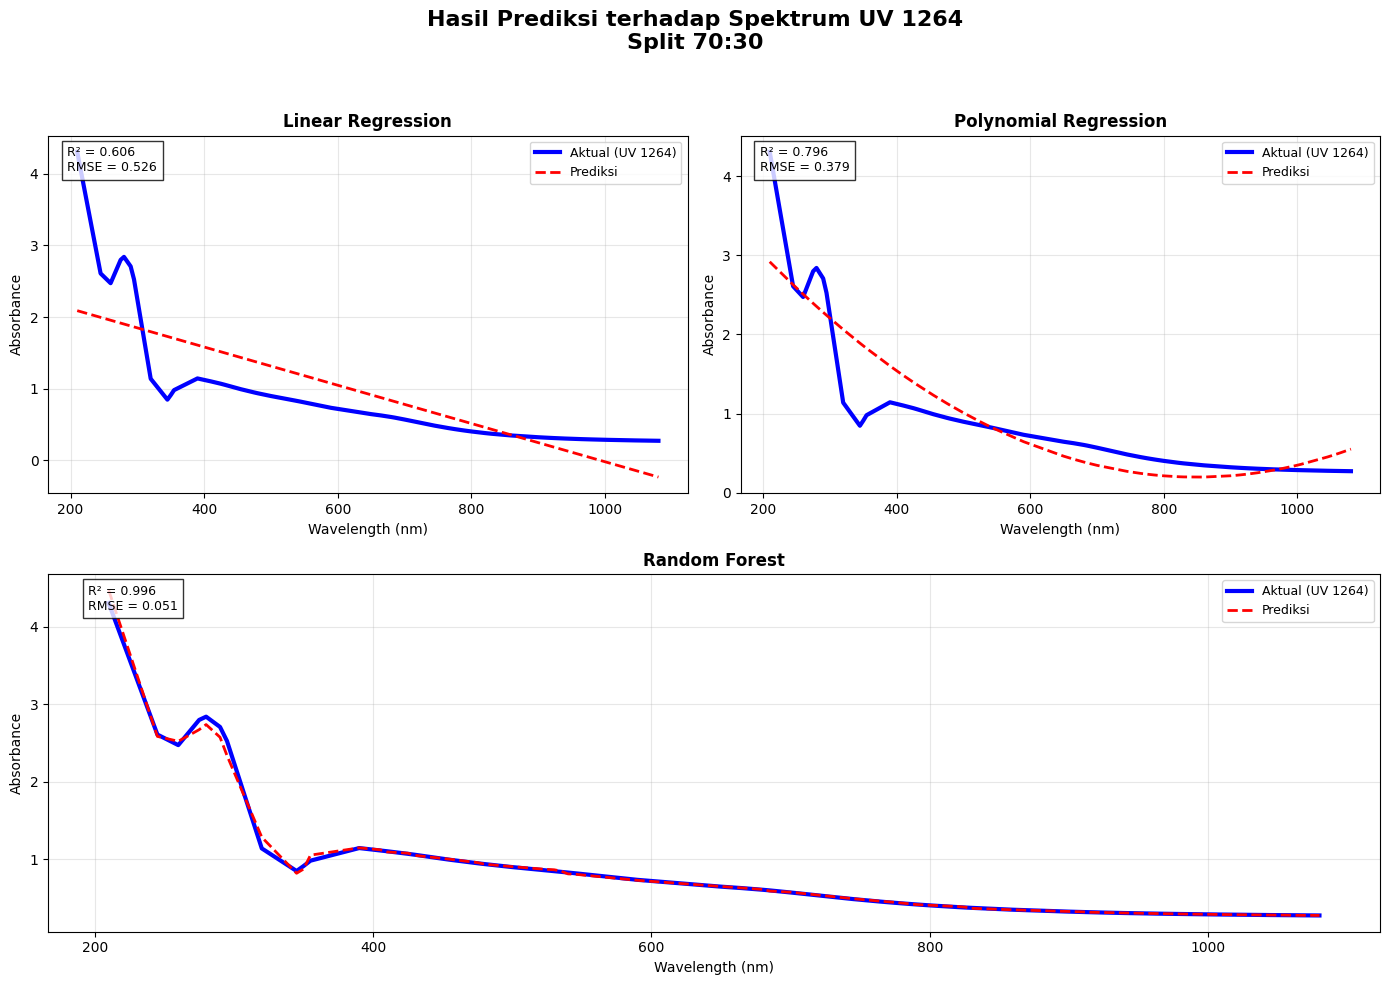

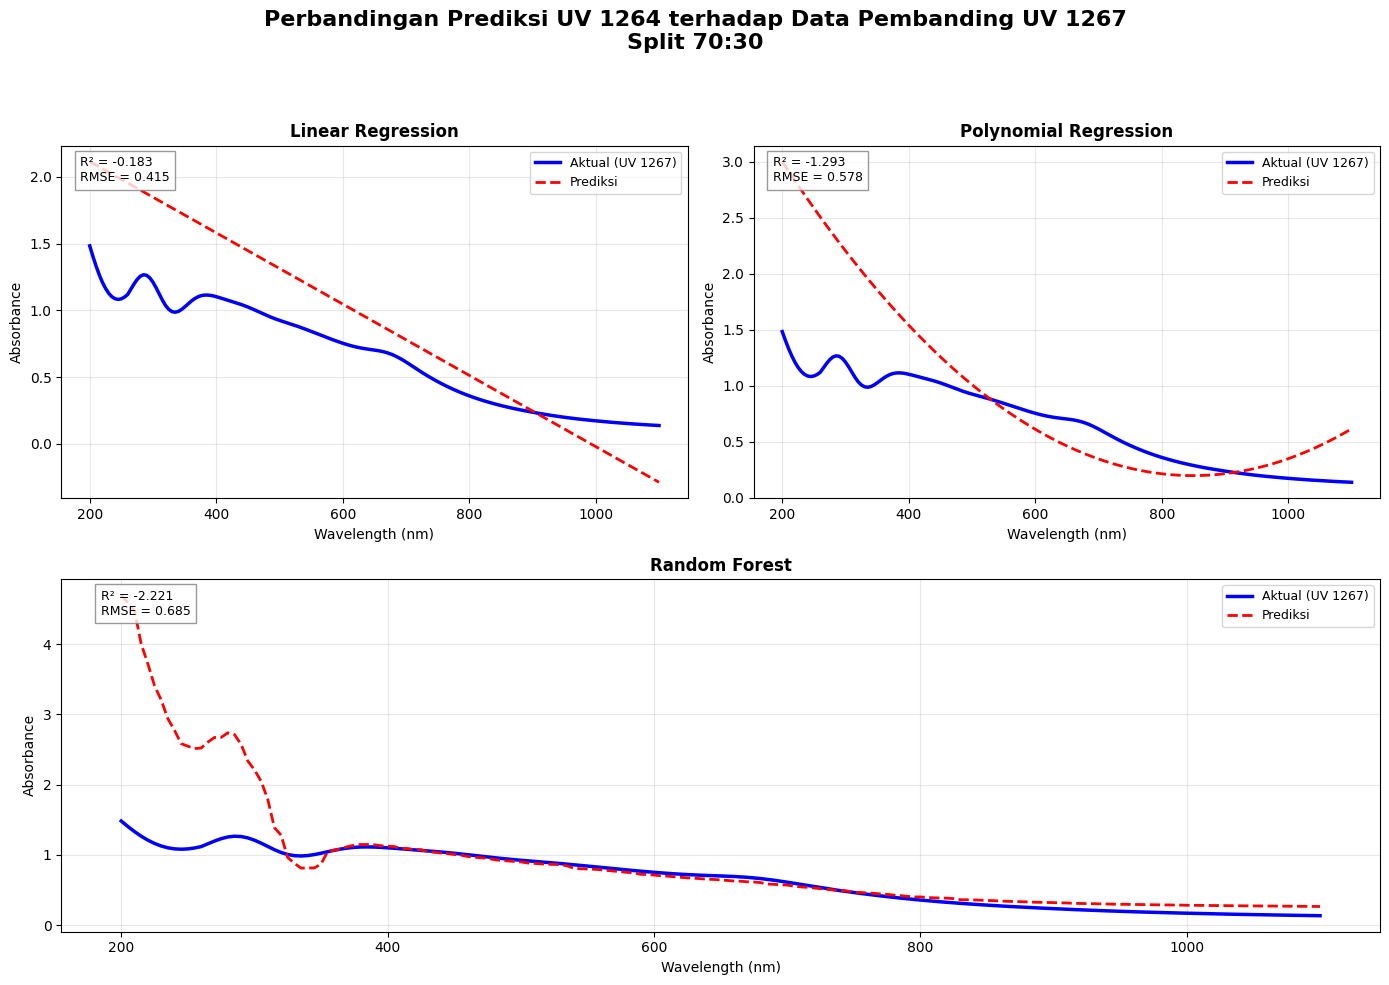

,Scenario,Sample,Comparison,Split,Model,R2,RMSE
0,Scenario 1,UV 1264,UV 1267,70:30,Linear Regression,-0.183232,0.415007
1,Scenario 1,UV 1264,UV 1267,70:30,Polynomial Regression,-1.292915,0.577717
2,Scenario 1,UV 1264,UV 1267,70:30,Random Forest,-2.220520,0.684674




SAMPEL : UV 1264
Shape X : (181, 1)
Shape y : (181,)

TRAIN DATA


,Wavelength,Absorbance
0,525,0.8523
1,535,0.8347
2,355,0.9791
3,260,2.4723
4,405,1.1112
...,...,...
139,730,0.5099
140,270,2.7046
141,660,0.6311
142,1095,0.2681



TEST DATA


,Wavelength,Absorbance
0,295,2.5257
1,410,1.1009
2,965,0.2942
3,590,0.7313
4,925,0.3086
5,275,2.7978
6,320,1.1376
7,540,0.8257
8,765,0.4494
9,790,0.4139



HASIL EVALUASI


,Sample,Split,Model,R2,RMSE
0,UV 1264,80:20,Linear Regression,0.644148,0.455123
1,UV 1264,80:20,Polynomial Regression,0.791625,0.348271
2,UV 1264,80:20,Random Forest,0.996429,0.045590


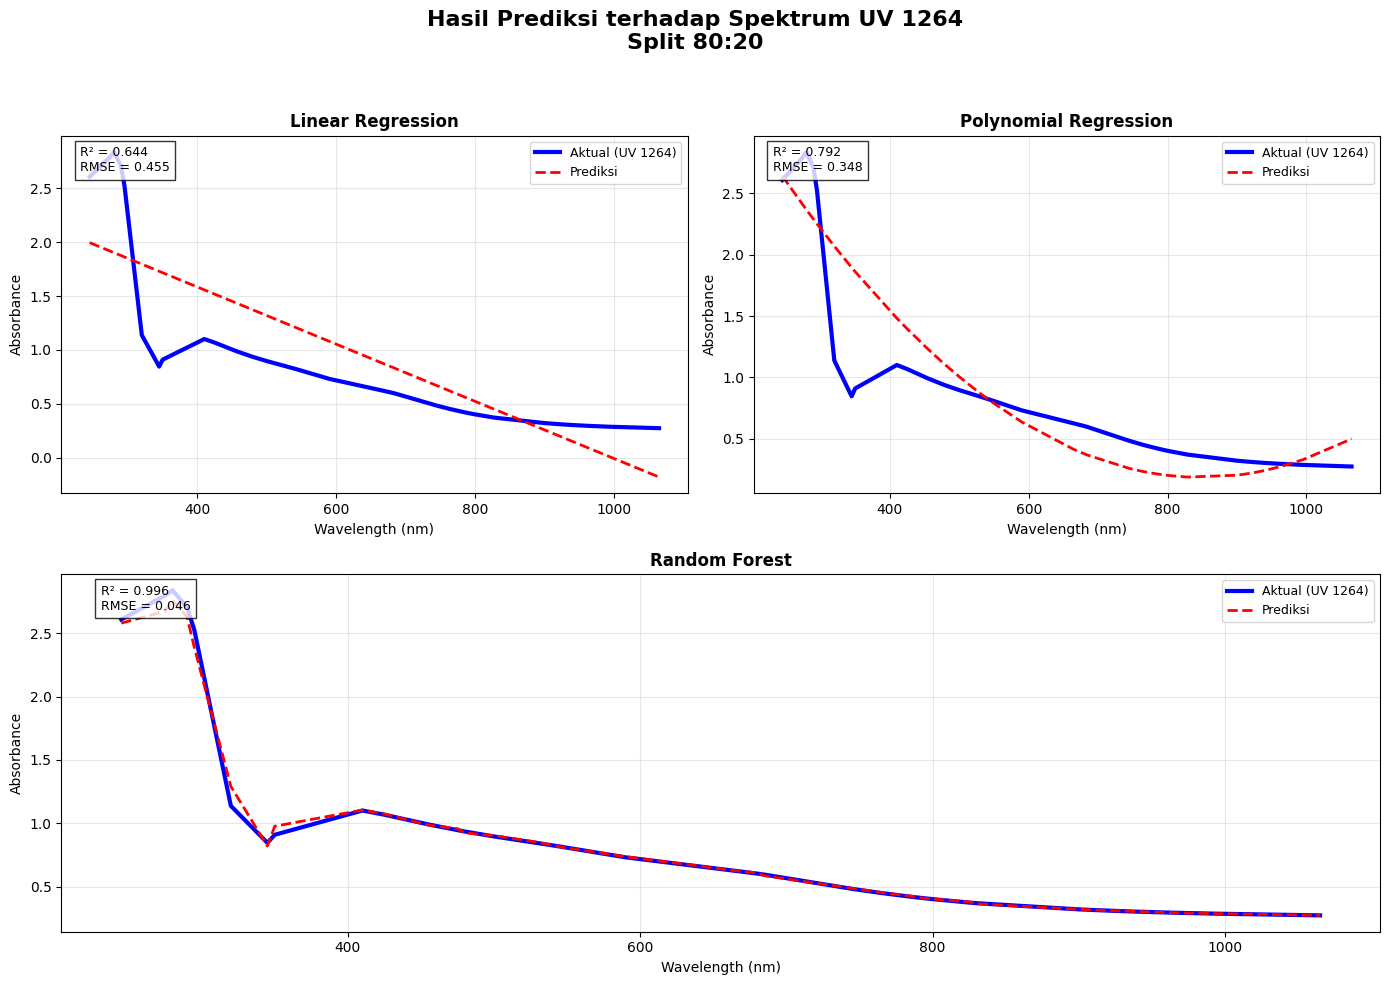

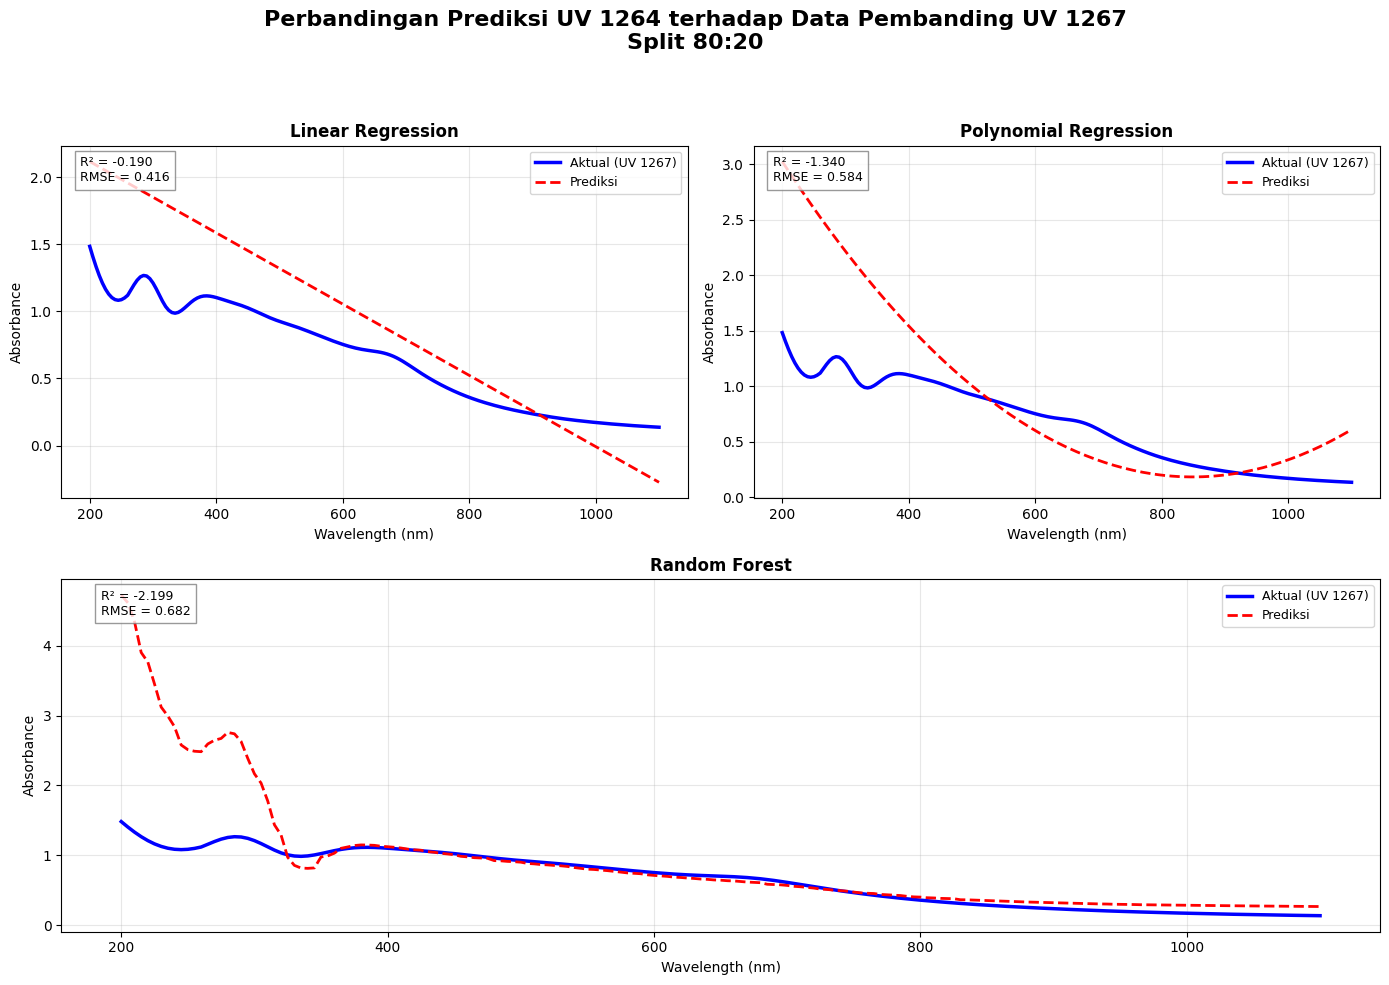

,Scenario,Sample,Comparison,Split,Model,R2,RMSE
0,Scenario 1,UV 1264,UV 1267,80:20,Linear Regression,-0.189901,0.416176
1,Scenario 1,UV 1264,UV 1267,80:20,Polynomial Regression,-1.339615,0.583570
2,Scenario 1,UV 1264,UV 1267,80:20,Random Forest,-2.198984,0.682381




SAMPEL : UV 1264
Shape X : (181, 1)
Shape y : (181,)

TRAIN DATA


,Wavelength,Absorbance
0,480,0.9353
1,685,0.5949
2,800,0.4014
3,915,0.3132
4,350,0.9094
...,...,...
157,730,0.5099
158,270,2.7046
159,660,0.6311
160,1095,0.2681



TEST DATA


,Wavelength,Absorbance
0,295,2.5257
1,410,1.1009
2,965,0.2942
3,590,0.7313
4,925,0.3086
5,275,2.7978
6,320,1.1376
7,540,0.8257
8,765,0.4494
9,790,0.4139



HASIL EVALUASI


,Sample,Split,Model,R2,RMSE
0,UV 1264,90:10,Linear Regression,0.686715,0.452037
1,UV 1264,90:10,Polynomial Regression,0.849001,0.313828
2,UV 1264,90:10,Random Forest,0.995807,0.052293


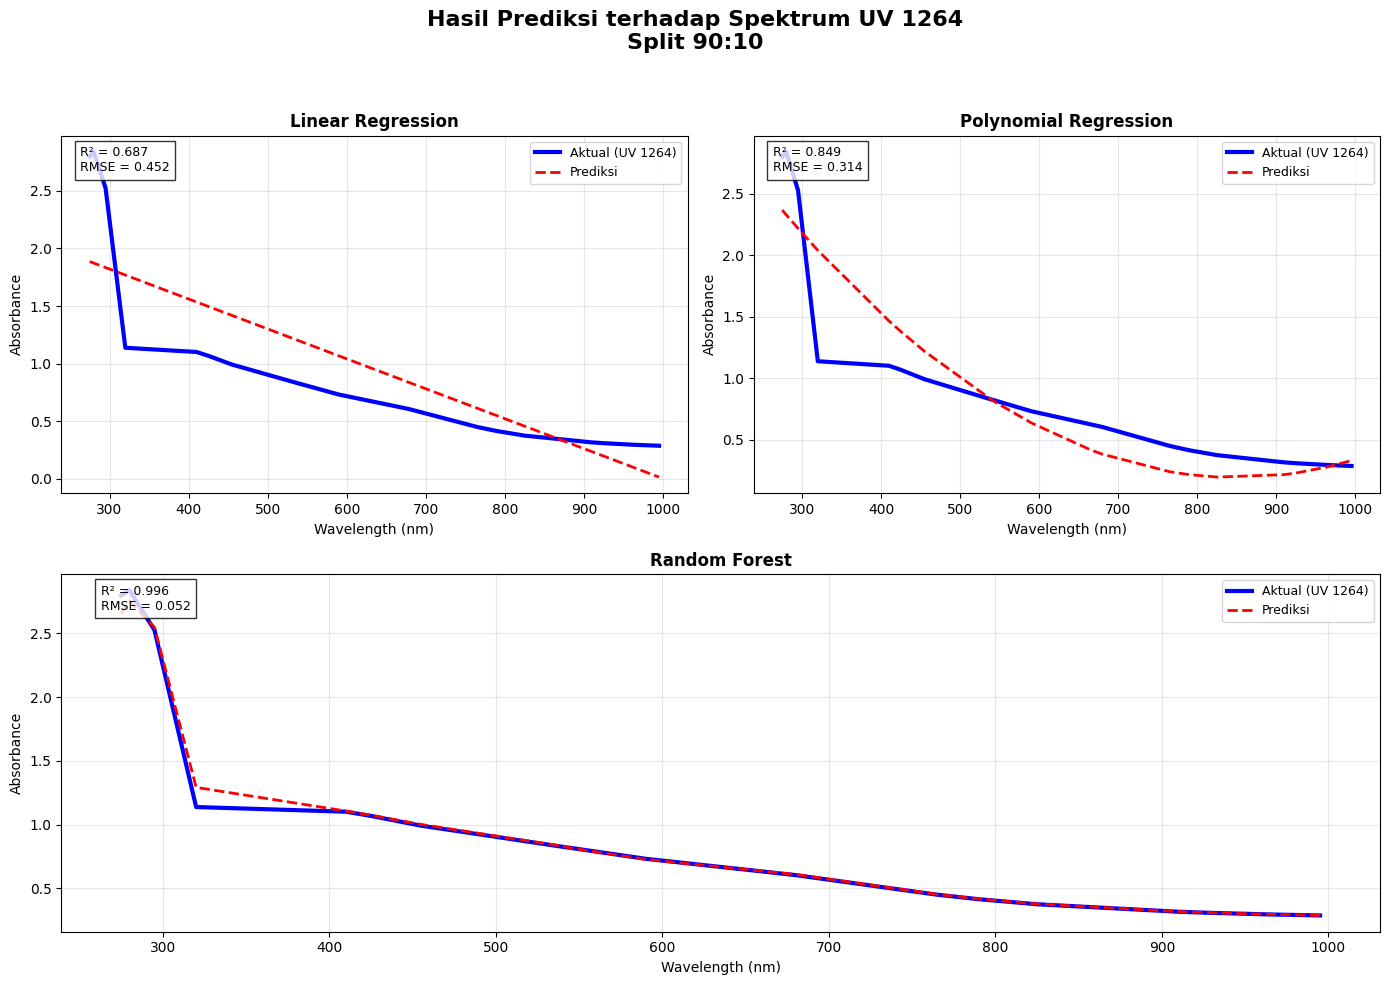

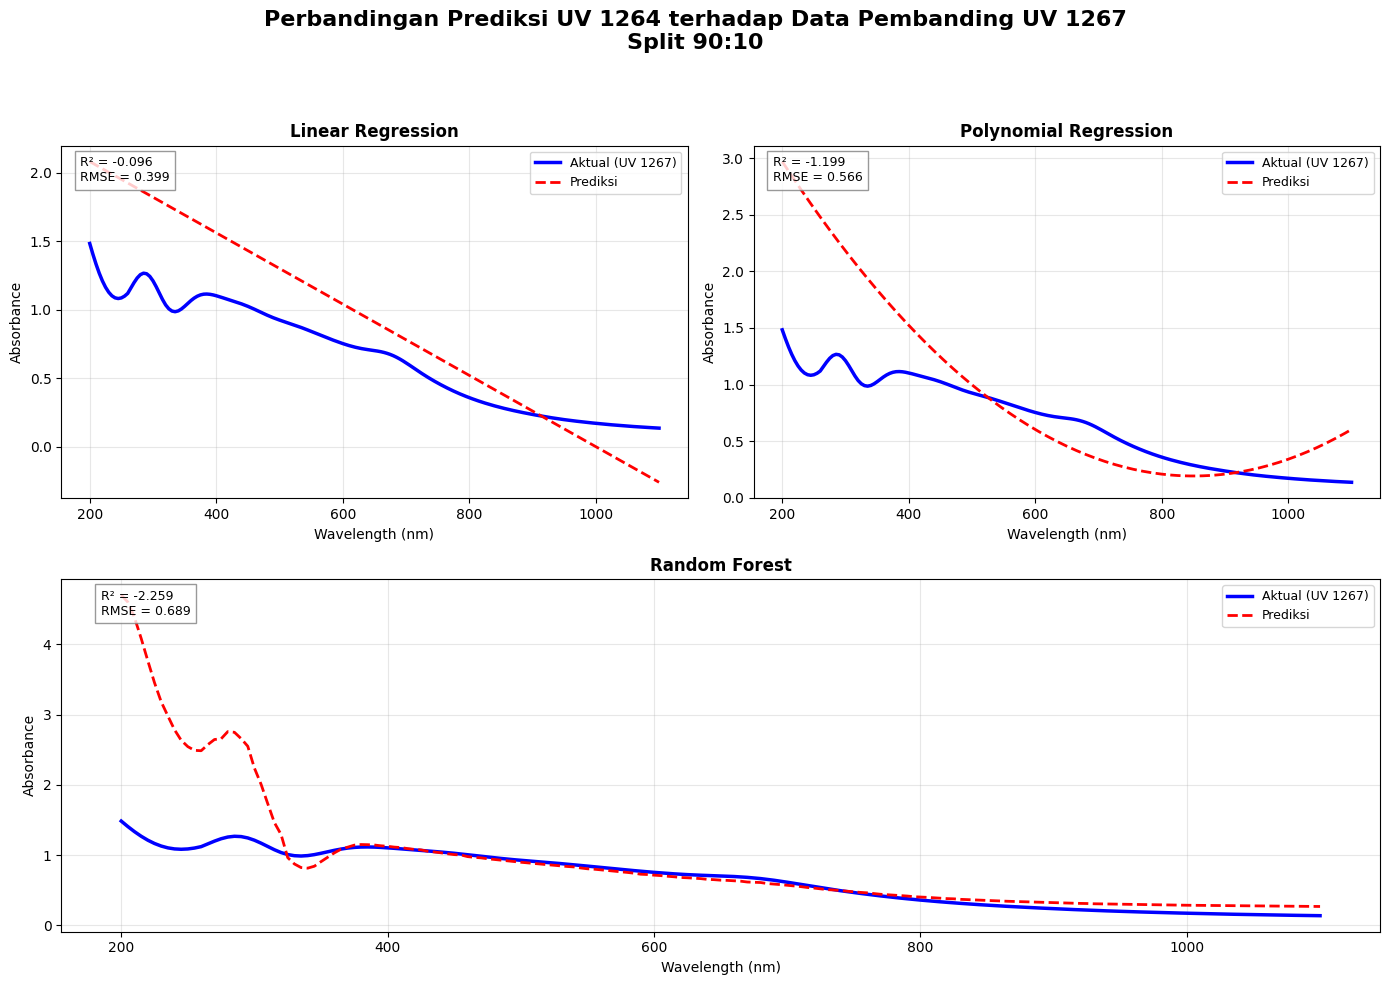

,Scenario,Sample,Comparison,Split,Model,R2,RMSE
0,Scenario 1,UV 1264,UV 1267,90:10,Linear Regression,-0.096119,0.399438
1,Scenario 1,UV 1264,UV 1267,90:10,Polynomial Regression,-1.198717,0.565725
2,Scenario 1,UV 1264,UV 1267,90:10,Random Forest,-2.259497,0.688805




SAMPEL : UV 1265
Shape X : (181, 1)
Shape y : (181,)

TRAIN DATA


,Wavelength,Absorbance
0,760,0.4526
1,220,3.8294
2,360,0.9995
3,705,0.5985
4,840,0.3136
...,...,...
103,730,0.5288
104,270,0.8914
105,660,0.6832
106,1095,0.1657



TEST DATA


,Wavelength,Absorbance
0,295,1.9538
1,410,1.1399
2,965,0.2108
3,590,0.7662
4,925,0.2348
...,...,...
68,575,0.7937
69,930,0.2313
70,255,0.9102
71,230,2.6797



HASIL EVALUASI


,Sample,Split,Model,R2,RMSE
0,UV 1265,60:40,Linear Regression,0.541387,0.506828
1,UV 1265,60:40,Polynomial Regression,0.550878,0.501556
2,UV 1265,60:40,Random Forest,0.992735,0.063791


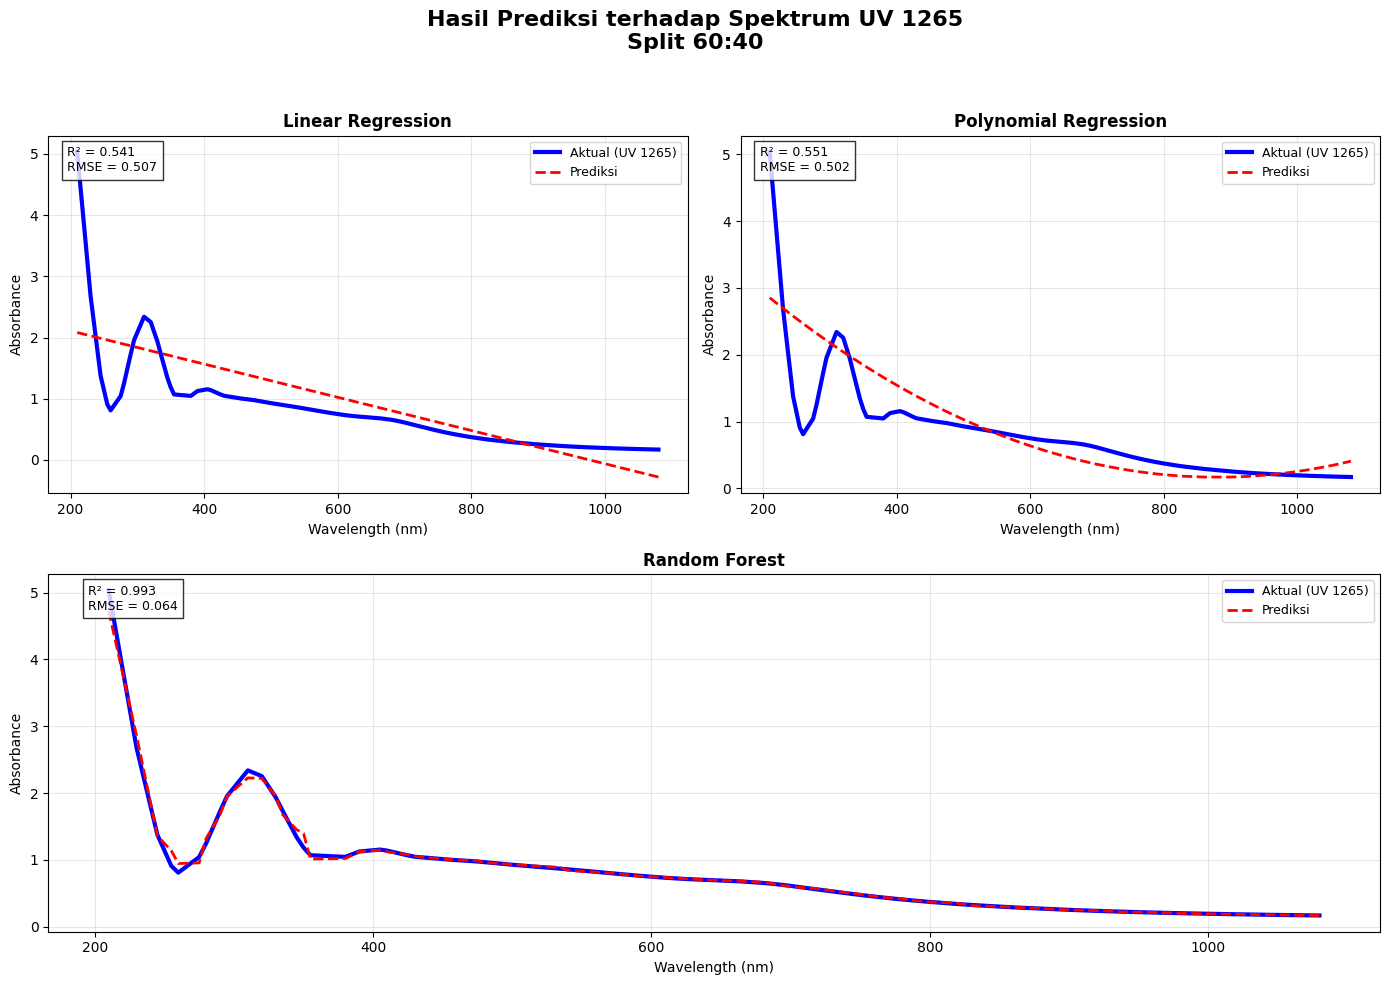

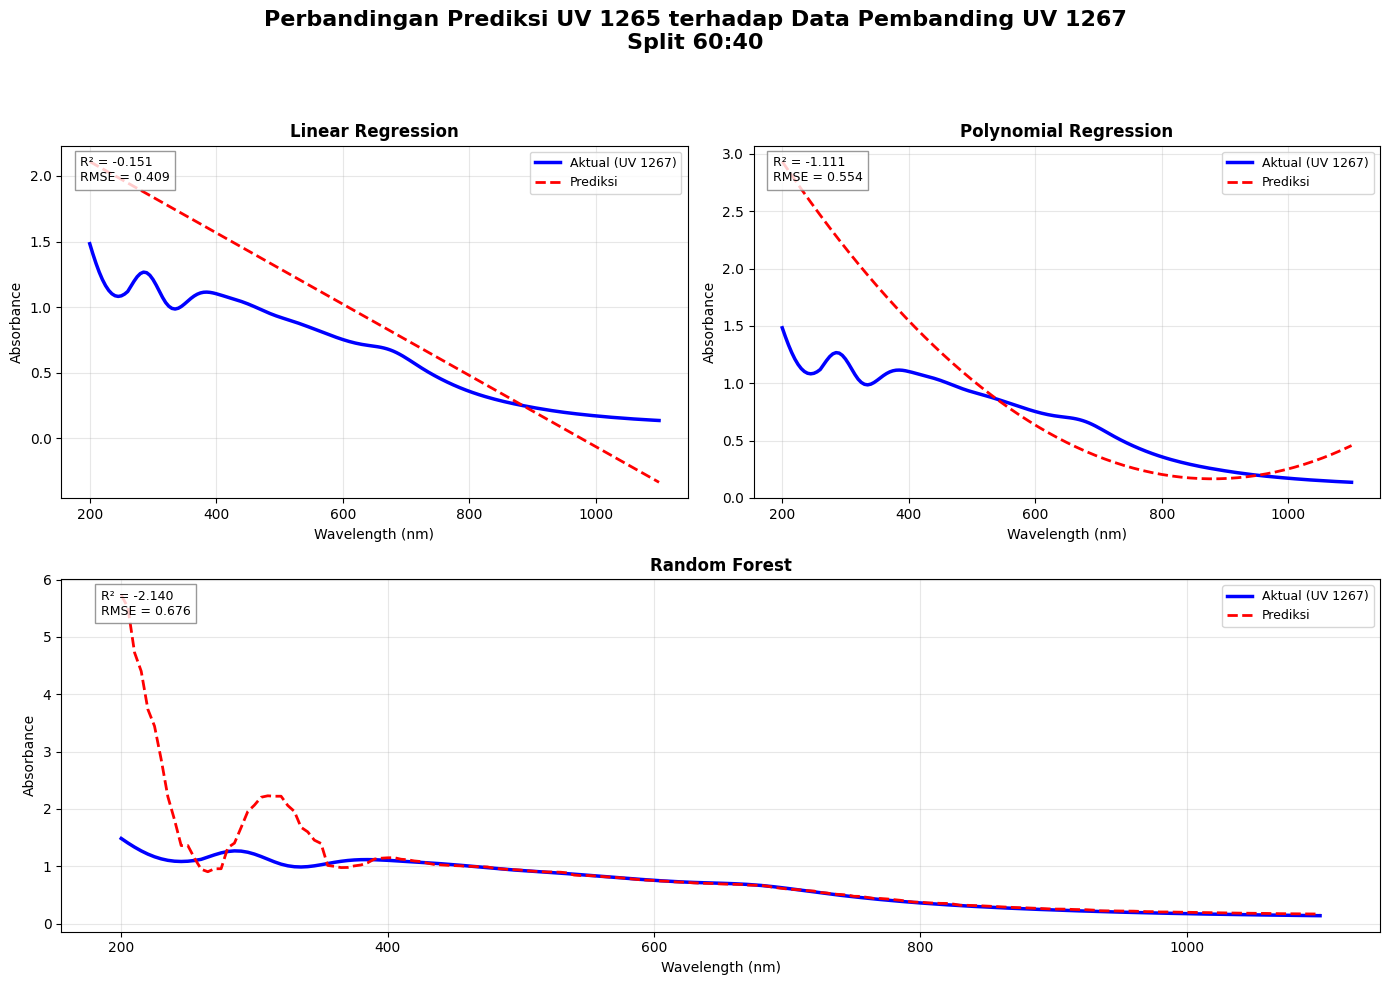

,Scenario,Sample,Comparison,Split,Model,R2,RMSE
0,Scenario 1,UV 1265,UV 1267,60:40,Linear Regression,-0.150678,0.409259
1,Scenario 1,UV 1265,UV 1267,60:40,Polynomial Regression,-1.110641,0.554279
2,Scenario 1,UV 1265,UV 1267,60:40,Random Forest,-2.140294,0.676093




SAMPEL : UV 1265
Shape X : (181, 1)
Shape y : (181,)

TRAIN DATA


,Wavelength,Absorbance
0,625,0.7144
1,960,0.2133
2,610,0.7337
3,935,0.228
4,330,1.9379
...,...,...
121,730,0.5288
122,270,0.8914
123,660,0.6832
124,1095,0.1657



TEST DATA


,Wavelength,Absorbance
0,295,1.9538
1,410,1.1399
2,965,0.2108
3,590,0.7662
4,925,0.2348
5,275,1.0436
6,320,2.2541
7,540,0.8595
8,765,0.4412
9,790,0.39



HASIL EVALUASI


,Sample,Split,Model,R2,RMSE
0,UV 1265,70:30,Linear Regression,0.488901,0.535297
1,UV 1265,70:30,Polynomial Regression,0.538044,0.508912
2,UV 1265,70:30,Random Forest,0.991157,0.070413


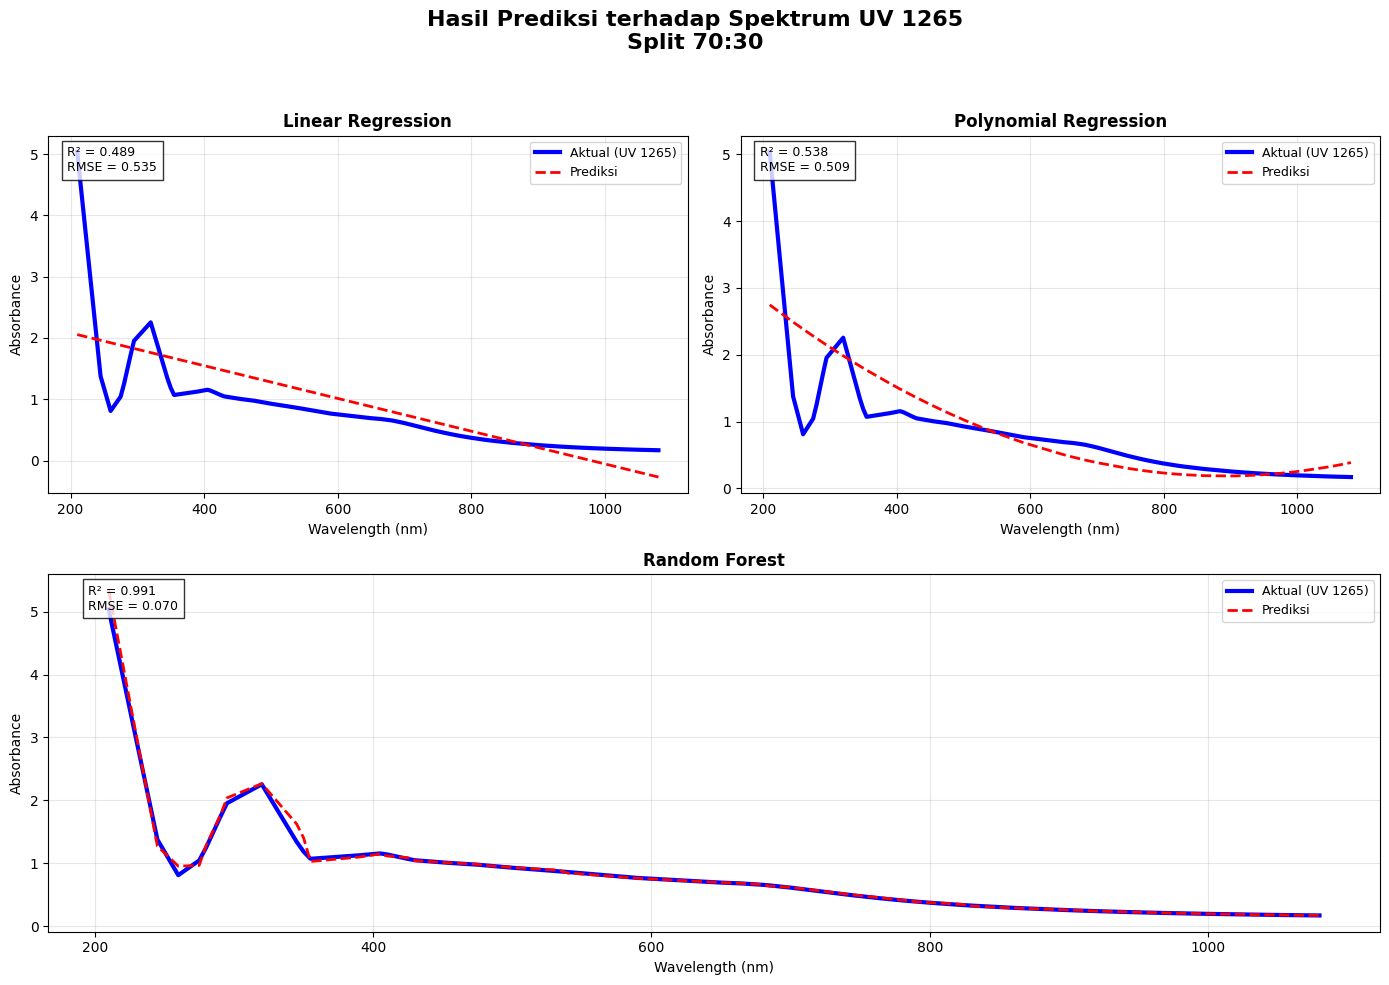

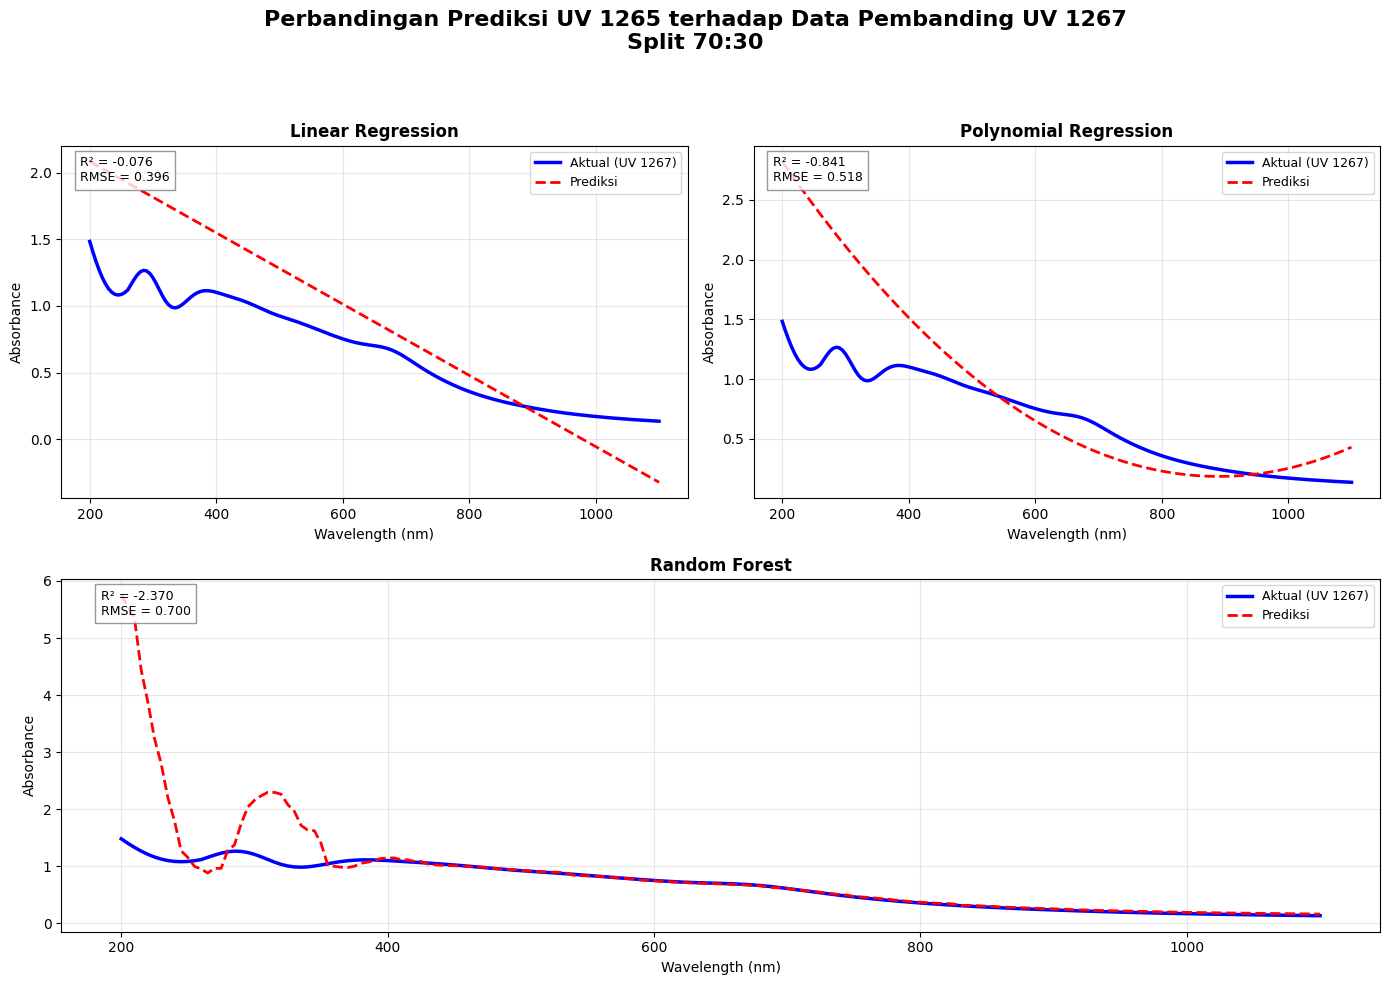

,Scenario,Sample,Comparison,Split,Model,R2,RMSE
0,Scenario 1,UV 1265,UV 1267,70:30,Linear Regression,-0.076308,0.395812
1,Scenario 1,UV 1265,UV 1267,70:30,Polynomial Regression,-0.840784,0.517634
2,Scenario 1,UV 1265,UV 1267,70:30,Random Forest,-2.369945,0.700378




SAMPEL : UV 1265
Shape X : (181, 1)
Shape y : (181,)

TRAIN DATA


,Wavelength,Absorbance
0,525,0.8855
1,535,0.8683
2,355,1.0705
3,260,0.8102
4,405,1.1554
...,...,...
139,730,0.5288
140,270,0.8914
141,660,0.6832
142,1095,0.1657



TEST DATA


,Wavelength,Absorbance
0,295,1.9538
1,410,1.1399
2,965,0.2108
3,590,0.7662
4,925,0.2348
5,275,1.0436
6,320,2.2541
7,540,0.8595
8,765,0.4412
9,790,0.39



HASIL EVALUASI


,Sample,Split,Model,R2,RMSE
0,UV 1265,80:20,Linear Regression,0.612800,0.322010
1,UV 1265,80:20,Polynomial Regression,0.449189,0.384064
2,UV 1265,80:20,Random Forest,0.991850,0.046716


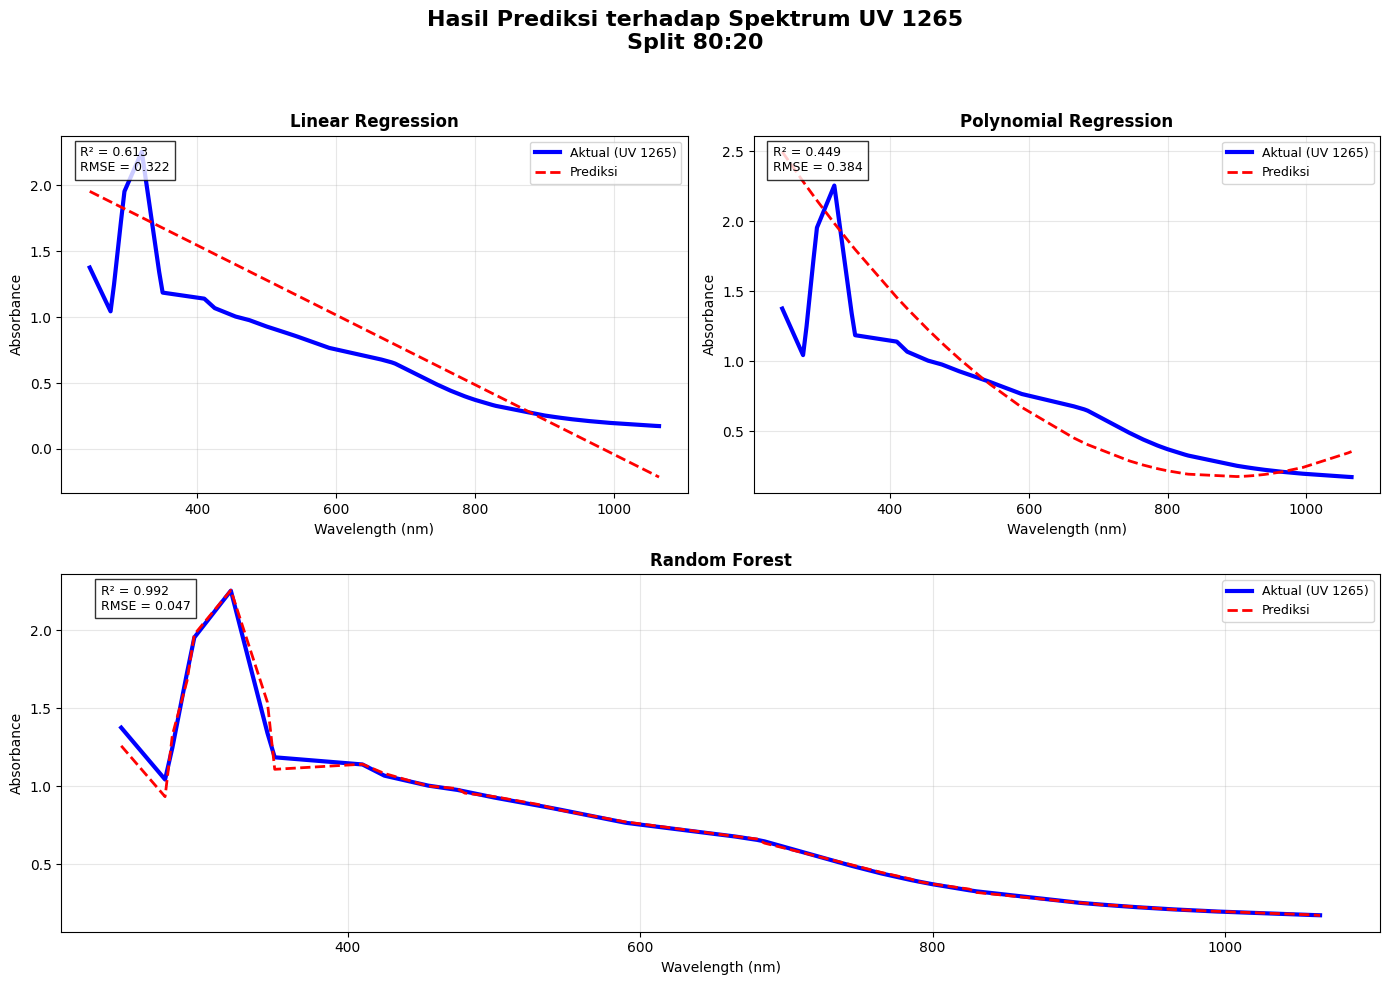

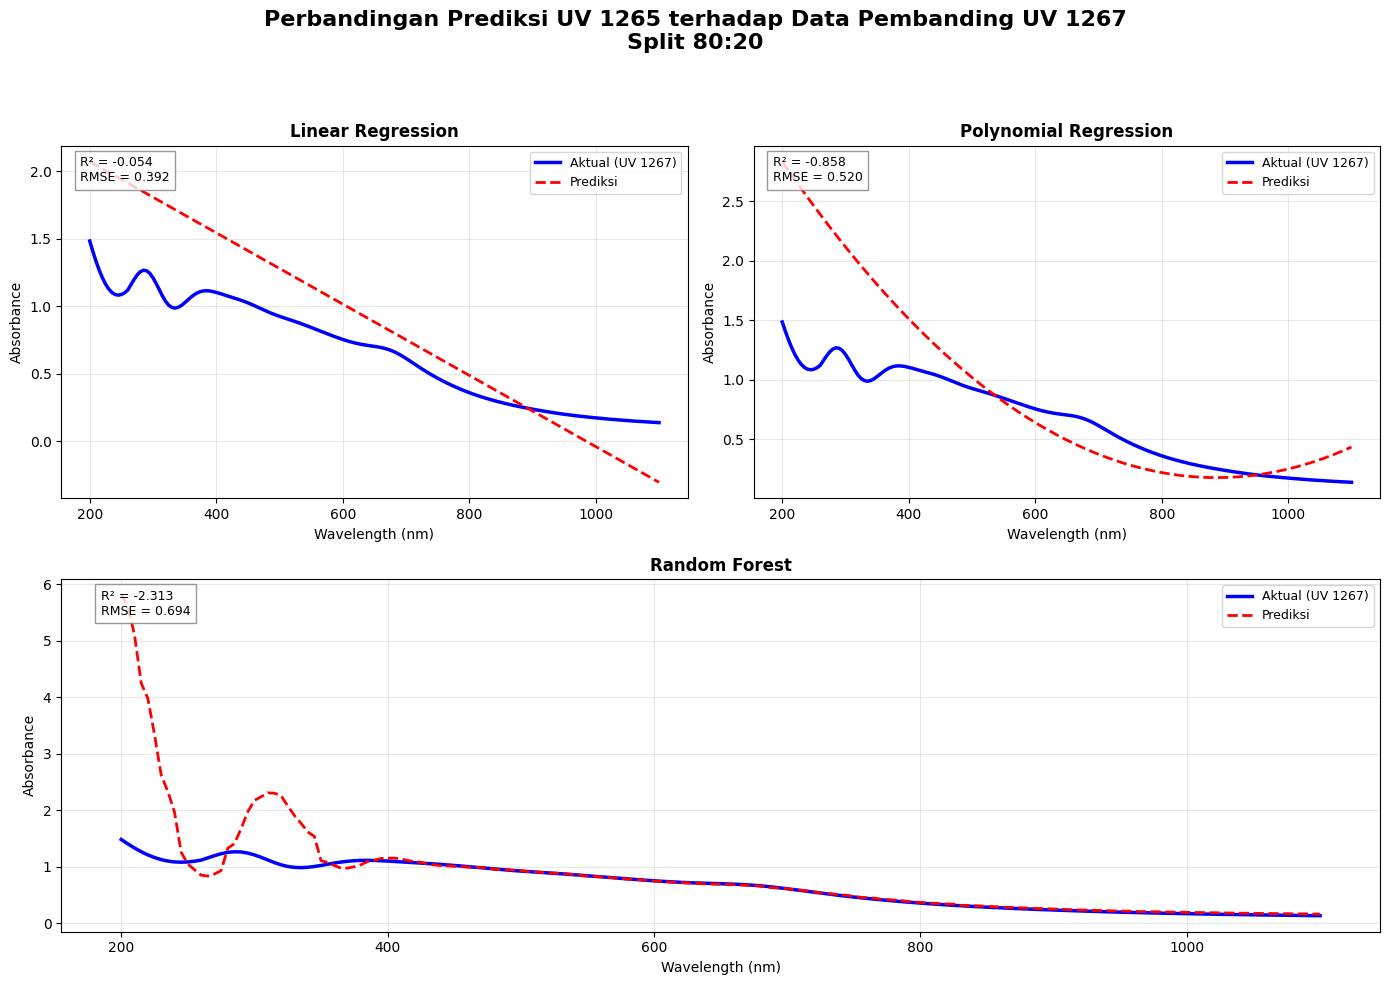

,Scenario,Sample,Comparison,Split,Model,R2,RMSE
0,Scenario 1,UV 1265,UV 1267,80:20,Linear Regression,-0.054042,0.391697
1,Scenario 1,UV 1265,UV 1267,80:20,Polynomial Regression,-0.858482,0.520116
2,Scenario 1,UV 1265,UV 1267,80:20,Random Forest,-2.313072,0.694443




SAMPEL : UV 1265
Shape X : (181, 1)
Shape y : (181,)

TRAIN DATA


,Wavelength,Absorbance
0,480,0.967
1,685,0.6469
2,800,0.3721
3,915,0.242
4,350,1.1858
...,...,...
157,730,0.5288
158,270,0.8914
159,660,0.6832
160,1095,0.1657



TEST DATA


,Wavelength,Absorbance
0,295,1.9538
1,410,1.1399
2,965,0.2108
3,590,0.7662
4,925,0.2348
5,275,1.0436
6,320,2.2541
7,540,0.8595
8,765,0.4412
9,790,0.39



HASIL EVALUASI


,Sample,Split,Model,R2,RMSE
0,UV 1265,90:10,Linear Regression,0.653368,0.325909
1,UV 1265,90:10,Polynomial Regression,0.534224,0.377791
2,UV 1265,90:10,Random Forest,0.991455,0.051171


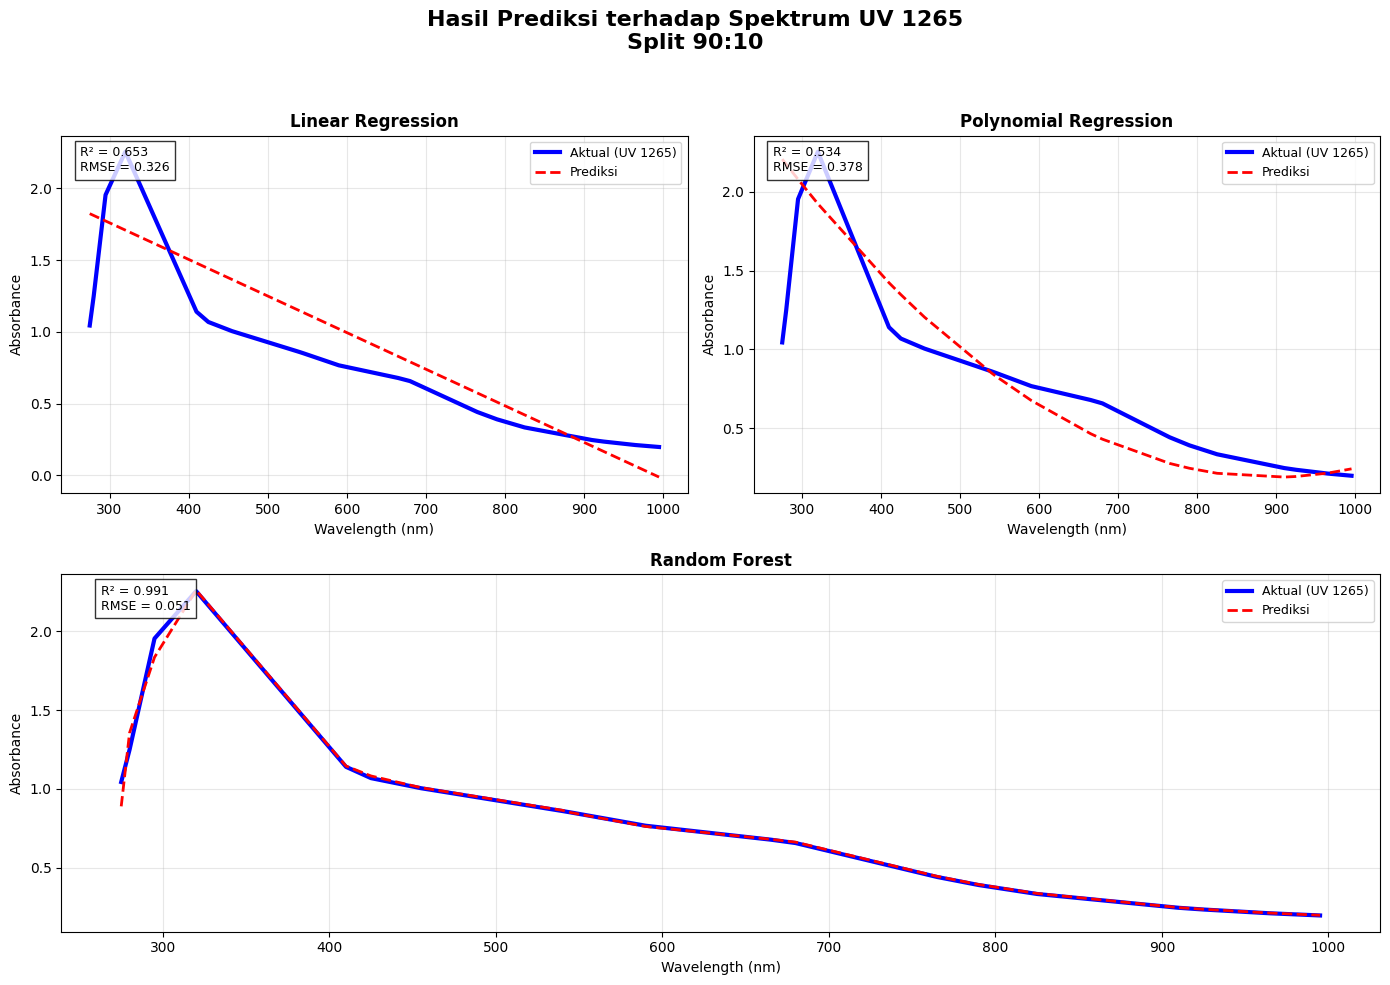

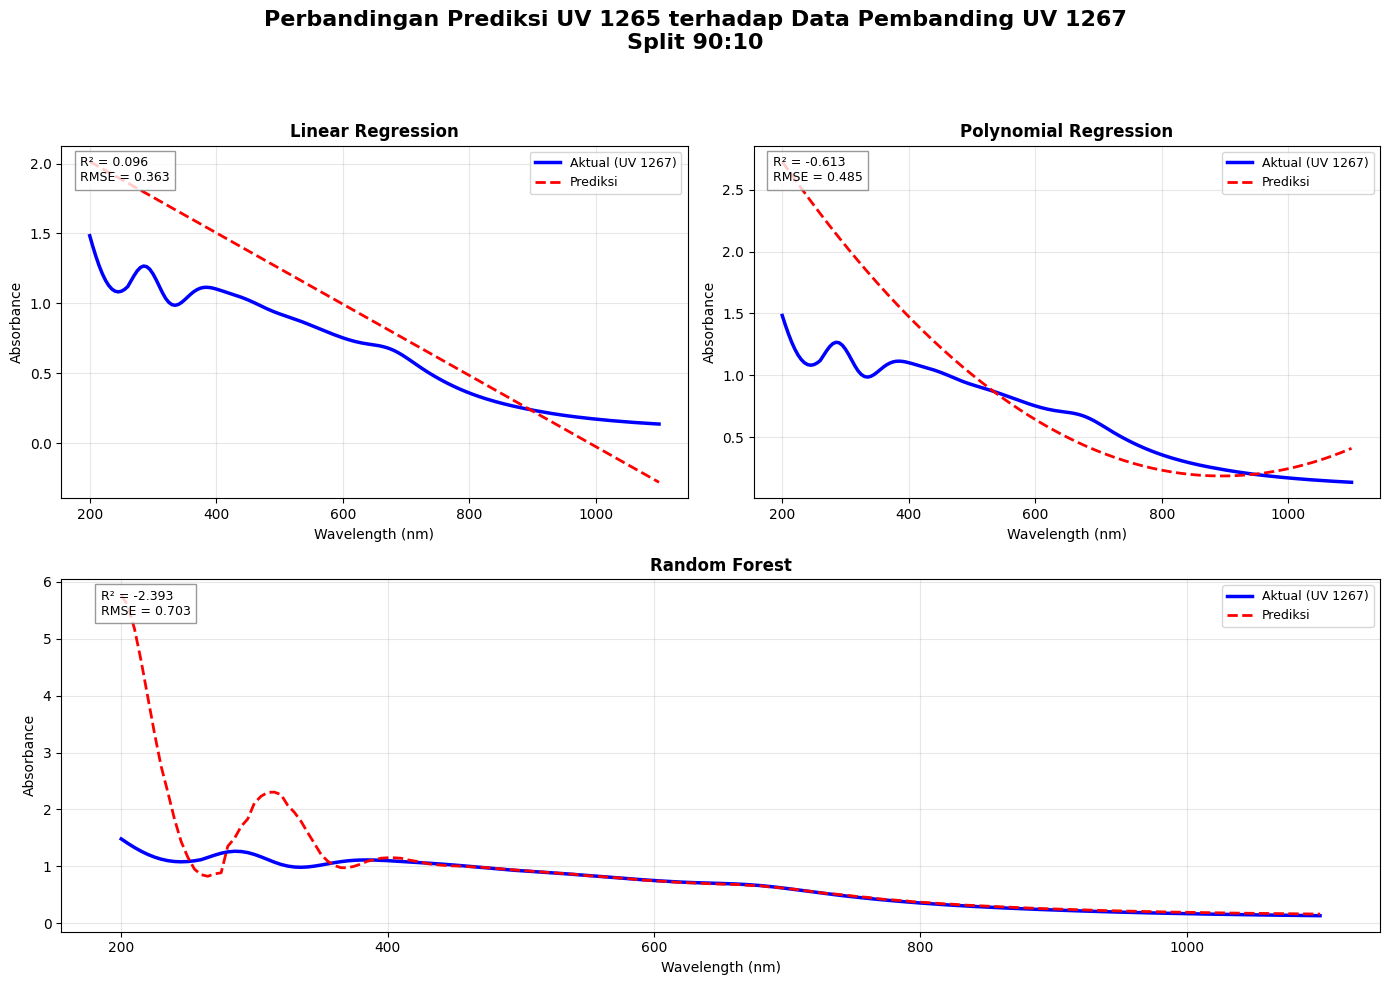

,Scenario,Sample,Comparison,Split,Model,R2,RMSE
0,Scenario 1,UV 1265,UV 1267,90:10,Linear Regression,0.096319,0.362684
1,Scenario 1,UV 1265,UV 1267,90:10,Polynomial Regression,-0.612934,0.484540
2,Scenario 1,UV 1265,UV 1267,90:10,Random Forest,-2.392877,0.702757




SAMPEL : UV 1266
Shape X : (181, 1)
Shape y : (181,)

TRAIN DATA


,Wavelength,Absorbance
0,760,0.4534
1,220,4.4369
2,360,0.9993
3,705,0.599
4,840,0.3139
...,...,...
103,730,0.5294
104,270,3.3737
105,660,0.6833
106,1095,0.1661



TEST DATA


,Wavelength,Absorbance
0,295,3.9506
1,410,1.162
2,965,0.2112
3,590,0.7658
4,925,0.2352
...,...,...
68,575,0.7934
69,930,0.2317
70,255,3.2576
71,230,3.9494



HASIL EVALUASI


,Sample,Split,Model,R2,RMSE
0,UV 1266,60:40,Linear Regression,0.662691,0.695484
1,UV 1266,60:40,Polynomial Regression,0.853266,0.458711
2,UV 1266,60:40,Random Forest,0.997552,0.059248


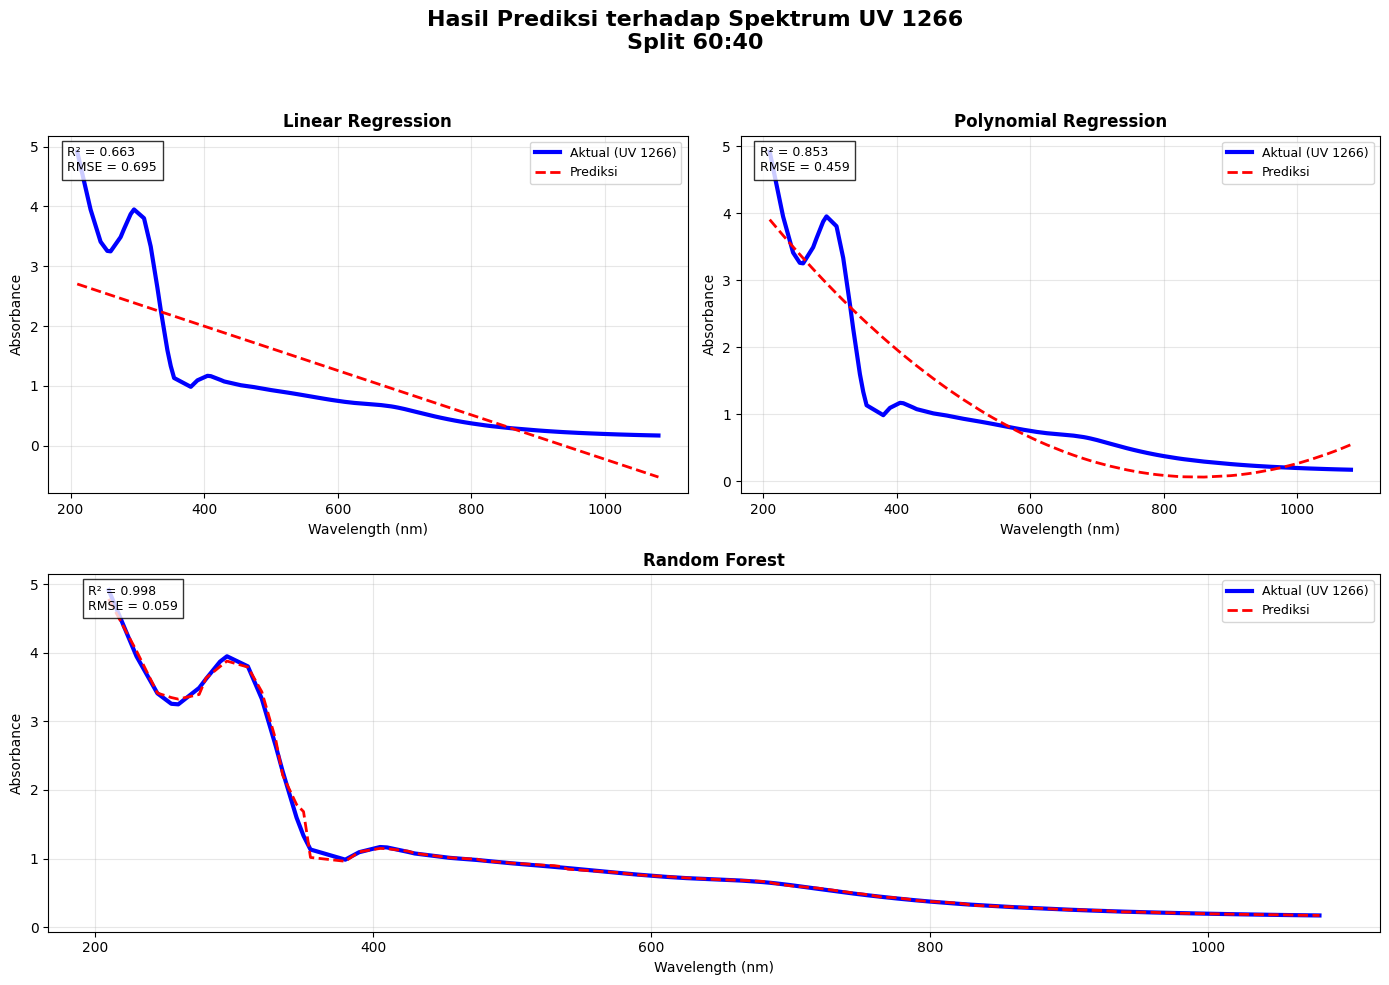

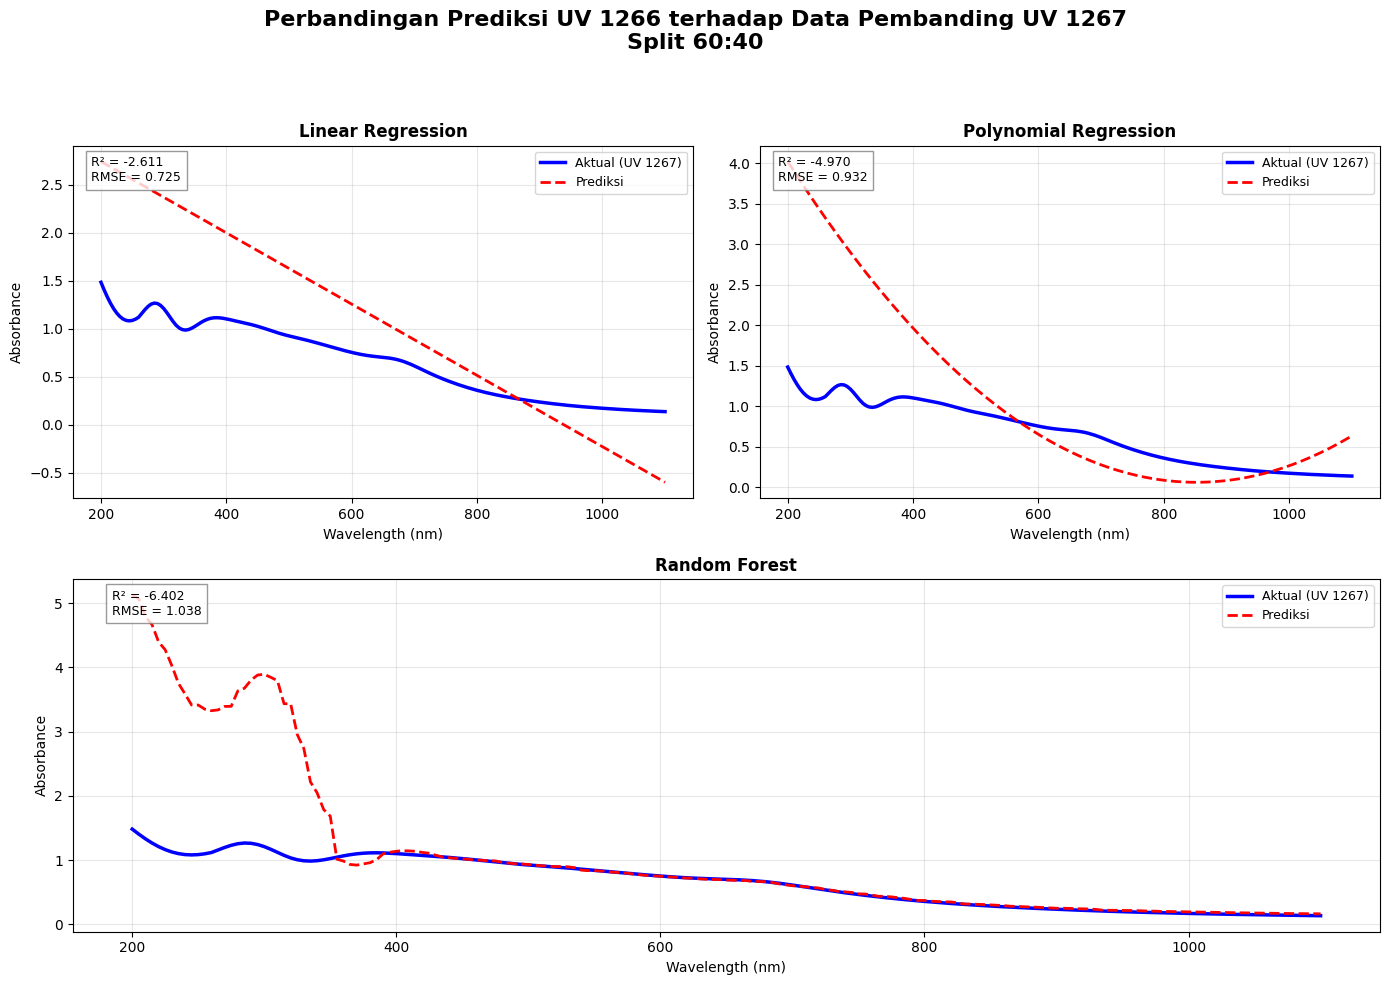

,Scenario,Sample,Comparison,Split,Model,R2,RMSE
0,Scenario 1,UV 1266,UV 1267,60:40,Linear Regression,-2.611357,0.725030
1,Scenario 1,UV 1266,UV 1267,60:40,Polynomial Regression,-4.970439,0.932232
2,Scenario 1,UV 1266,UV 1267,60:40,Random Forest,-6.401579,1.037966




SAMPEL : UV 1266
Shape X : (181, 1)
Shape y : (181,)

TRAIN DATA


,Wavelength,Absorbance
0,625,0.7145
1,960,0.2137
2,610,0.7336
3,935,0.2284
4,330,2.6432
...,...,...
121,730,0.5294
122,270,3.3737
123,660,0.6833
124,1095,0.1661



TEST DATA


,Wavelength,Absorbance
0,295,3.9506
1,410,1.162
2,965,0.2112
3,590,0.7658
4,925,0.2352
5,275,3.4888
6,320,3.3315
7,540,0.8603
8,765,0.442
9,790,0.3906



HASIL EVALUASI


,Sample,Split,Model,R2,RMSE
0,UV 1266,70:30,Linear Regression,0.629928,0.712486
1,UV 1266,70:30,Polynomial Regression,0.834952,0.475816
2,UV 1266,70:30,Random Forest,0.994462,0.087162


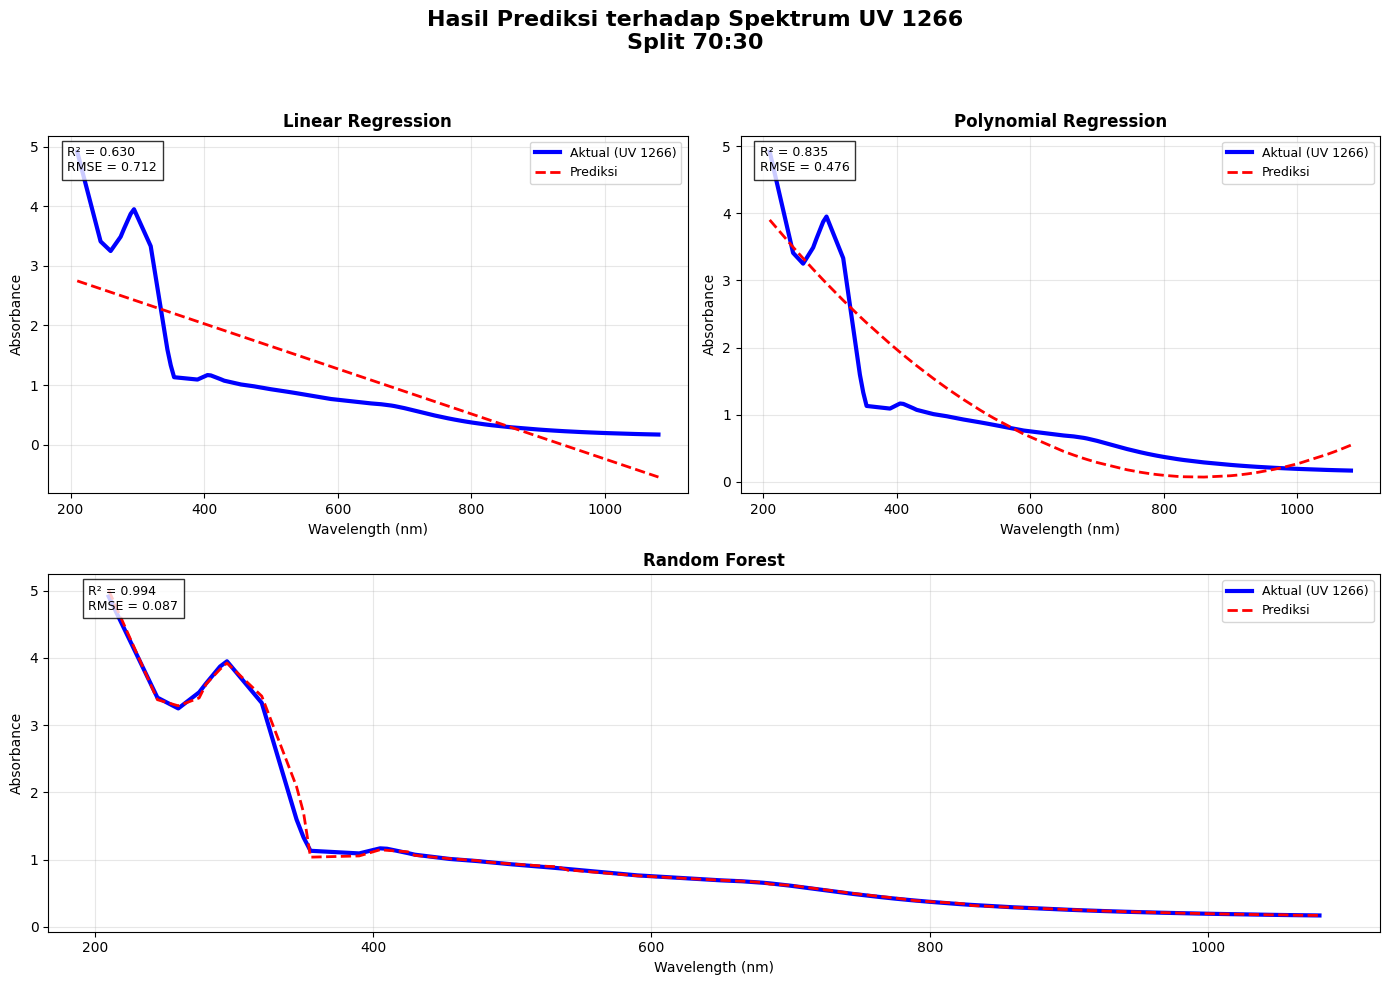

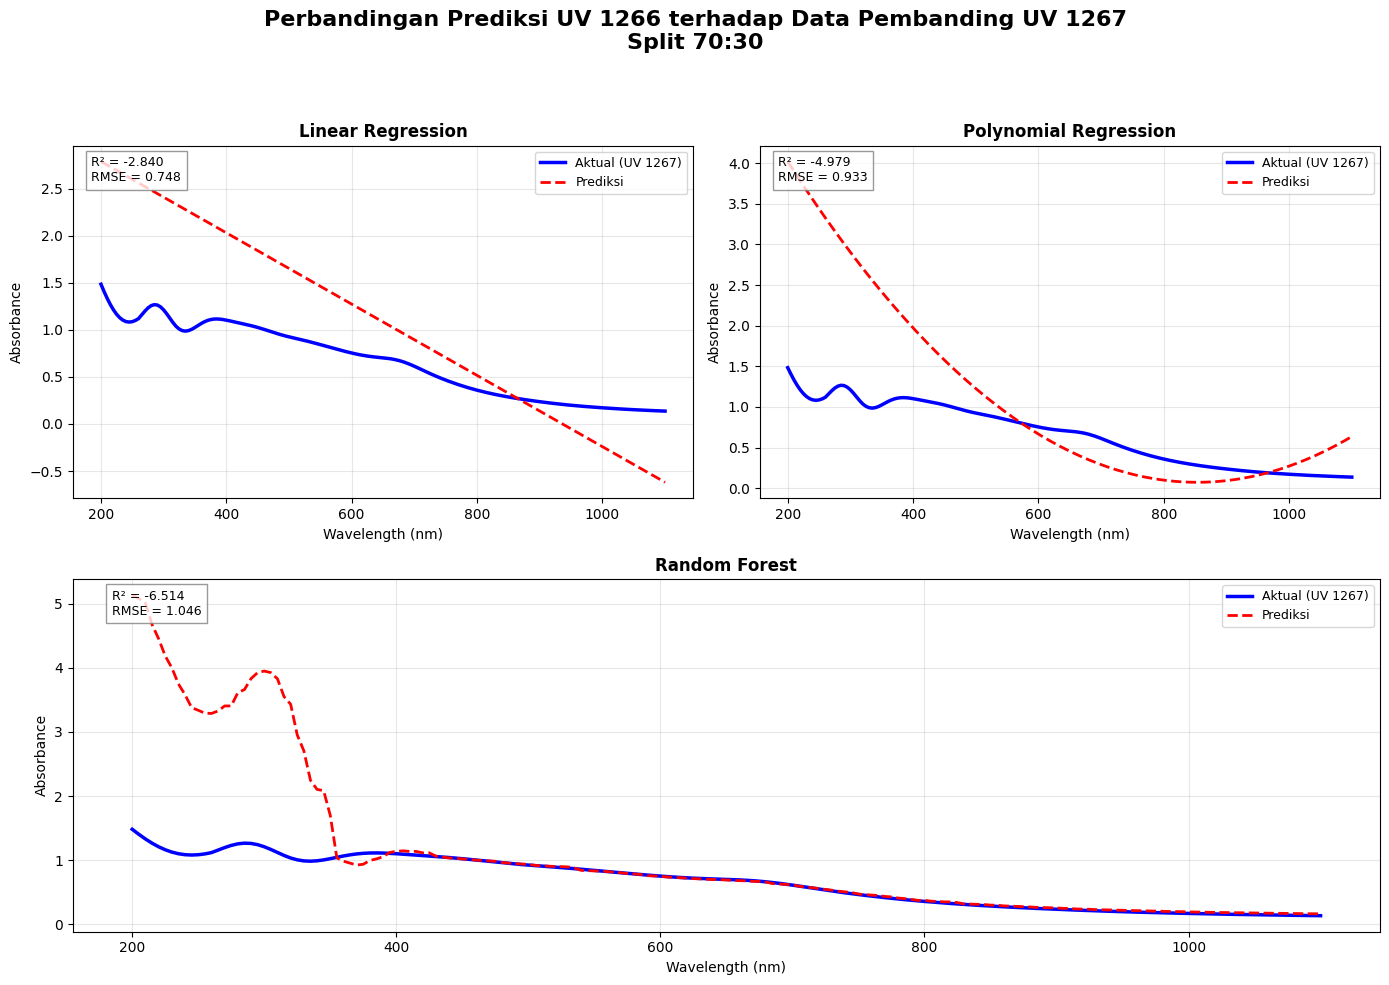

,Scenario,Sample,Comparison,Split,Model,R2,RMSE
0,Scenario 1,UV 1266,UV 1267,70:30,Linear Regression,-2.840366,0.747665
1,Scenario 1,UV 1266,UV 1267,70:30,Polynomial Regression,-4.978658,0.932874
2,Scenario 1,UV 1266,UV 1267,70:30,Random Forest,-6.514201,1.045833




SAMPEL : UV 1266
Shape X : (181, 1)
Shape y : (181,)

TRAIN DATA


,Wavelength,Absorbance
0,525,0.8874
1,535,0.8695
2,355,1.1318
3,260,3.2495
4,405,1.168
...,...,...
139,730,0.5294
140,270,3.3737
141,660,0.6833
142,1095,0.1661



TEST DATA


,Wavelength,Absorbance
0,295,3.9506
1,410,1.162
2,965,0.2112
3,590,0.7658
4,925,0.2352
5,275,3.4888
6,320,3.3315
7,540,0.8603
8,765,0.442
9,790,0.3906



HASIL EVALUASI


,Sample,Split,Model,R2,RMSE
0,UV 1266,80:20,Linear Regression,0.669266,0.668227
1,UV 1266,80:20,Polynomial Regression,0.854393,0.443380
2,UV 1266,80:20,Random Forest,0.996787,0.065862


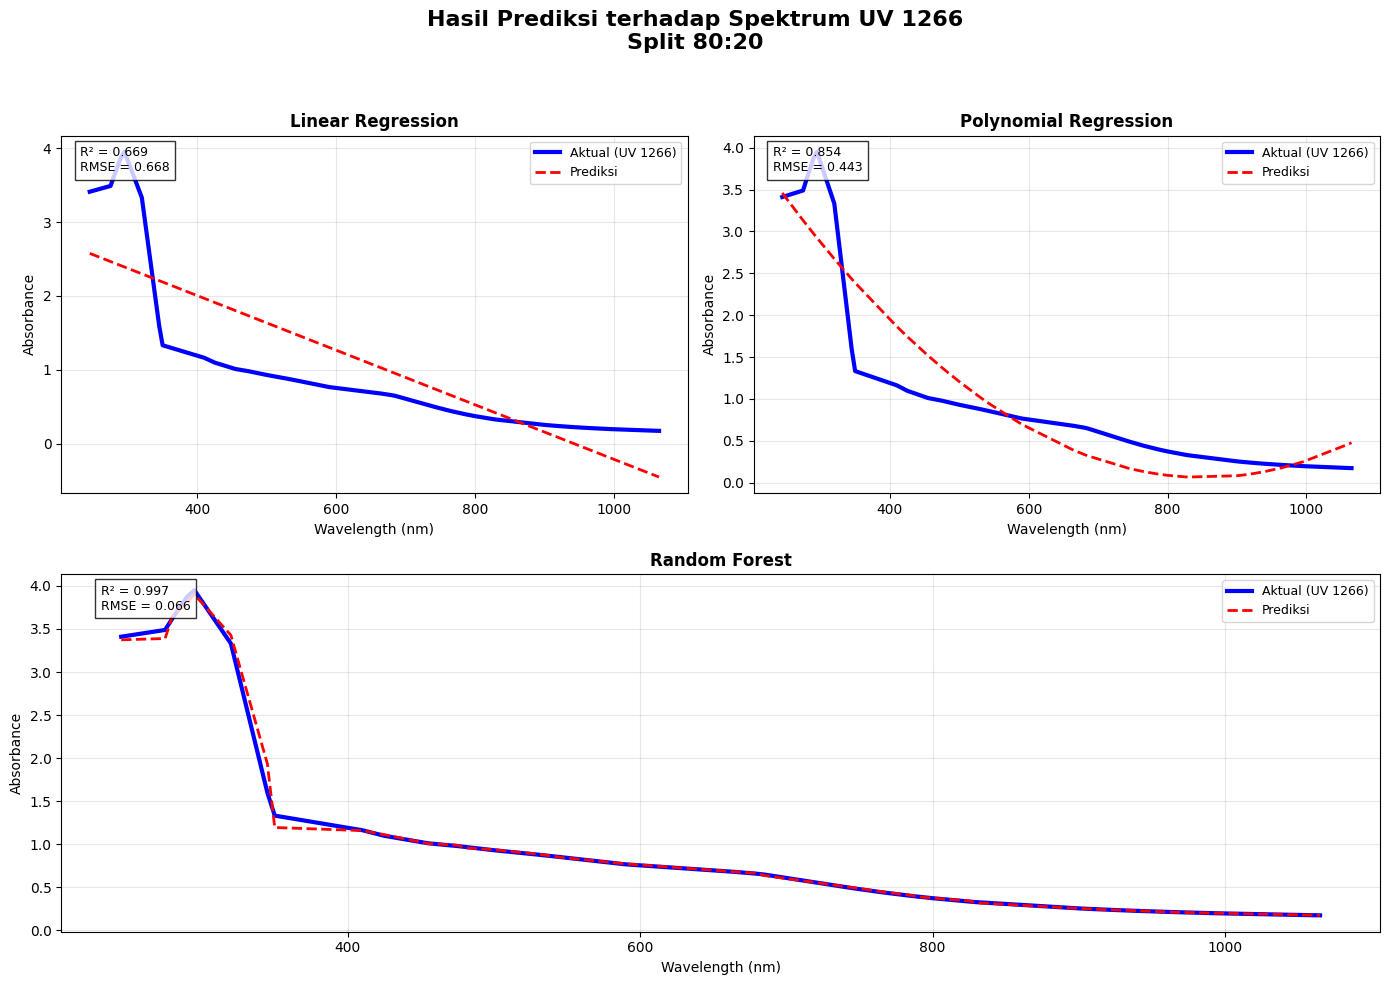

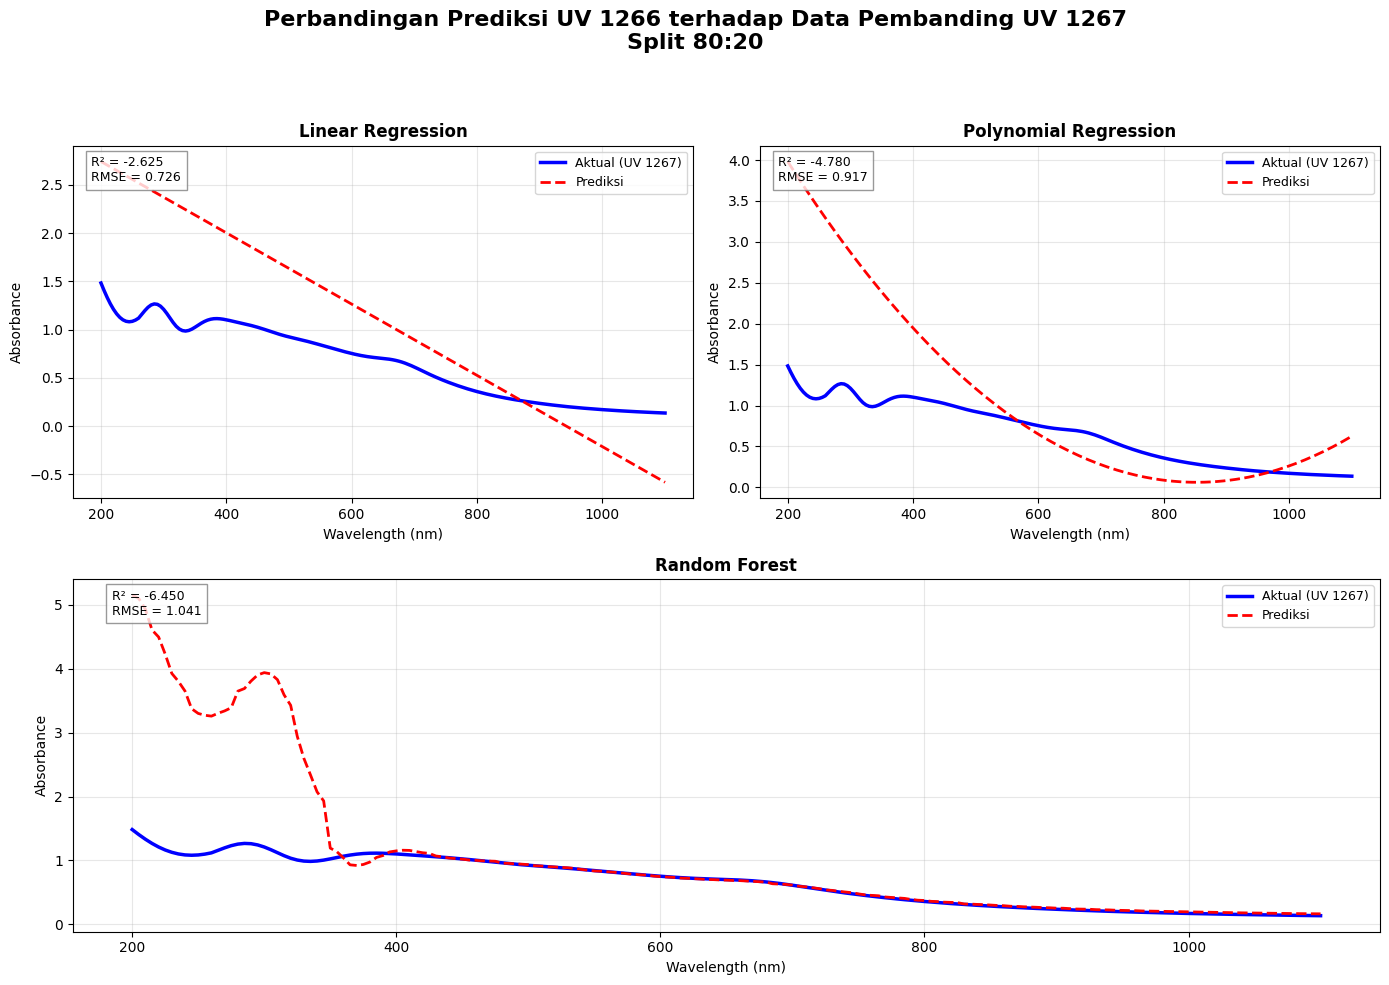

,Scenario,Sample,Comparison,Split,Model,R2,RMSE
0,Scenario 1,UV 1266,UV 1267,80:20,Linear Regression,-2.624835,0.726382
1,Scenario 1,UV 1266,UV 1267,80:20,Polynomial Regression,-4.780121,0.917254
2,Scenario 1,UV 1266,UV 1267,80:20,Random Forest,-6.449950,1.041352




SAMPEL : UV 1266
Shape X : (181, 1)
Shape y : (181,)

TRAIN DATA


,Wavelength,Absorbance
0,480,0.9685
1,685,0.6471
2,800,0.3727
3,915,0.2424
4,350,1.332
...,...,...
157,730,0.5294
158,270,3.3737
159,660,0.6833
160,1095,0.1661



TEST DATA


,Wavelength,Absorbance
0,295,3.9506
1,410,1.162
2,965,0.2112
3,590,0.7658
4,925,0.2352
5,275,3.4888
6,320,3.3315
7,540,0.8603
8,765,0.442
9,790,0.3906



HASIL EVALUASI


,Sample,Split,Model,R2,RMSE
0,UV 1266,90:10,Linear Regression,0.680302,0.710859
1,UV 1266,90:10,Polynomial Regression,0.877780,0.439526
2,UV 1266,90:10,Random Forest,0.998843,0.042772


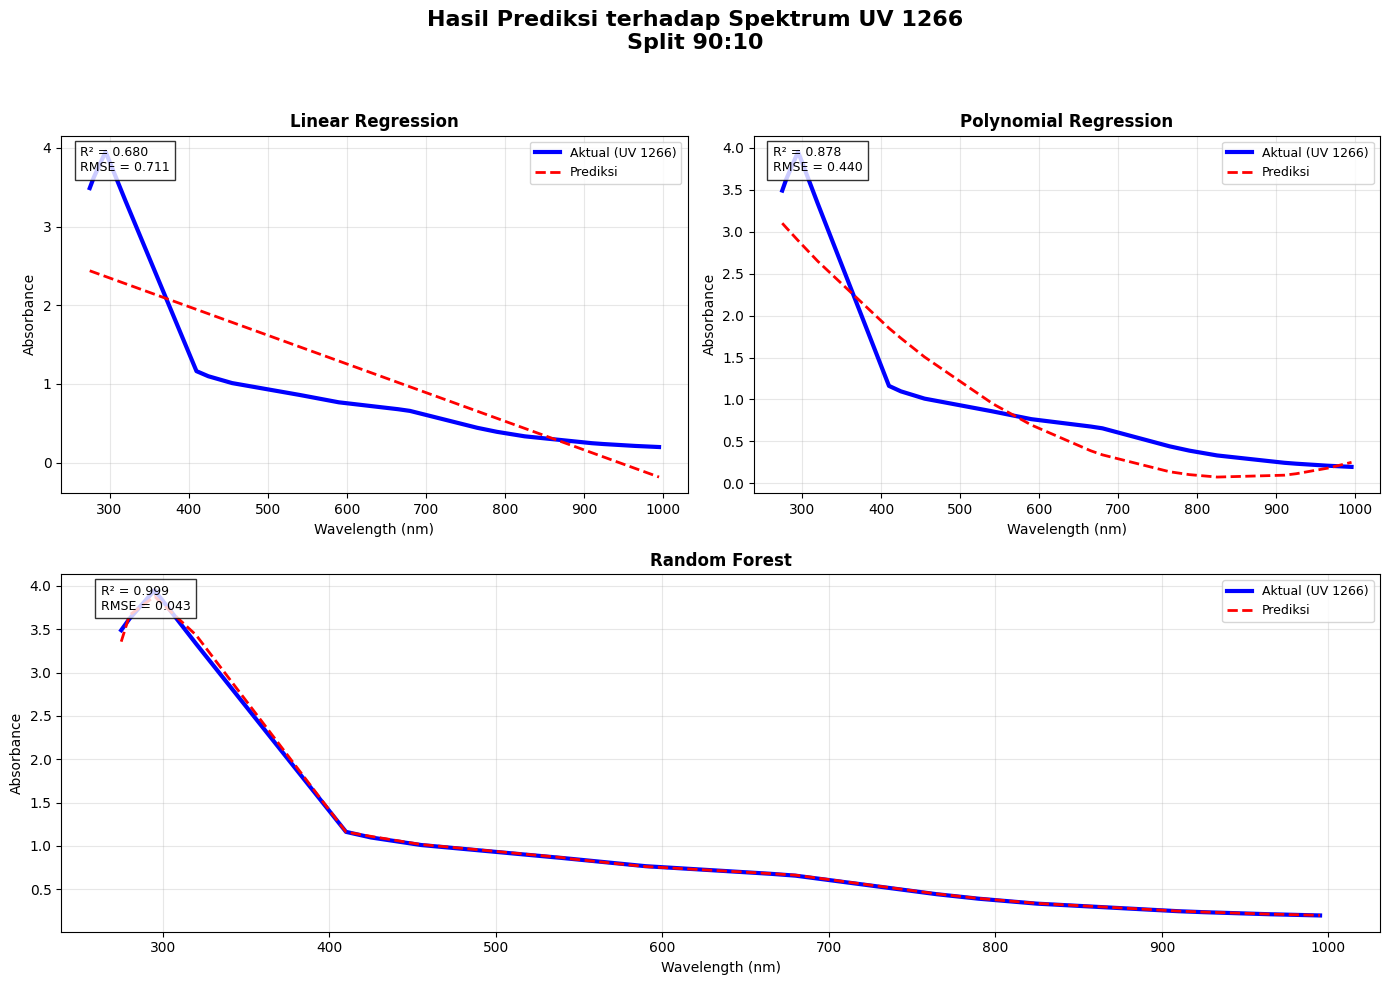

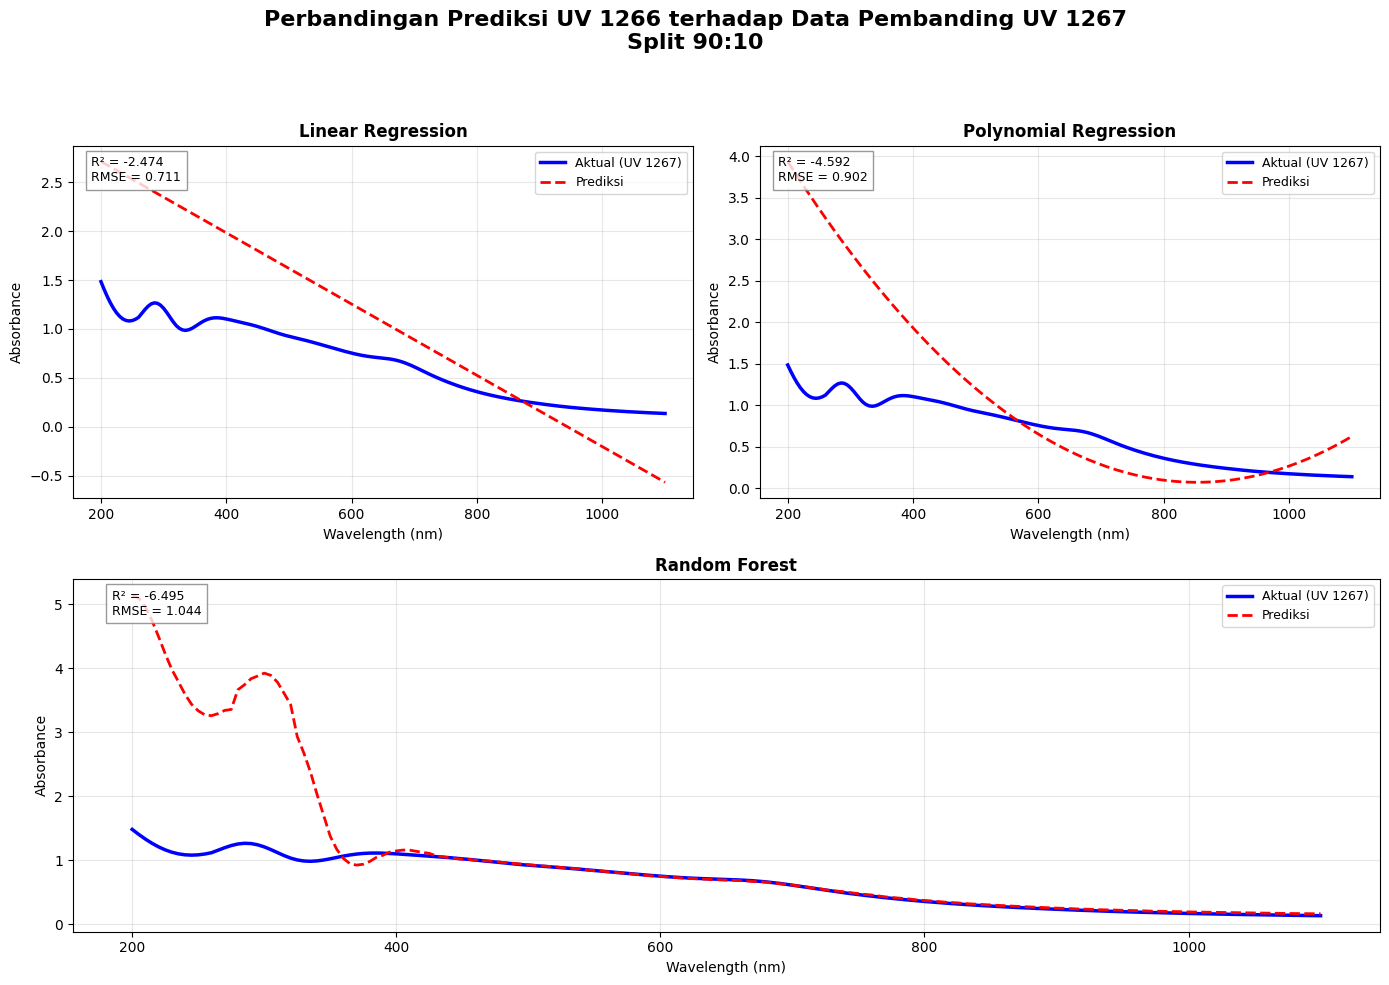

,Scenario,Sample,Comparison,Split,Model,R2,RMSE
0,Scenario 1,UV 1266,UV 1267,90:10,Linear Regression,-2.474156,0.711125
1,Scenario 1,UV 1266,UV 1267,90:10,Polynomial Regression,-4.591811,0.902188
2,Scenario 1,UV 1266,UV 1267,90:10,Random Forest,-6.494566,1.044466


In [39]:
hasil_s1 = []

scenario1_samples = [
    'UV 1264',
    'UV 1265',
    'UV 1266'
]

comparison = sample_data['UV 1267']

for sample in scenario1_samples:

    data = sample_data[sample]

    for ts in split_list:

        # =============================
        # Training
        # =============================

        hasil, models, scaler = run_sample(
            sample_name=sample,
            transformed_data=data,
            test_size=ts,
            show_plot=False
        )

        # =============================
        # Data Pembanding
        # =============================

        X_compare = comparison[['Wavelength']].values

        X_compare_scaled = scaler.transform(X_compare)

        predictions = {}

        comparison_results = []

        # =============================
        # Prediksi semua model
        # =============================

        for model_name, model in models.items():

            pred = model.predict(X_compare_scaled)

            predictions[model_name] = pred

            r2 = r2_score(
                comparison['Absorbance'],
                pred
            )

            rmse = np.sqrt(
                mean_squared_error(
                    comparison['Absorbance'],
                    pred
                )
            )

            comparison_results.append({

                "Scenario": "Scenario 1",

                "Sample": sample,

                "Comparison": "UV 1267",

                "Split": f"{int((1-ts)*100)}:{int(ts*100)}",

                "Model": model_name,

                "R2": r2,

                "RMSE": rmse

            })

        # =============================
        # Grafik 1x3
        # =============================

        evaluation_df = pd.DataFrame(comparison_results)

        plot_comparison_grid(
            comparison_df=comparison,
            predictions=predictions,
            evaluation_df=evaluation_df,
            sample_name=sample,
            comparison_name="UV 1267",
            split_label=f"{int((1-ts)*100)}:{int(ts*100)}"
        )

        display(evaluation_df)

        hasil_s1.append(evaluation_df)

In [ ]:
hasil_s1 = pd.concat(
    hasil_s1,
    ignore_index=True
)

print("\nHASIL SCENARIO 1")

display(hasil_s1)

### Memprediksi dan Memandingkan dengan UV 1268



SAMPEL : UV 1264
Shape X : (181, 1)
Shape y : (181,)

TRAIN DATA


,Wavelength,Absorbance
0,760,0.4573
1,220,3.6904
2,360,1.0427
3,705,0.5584
4,840,0.3606
...,...,...
103,730,0.5099
104,270,2.7046
105,660,0.6311
106,1095,0.2681



TEST DATA


,Wavelength,Absorbance
0,295,2.5257
1,410,1.1009
2,965,0.2942
3,590,0.7313
4,925,0.3086
...,...,...
68,575,0.7594
69,930,0.3065
70,255,2.4765
71,230,3.1441



HASIL EVALUASI


,Sample,Split,Model,R2,RMSE
0,UV 1264,60:40,Linear Regression,0.596734,0.521653
1,UV 1264,60:40,Polynomial Regression,0.754241,0.407231
2,UV 1264,60:40,Random Forest,0.995025,0.057941


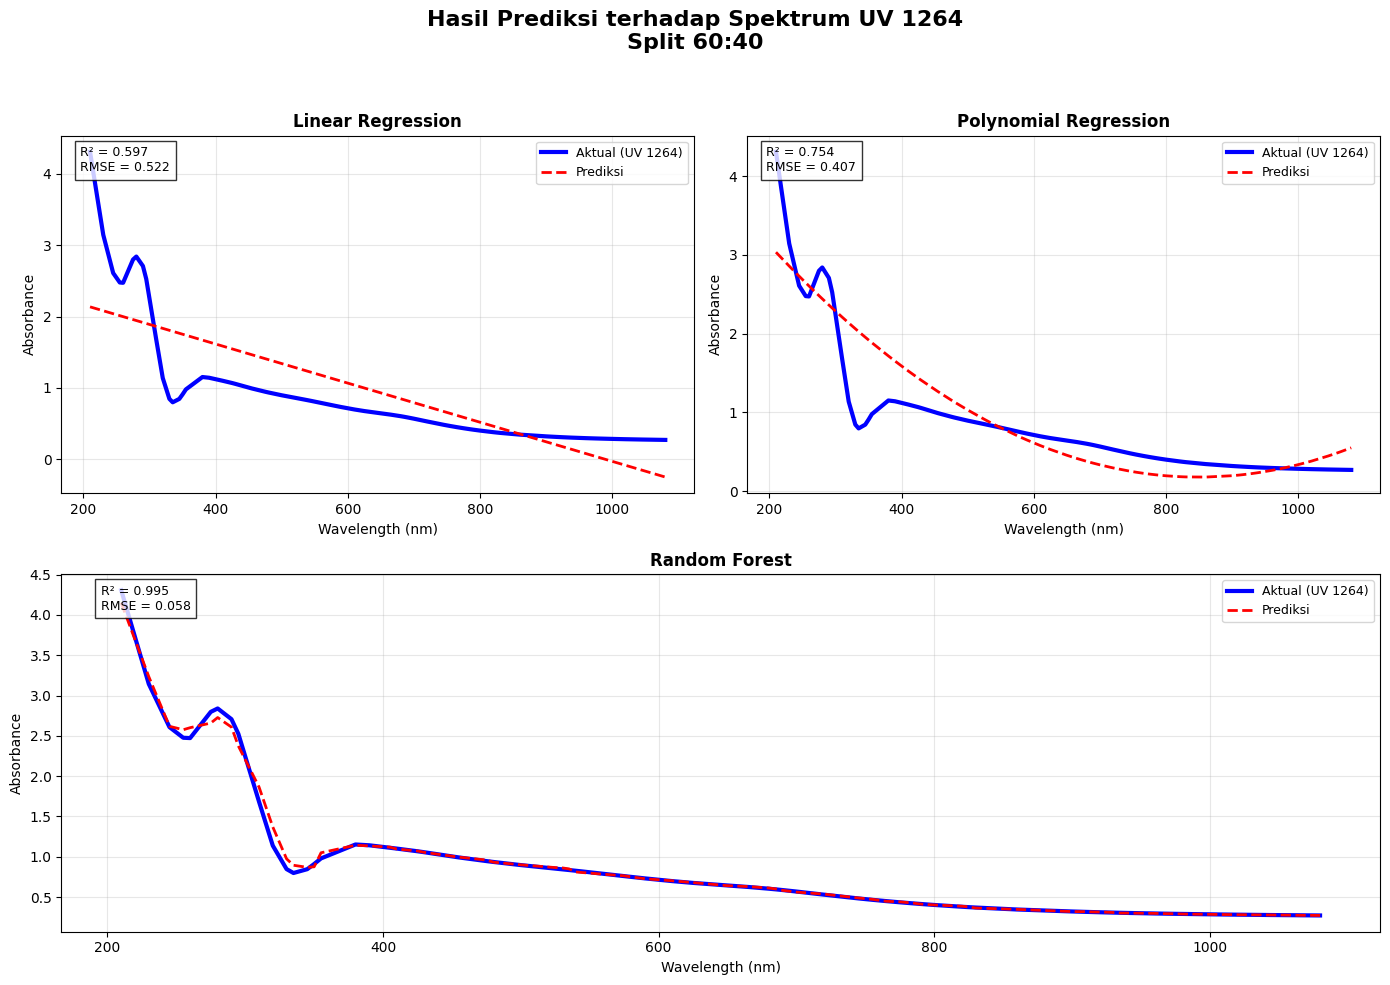

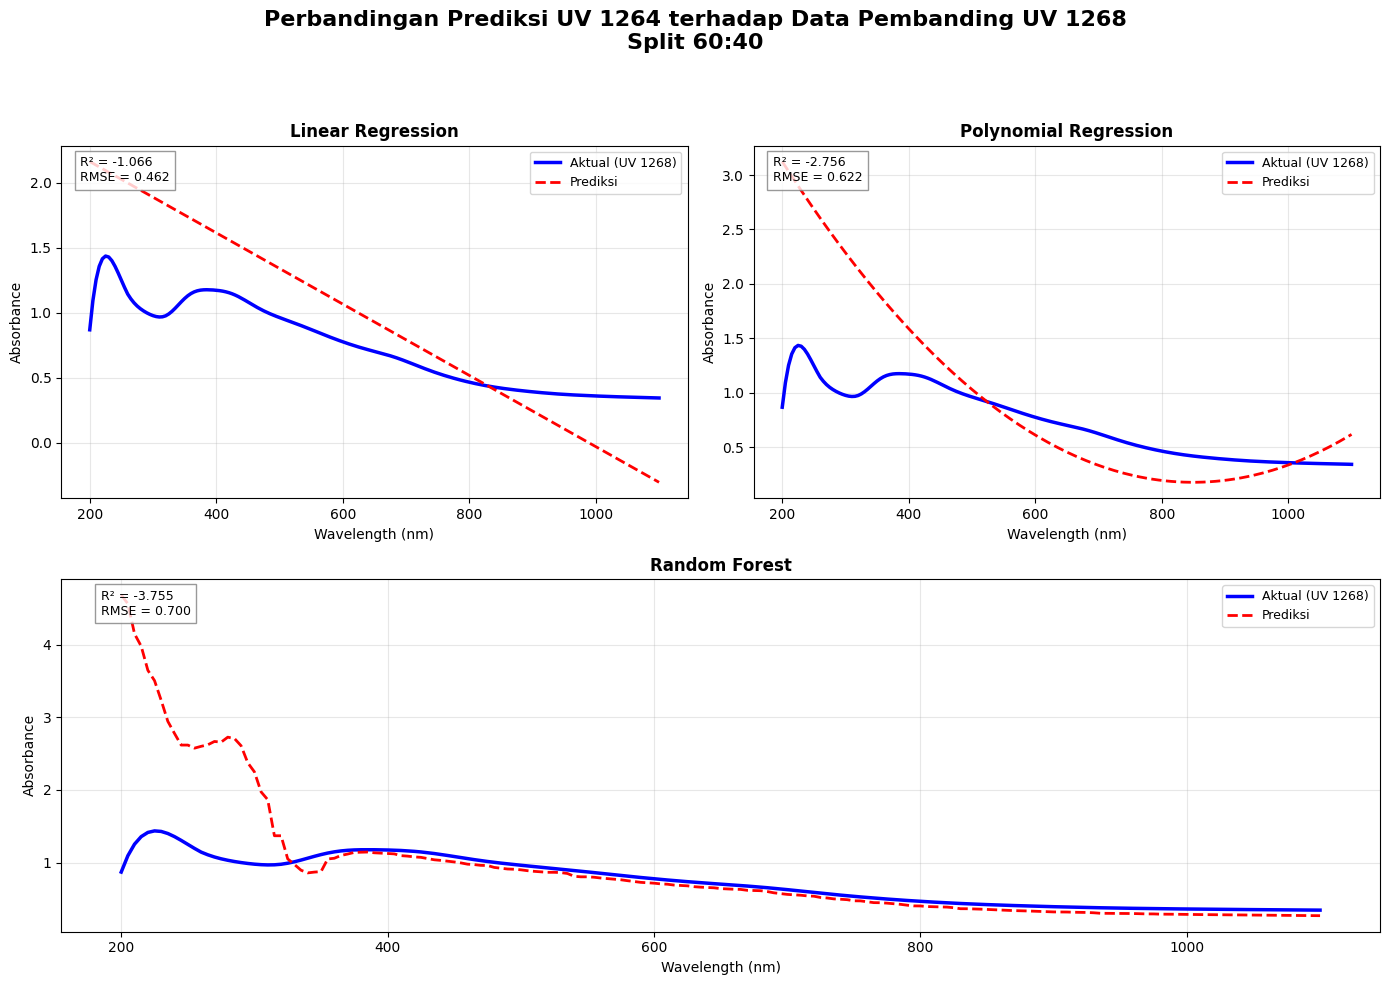

,Scenario,Sample,Comparison,Split,Model,R2,RMSE
0,Scenario 2,UV 1264,UV 1268,60:40,Linear Regression,-1.066267,0.461649
1,Scenario 2,UV 1264,UV 1268,60:40,Polynomial Regression,-2.756468,0.622456
2,Scenario 2,UV 1264,UV 1268,60:40,Random Forest,-3.754618,0.700288




SAMPEL : UV 1264
Shape X : (181, 1)
Shape y : (181,)

TRAIN DATA


,Wavelength,Absorbance
0,625,0.675
1,960,0.2957
2,610,0.6972
3,935,0.3044
4,330,0.8463
...,...,...
121,730,0.5099
122,270,2.7046
123,660,0.6311
124,1095,0.2681



TEST DATA


,Wavelength,Absorbance
0,295,2.5257
1,410,1.1009
2,965,0.2942
3,590,0.7313
4,925,0.3086
5,275,2.7978
6,320,1.1376
7,540,0.8257
8,765,0.4494
9,790,0.4139



HASIL EVALUASI


,Sample,Split,Model,R2,RMSE
0,UV 1264,70:30,Linear Regression,0.606055,0.526247
1,UV 1264,70:30,Polynomial Regression,0.796119,0.378583
2,UV 1264,70:30,Random Forest,0.996370,0.050512


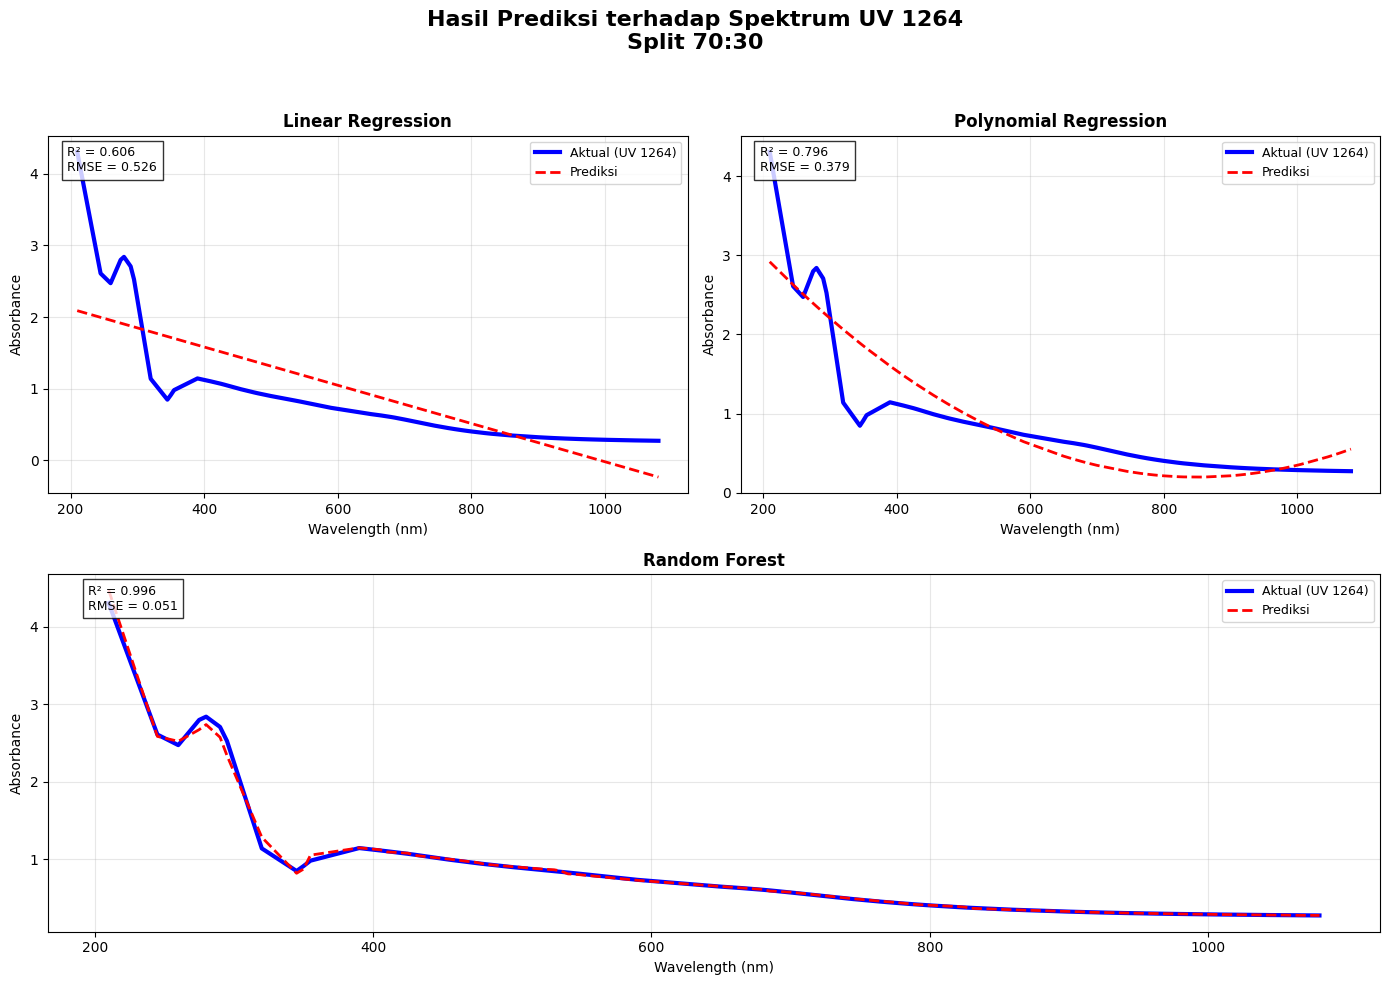

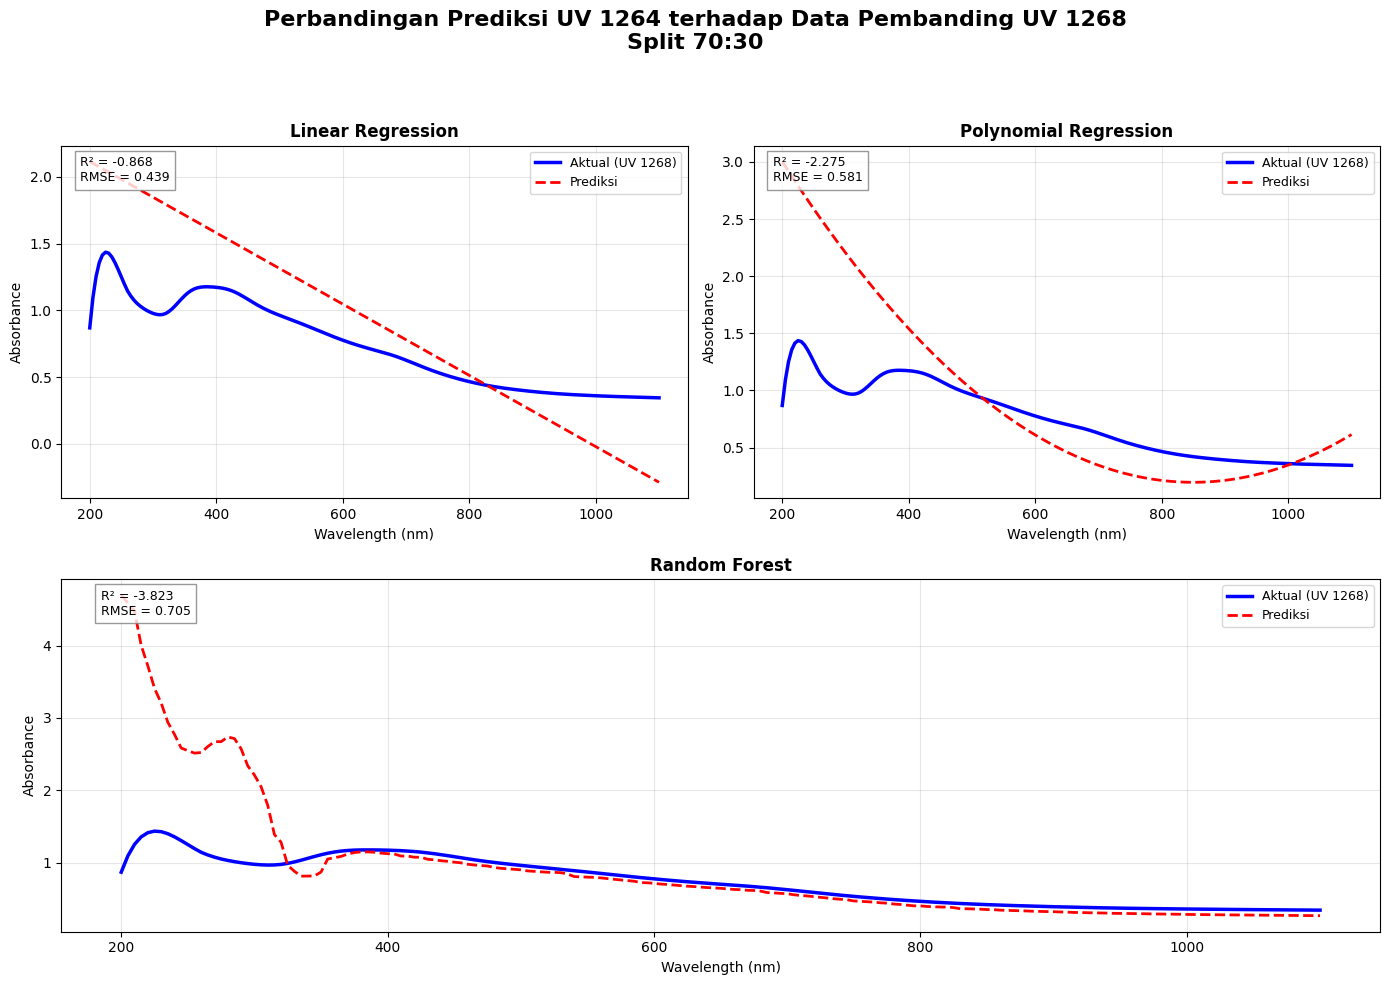

,Scenario,Sample,Comparison,Split,Model,R2,RMSE
0,Scenario 2,UV 1264,UV 1268,70:30,Linear Regression,-0.867651,0.438901
1,Scenario 2,UV 1264,UV 1268,70:30,Polynomial Regression,-2.275045,0.581202
2,Scenario 2,UV 1264,UV 1268,70:30,Random Forest,-3.823421,0.705336




SAMPEL : UV 1264
Shape X : (181, 1)
Shape y : (181,)

TRAIN DATA


,Wavelength,Absorbance
0,525,0.8523
1,535,0.8347
2,355,0.9791
3,260,2.4723
4,405,1.1112
...,...,...
139,730,0.5099
140,270,2.7046
141,660,0.6311
142,1095,0.2681



TEST DATA


,Wavelength,Absorbance
0,295,2.5257
1,410,1.1009
2,965,0.2942
3,590,0.7313
4,925,0.3086
5,275,2.7978
6,320,1.1376
7,540,0.8257
8,765,0.4494
9,790,0.4139



HASIL EVALUASI


,Sample,Split,Model,R2,RMSE
0,UV 1264,80:20,Linear Regression,0.644148,0.455123
1,UV 1264,80:20,Polynomial Regression,0.791625,0.348271
2,UV 1264,80:20,Random Forest,0.996429,0.045590


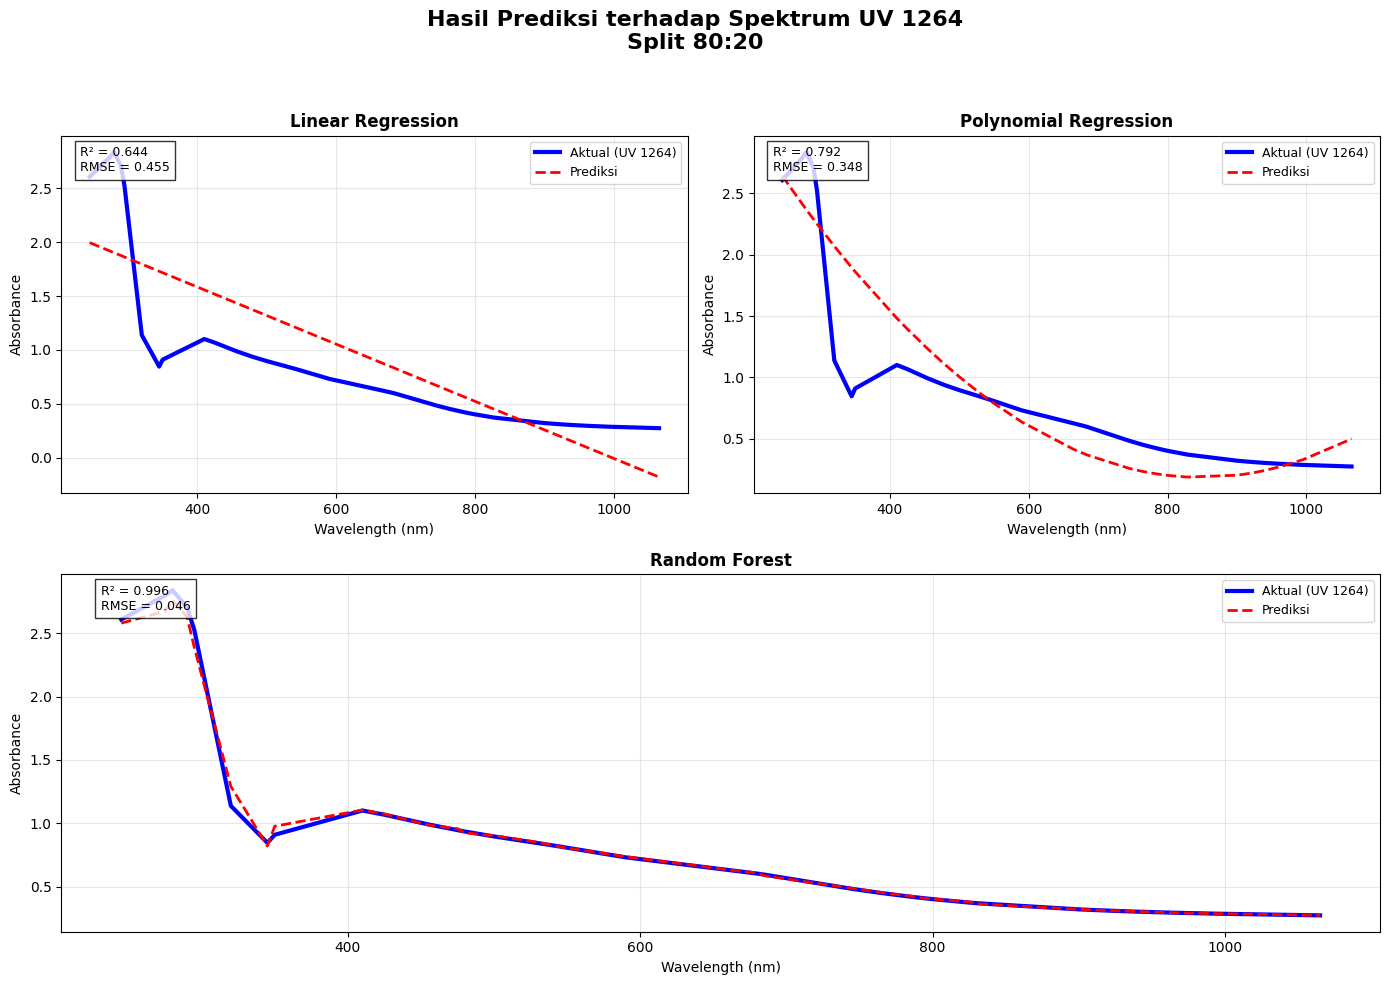

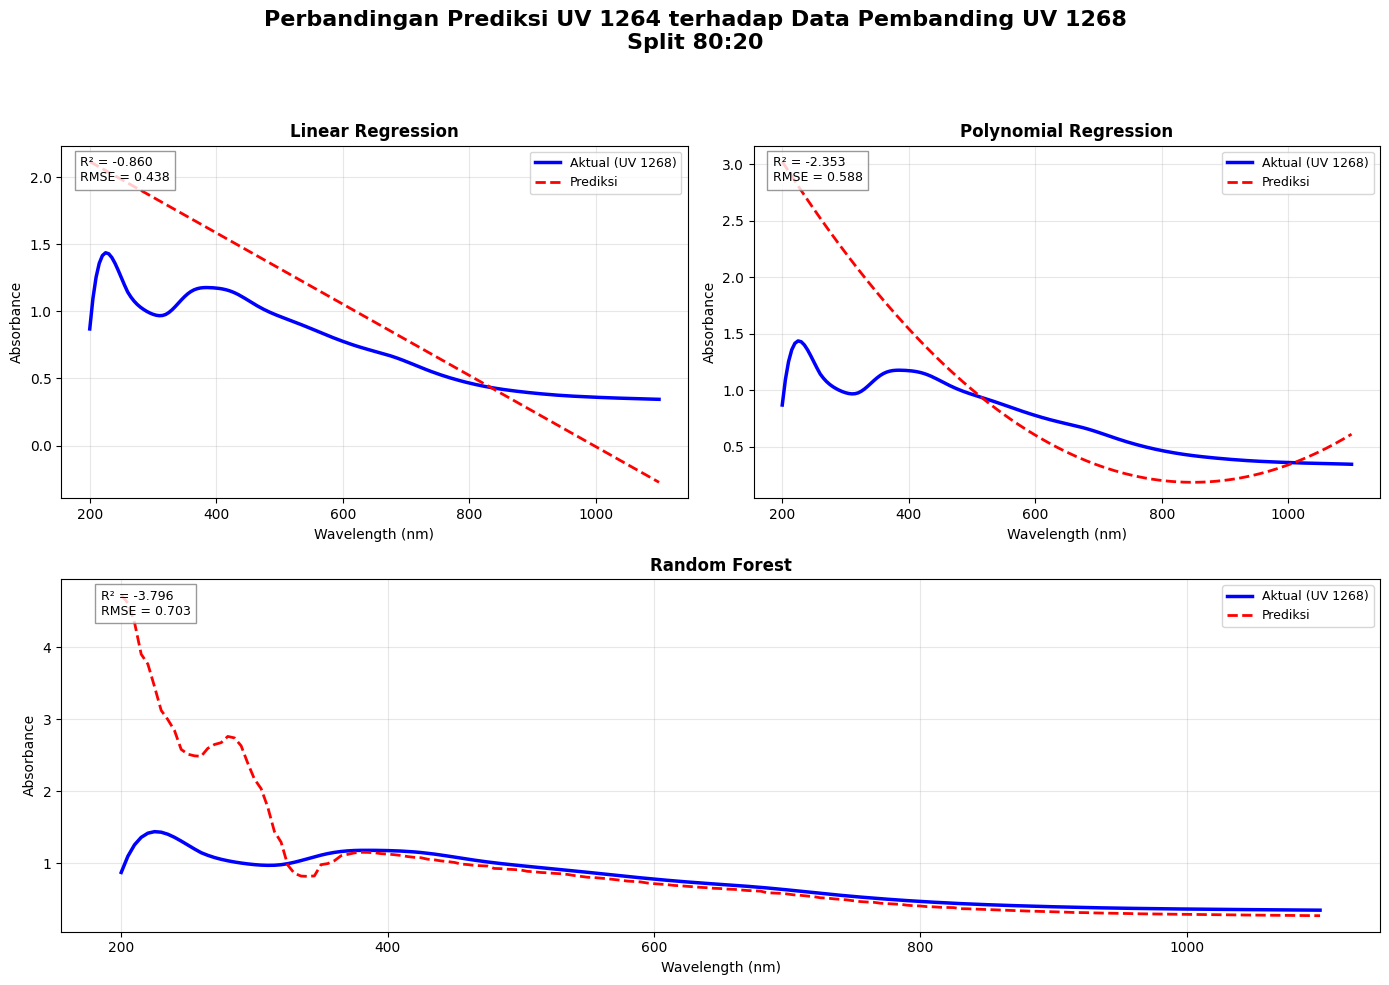

,Scenario,Sample,Comparison,Split,Model,R2,RMSE
0,Scenario 2,UV 1264,UV 1268,80:20,Linear Regression,-0.860434,0.438052
1,Scenario 2,UV 1264,UV 1268,80:20,Polynomial Regression,-2.353332,0.588108
2,Scenario 2,UV 1264,UV 1268,80:20,Random Forest,-3.795965,0.703326




SAMPEL : UV 1264
Shape X : (181, 1)
Shape y : (181,)

TRAIN DATA


,Wavelength,Absorbance
0,480,0.9353
1,685,0.5949
2,800,0.4014
3,915,0.3132
4,350,0.9094
...,...,...
157,730,0.5099
158,270,2.7046
159,660,0.6311
160,1095,0.2681



TEST DATA


,Wavelength,Absorbance
0,295,2.5257
1,410,1.1009
2,965,0.2942
3,590,0.7313
4,925,0.3086
5,275,2.7978
6,320,1.1376
7,540,0.8257
8,765,0.4494
9,790,0.4139



HASIL EVALUASI


,Sample,Split,Model,R2,RMSE
0,UV 1264,90:10,Linear Regression,0.686715,0.452037
1,UV 1264,90:10,Polynomial Regression,0.849001,0.313828
2,UV 1264,90:10,Random Forest,0.995807,0.052293


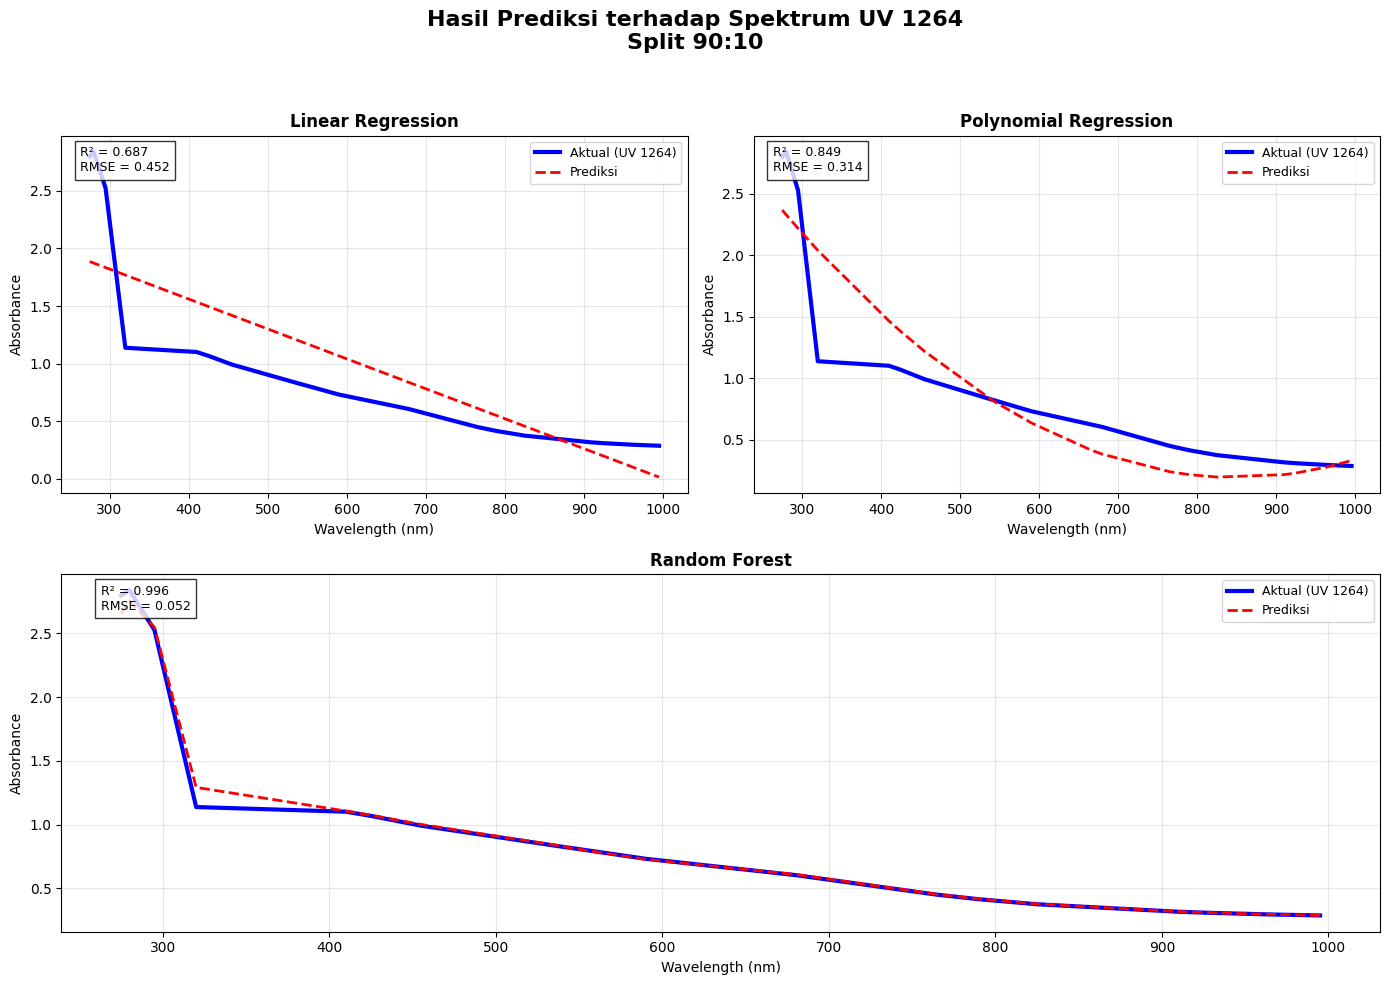

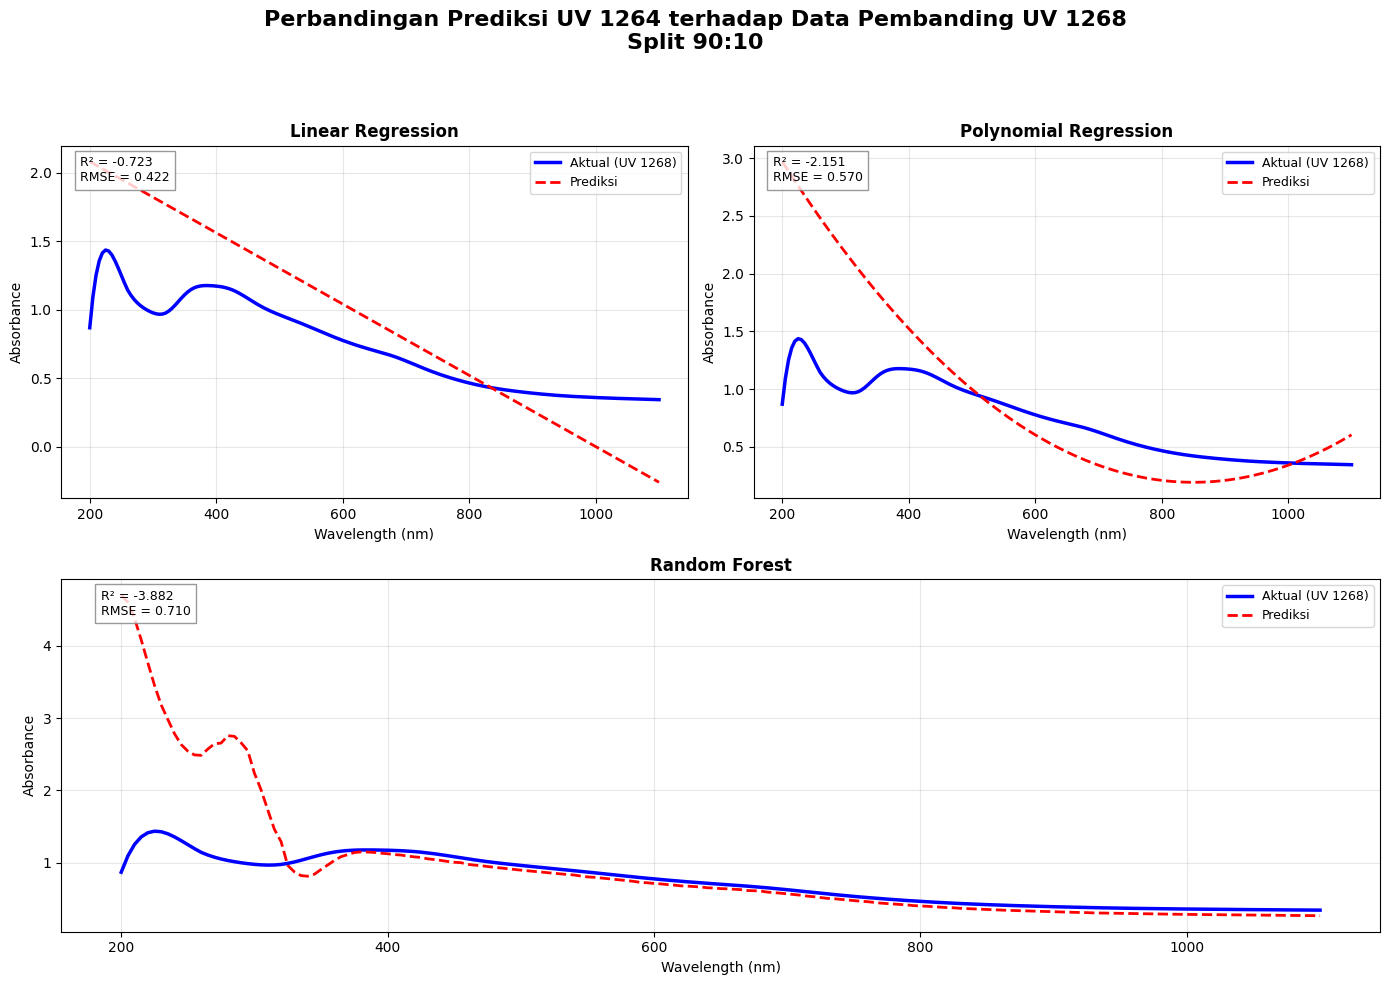

,Scenario,Sample,Comparison,Split,Model,R2,RMSE
0,Scenario 2,UV 1264,UV 1268,90:10,Linear Regression,-0.722830,0.421541
1,Scenario 2,UV 1264,UV 1268,90:10,Polynomial Regression,-2.151382,0.570124
2,Scenario 2,UV 1264,UV 1268,90:10,Random Forest,-3.882091,0.709613




SAMPEL : UV 1265
Shape X : (181, 1)
Shape y : (181,)

TRAIN DATA


,Wavelength,Absorbance
0,760,0.4526
1,220,3.8294
2,360,0.9995
3,705,0.5985
4,840,0.3136
...,...,...
103,730,0.5288
104,270,0.8914
105,660,0.6832
106,1095,0.1657



TEST DATA


,Wavelength,Absorbance
0,295,1.9538
1,410,1.1399
2,965,0.2108
3,590,0.7662
4,925,0.2348
...,...,...
68,575,0.7937
69,930,0.2313
70,255,0.9102
71,230,2.6797



HASIL EVALUASI


,Sample,Split,Model,R2,RMSE
0,UV 1265,60:40,Linear Regression,0.541387,0.506828
1,UV 1265,60:40,Polynomial Regression,0.550878,0.501556
2,UV 1265,60:40,Random Forest,0.992735,0.063791


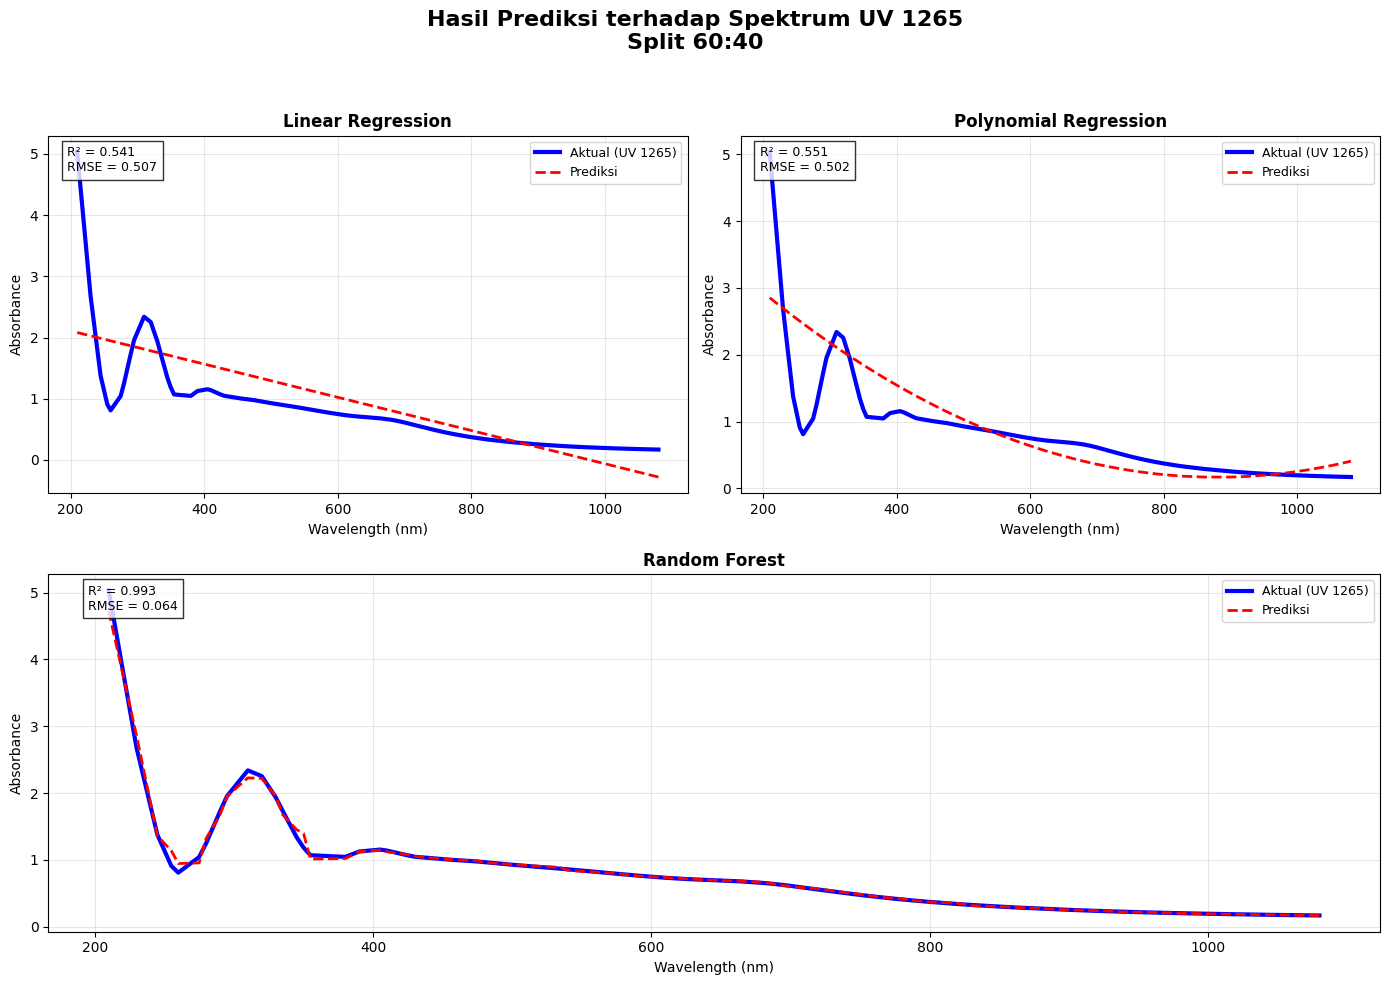

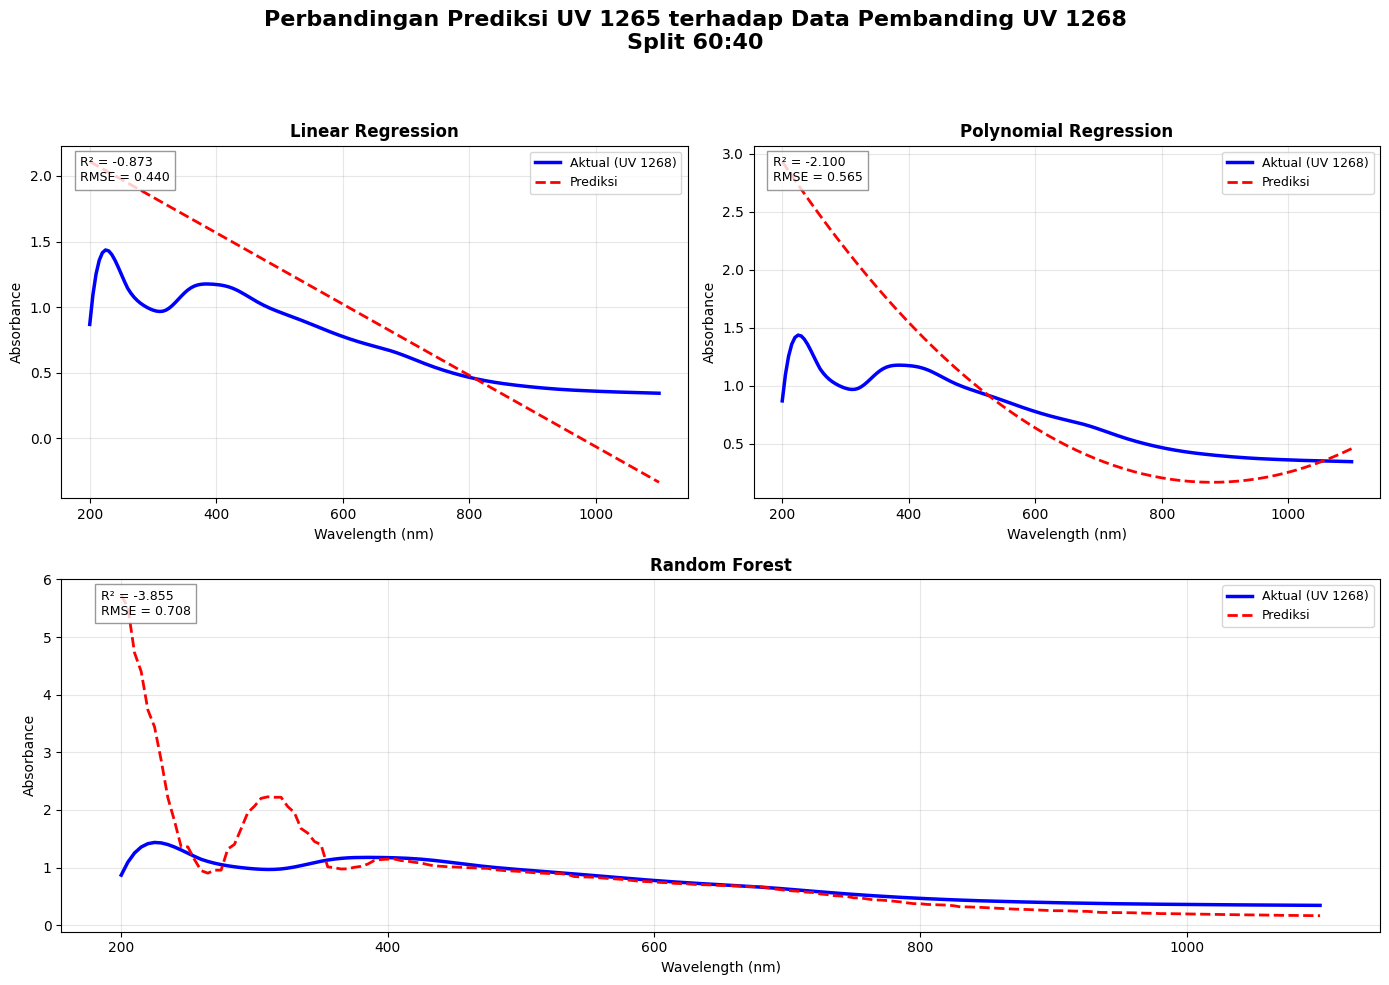

,Scenario,Sample,Comparison,Split,Model,R2,RMSE
0,Scenario 2,UV 1265,UV 1268,60:40,Linear Regression,-0.872827,0.439509
1,Scenario 2,UV 1265,UV 1268,60:40,Polynomial Regression,-2.099897,0.565448
2,Scenario 2,UV 1265,UV 1268,60:40,Random Forest,-3.855204,0.707657




SAMPEL : UV 1265
Shape X : (181, 1)
Shape y : (181,)

TRAIN DATA


,Wavelength,Absorbance
0,625,0.7144
1,960,0.2133
2,610,0.7337
3,935,0.228
4,330,1.9379
...,...,...
121,730,0.5288
122,270,0.8914
123,660,0.6832
124,1095,0.1657



TEST DATA


,Wavelength,Absorbance
0,295,1.9538
1,410,1.1399
2,965,0.2108
3,590,0.7662
4,925,0.2348
5,275,1.0436
6,320,2.2541
7,540,0.8595
8,765,0.4412
9,790,0.39



HASIL EVALUASI


,Sample,Split,Model,R2,RMSE
0,UV 1265,70:30,Linear Regression,0.488901,0.535297
1,UV 1265,70:30,Polynomial Regression,0.538044,0.508912
2,UV 1265,70:30,Random Forest,0.991157,0.070413


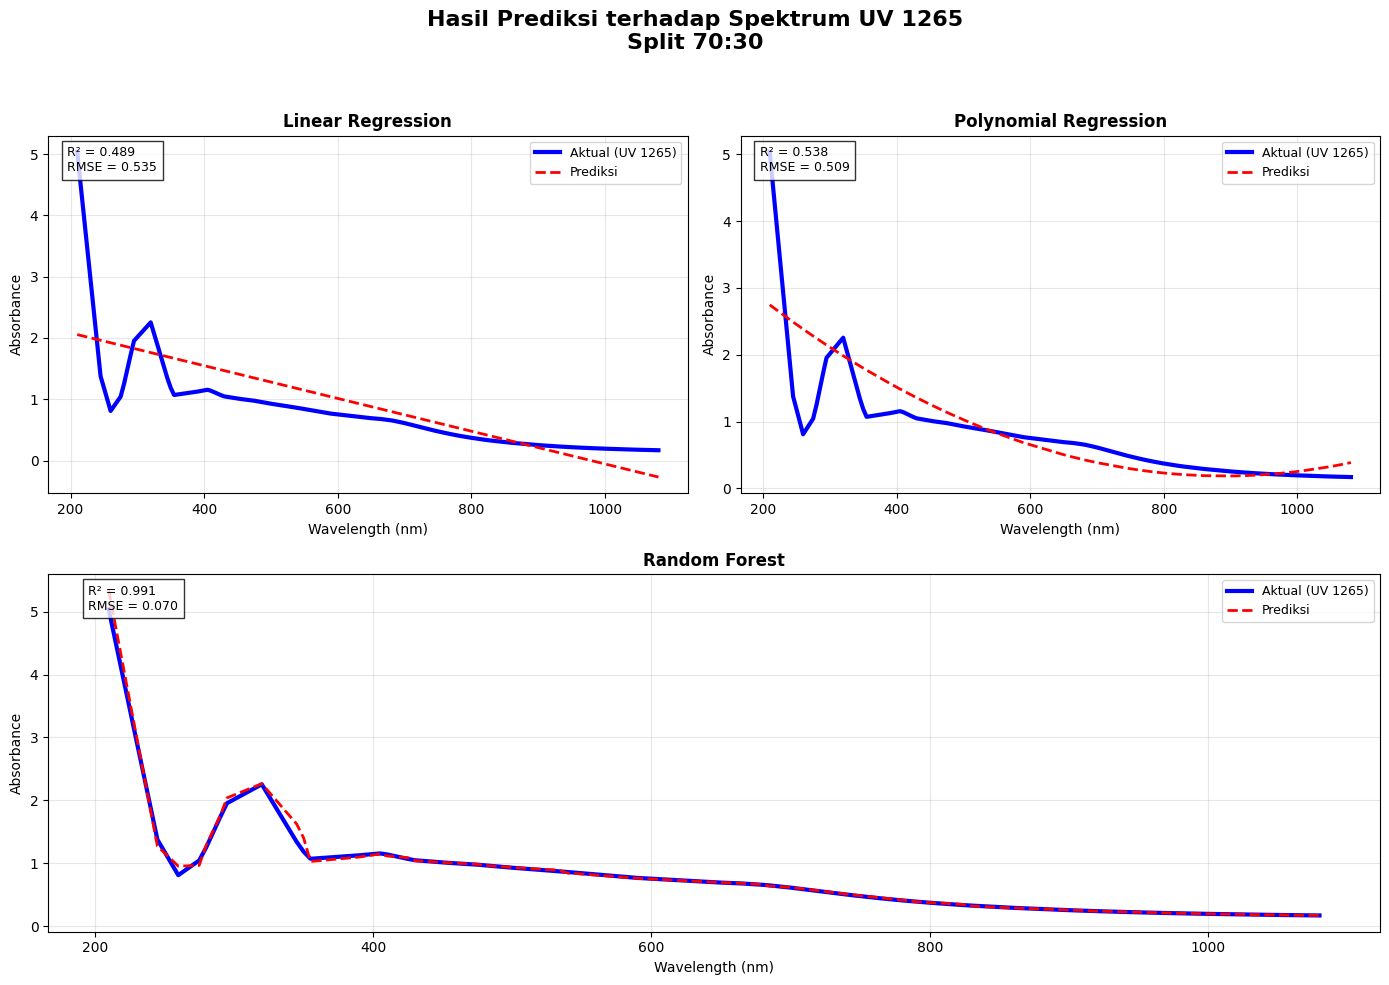

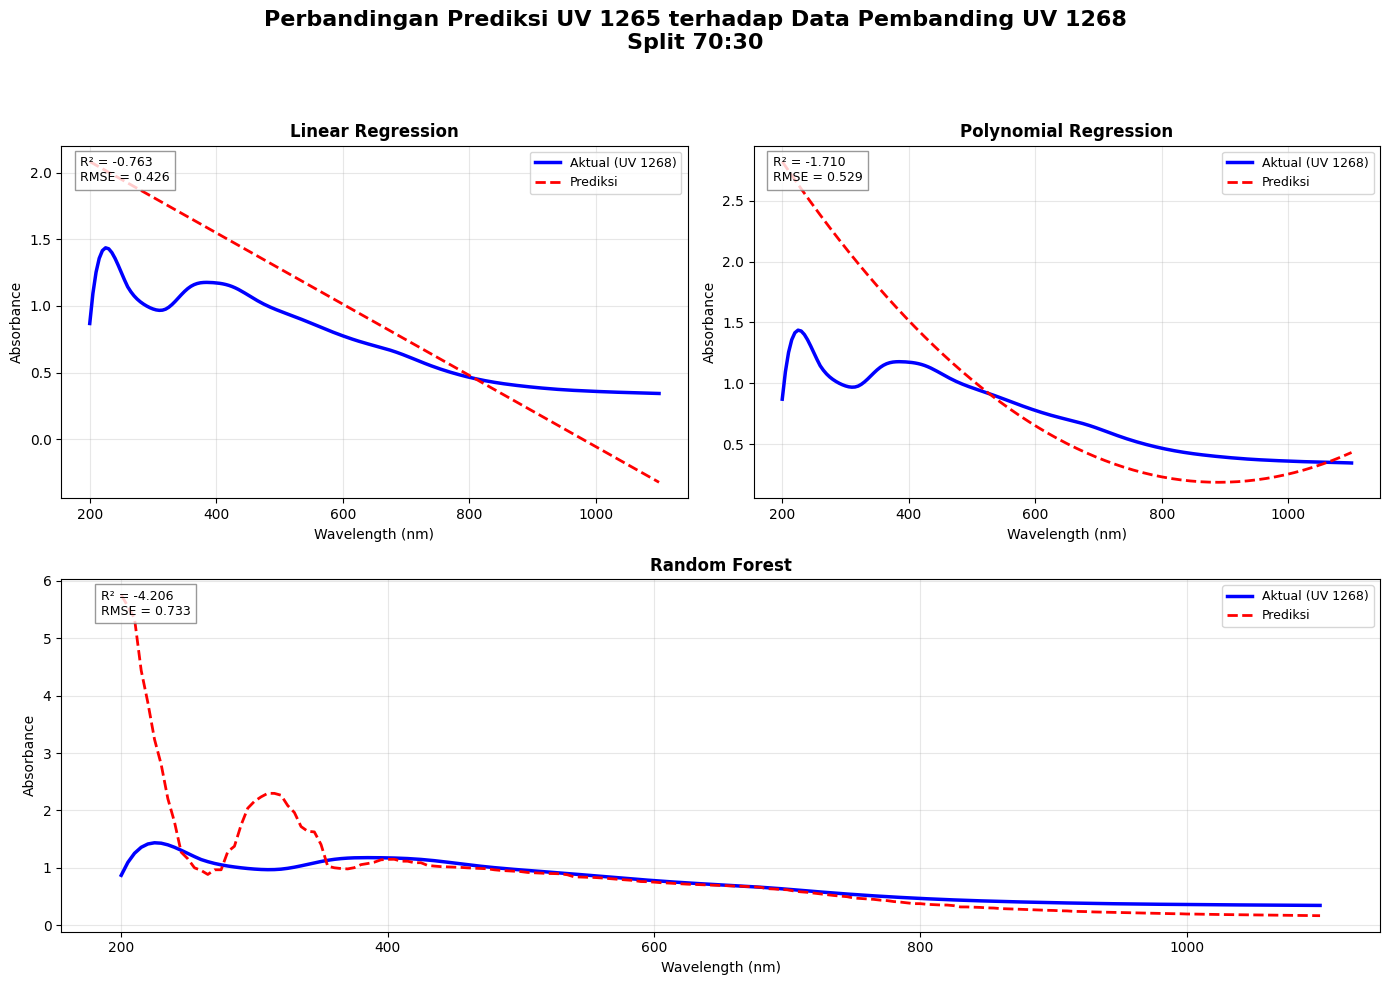

,Scenario,Sample,Comparison,Split,Model,R2,RMSE
0,Scenario 2,UV 1265,UV 1268,70:30,Linear Regression,-0.762694,0.426390
1,Scenario 2,UV 1265,UV 1268,70:30,Polynomial Regression,-1.709516,0.528646
2,Scenario 2,UV 1265,UV 1268,70:30,Random Forest,-4.205525,0.732742




SAMPEL : UV 1265
Shape X : (181, 1)
Shape y : (181,)

TRAIN DATA


,Wavelength,Absorbance
0,525,0.8855
1,535,0.8683
2,355,1.0705
3,260,0.8102
4,405,1.1554
...,...,...
139,730,0.5288
140,270,0.8914
141,660,0.6832
142,1095,0.1657



TEST DATA


,Wavelength,Absorbance
0,295,1.9538
1,410,1.1399
2,965,0.2108
3,590,0.7662
4,925,0.2348
5,275,1.0436
6,320,2.2541
7,540,0.8595
8,765,0.4412
9,790,0.39



HASIL EVALUASI


,Sample,Split,Model,R2,RMSE
0,UV 1265,80:20,Linear Regression,0.612800,0.322010
1,UV 1265,80:20,Polynomial Regression,0.449189,0.384064
2,UV 1265,80:20,Random Forest,0.991850,0.046716


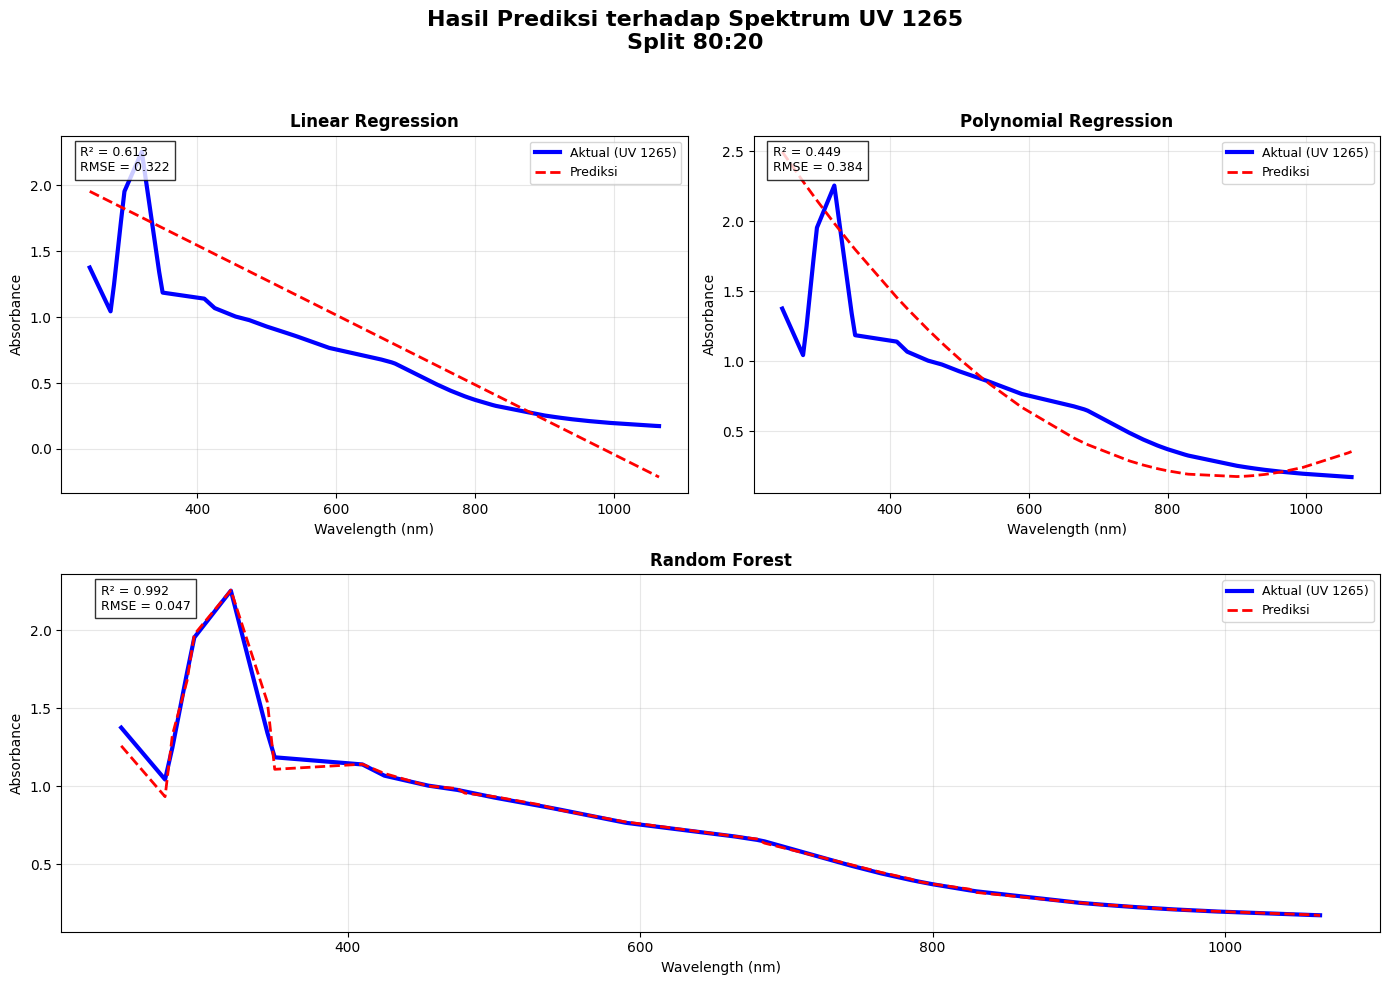

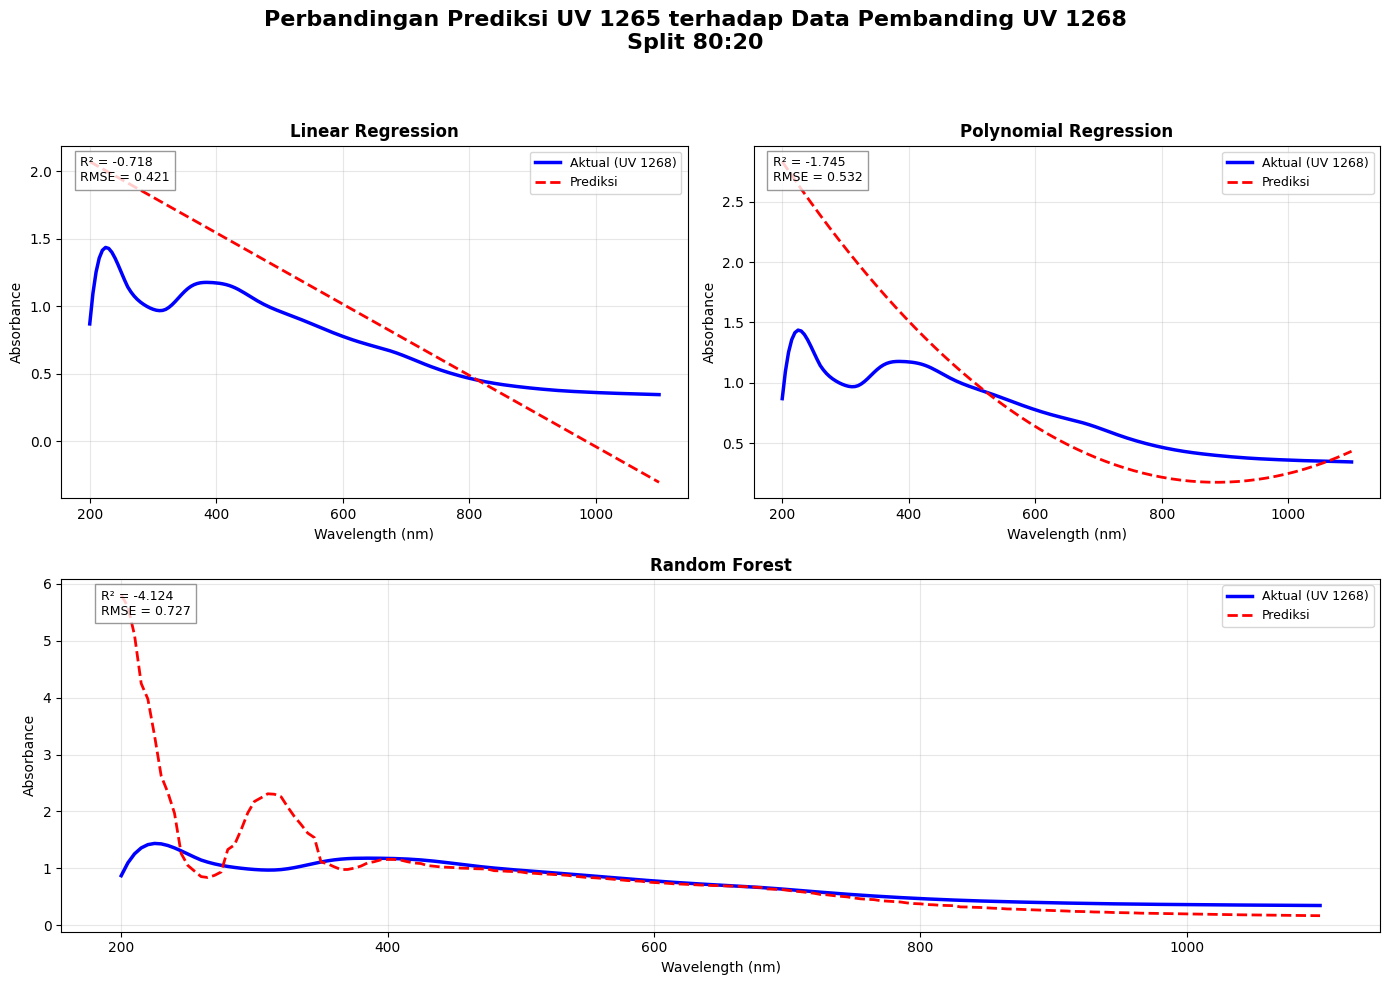

,Scenario,Sample,Comparison,Split,Model,R2,RMSE
0,Scenario 2,UV 1265,UV 1268,80:20,Linear Regression,-0.717713,0.420915
1,Scenario 2,UV 1265,UV 1268,80:20,Polynomial Regression,-1.744651,0.532062
2,Scenario 2,UV 1265,UV 1268,80:20,Random Forest,-4.124274,0.727001




SAMPEL : UV 1265
Shape X : (181, 1)
Shape y : (181,)

TRAIN DATA


,Wavelength,Absorbance
0,480,0.967
1,685,0.6469
2,800,0.3721
3,915,0.242
4,350,1.1858
...,...,...
157,730,0.5288
158,270,0.8914
159,660,0.6832
160,1095,0.1657



TEST DATA


,Wavelength,Absorbance
0,295,1.9538
1,410,1.1399
2,965,0.2108
3,590,0.7662
4,925,0.2348
5,275,1.0436
6,320,2.2541
7,540,0.8595
8,765,0.4412
9,790,0.39



HASIL EVALUASI


,Sample,Split,Model,R2,RMSE
0,UV 1265,90:10,Linear Regression,0.653368,0.325909
1,UV 1265,90:10,Polynomial Regression,0.534224,0.377791
2,UV 1265,90:10,Random Forest,0.991455,0.051171


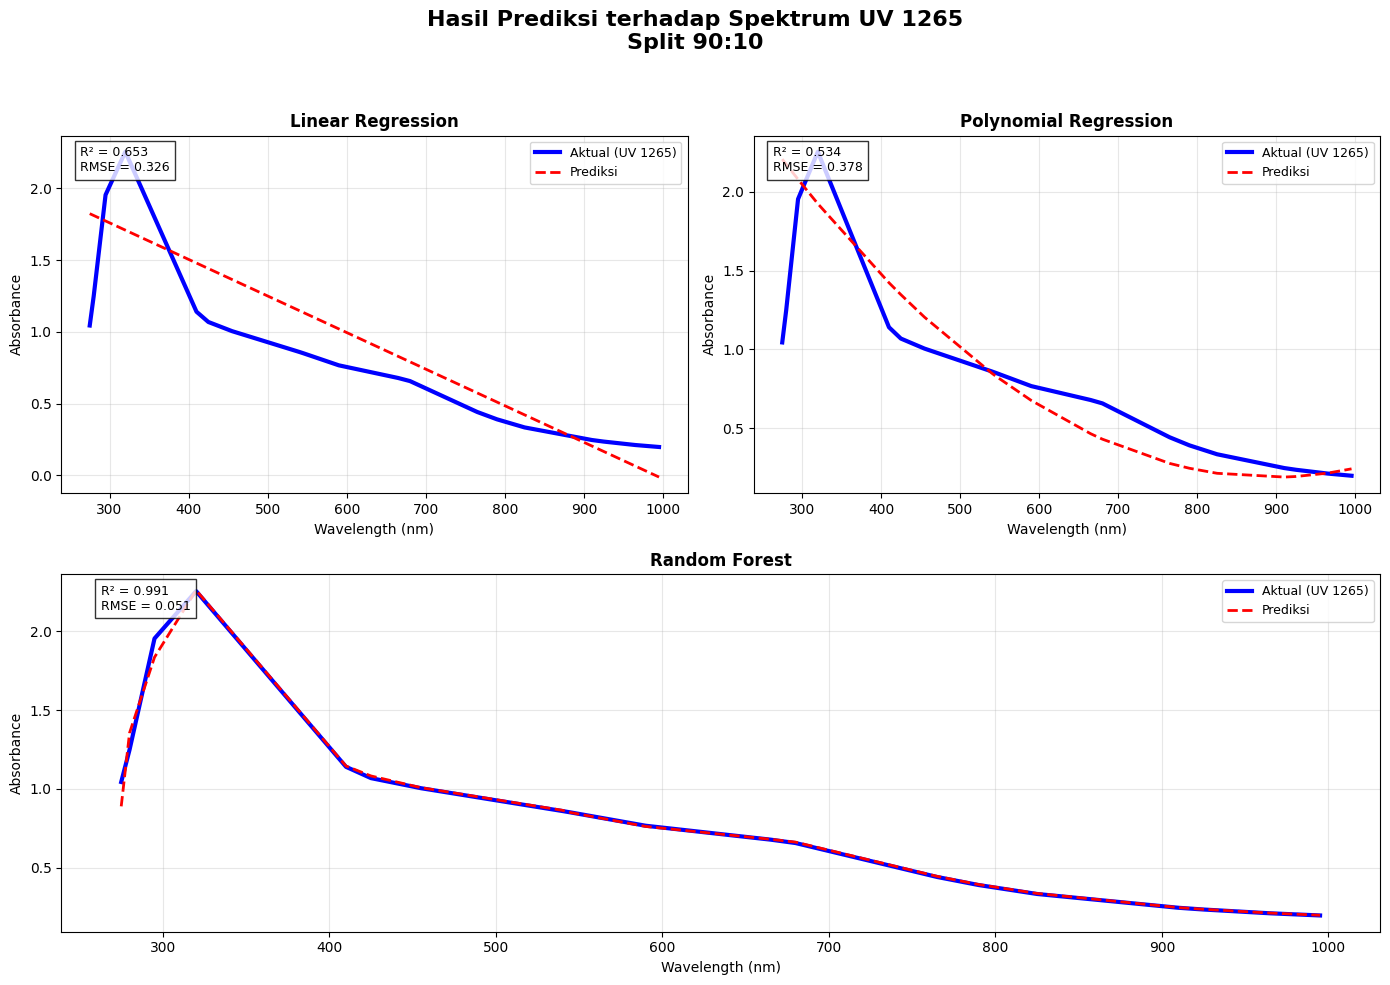

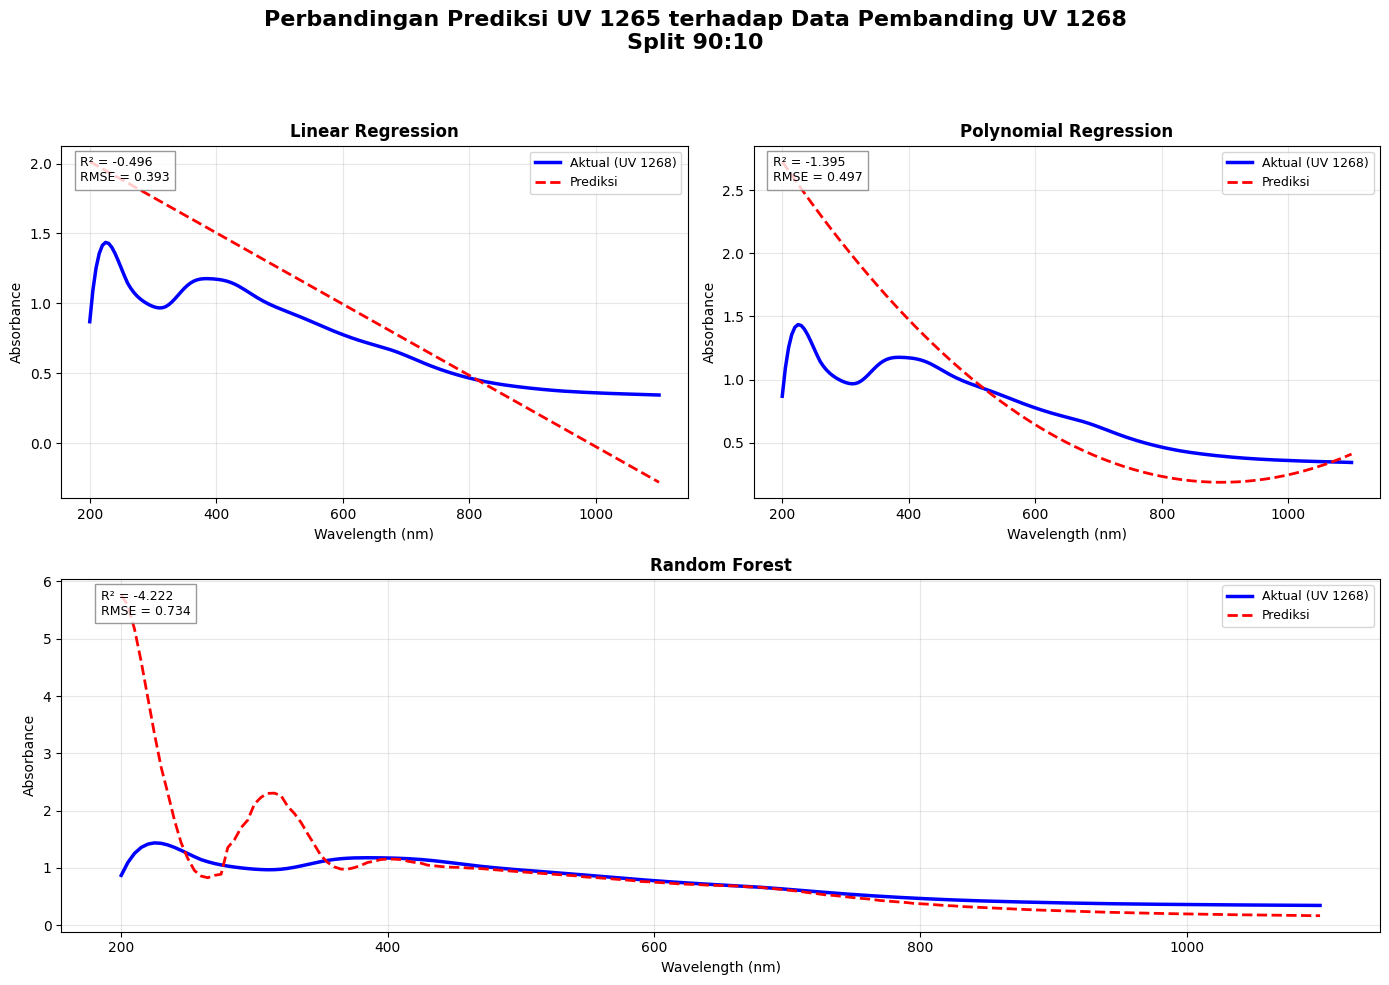

,Scenario,Sample,Comparison,Split,Model,R2,RMSE
0,Scenario 2,UV 1265,UV 1268,90:10,Linear Regression,-0.496476,0.392874
1,Scenario 2,UV 1265,UV 1268,90:10,Polynomial Regression,-1.395272,0.497046
2,Scenario 2,UV 1265,UV 1268,90:10,Random Forest,-4.221704,0.733880




SAMPEL : UV 1266
Shape X : (181, 1)
Shape y : (181,)

TRAIN DATA


,Wavelength,Absorbance
0,760,0.4534
1,220,4.4369
2,360,0.9993
3,705,0.599
4,840,0.3139
...,...,...
103,730,0.5294
104,270,3.3737
105,660,0.6833
106,1095,0.1661



TEST DATA


,Wavelength,Absorbance
0,295,3.9506
1,410,1.162
2,965,0.2112
3,590,0.7658
4,925,0.2352
...,...,...
68,575,0.7934
69,930,0.2317
70,255,3.2576
71,230,3.9494



HASIL EVALUASI


,Sample,Split,Model,R2,RMSE
0,UV 1266,60:40,Linear Regression,0.662691,0.695484
1,UV 1266,60:40,Polynomial Regression,0.853266,0.458711
2,UV 1266,60:40,Random Forest,0.997552,0.059248


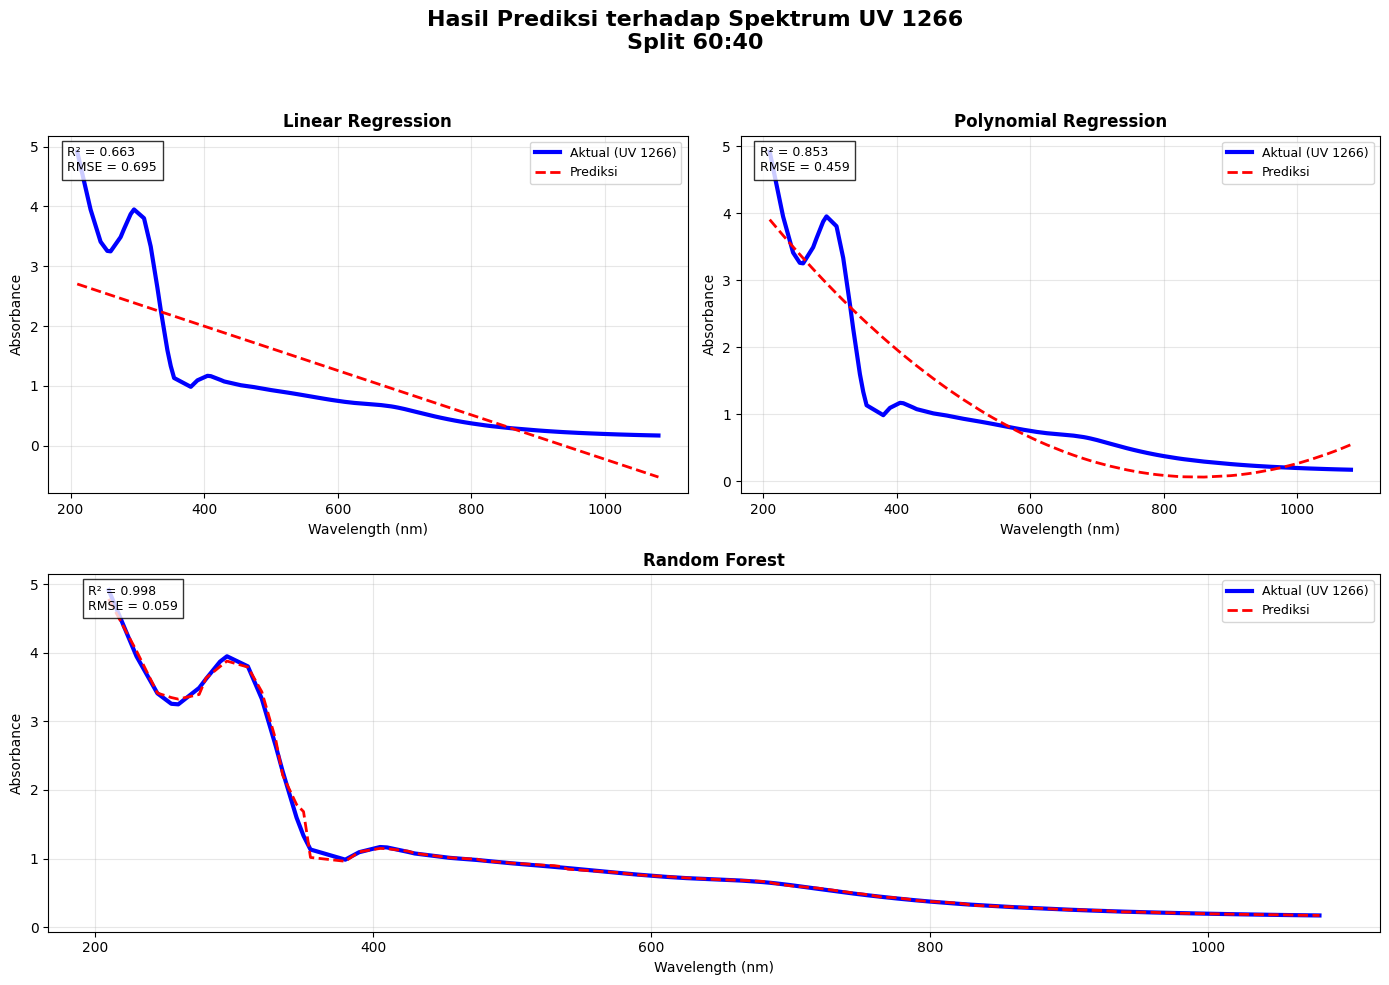

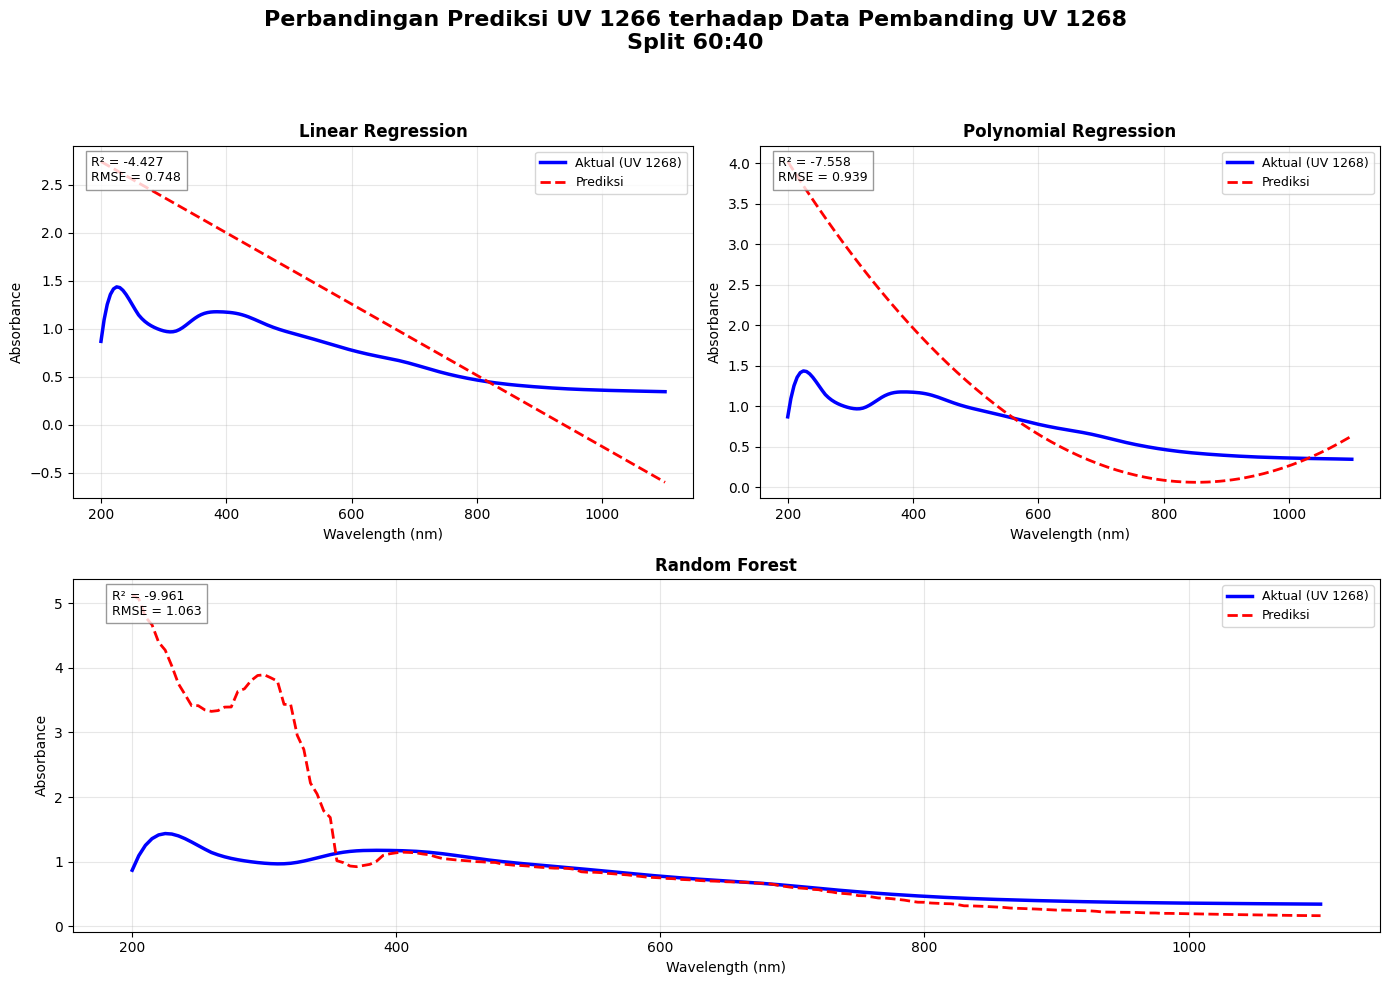

,Scenario,Sample,Comparison,Split,Model,R2,RMSE
0,Scenario 2,UV 1266,UV 1268,60:40,Linear Regression,-4.427215,0.748182
1,Scenario 2,UV 1266,UV 1268,60:40,Polynomial Regression,-7.557562,0.939494
2,Scenario 2,UV 1266,UV 1268,60:40,Random Forest,-9.960940,1.063268




SAMPEL : UV 1266
Shape X : (181, 1)
Shape y : (181,)

TRAIN DATA


,Wavelength,Absorbance
0,625,0.7145
1,960,0.2137
2,610,0.7336
3,935,0.2284
4,330,2.6432
...,...,...
121,730,0.5294
122,270,3.3737
123,660,0.6833
124,1095,0.1661



TEST DATA


,Wavelength,Absorbance
0,295,3.9506
1,410,1.162
2,965,0.2112
3,590,0.7658
4,925,0.2352
5,275,3.4888
6,320,3.3315
7,540,0.8603
8,765,0.442
9,790,0.3906



HASIL EVALUASI


,Sample,Split,Model,R2,RMSE
0,UV 1266,70:30,Linear Regression,0.629928,0.712486
1,UV 1266,70:30,Polynomial Regression,0.834952,0.475816
2,UV 1266,70:30,Random Forest,0.994462,0.087162


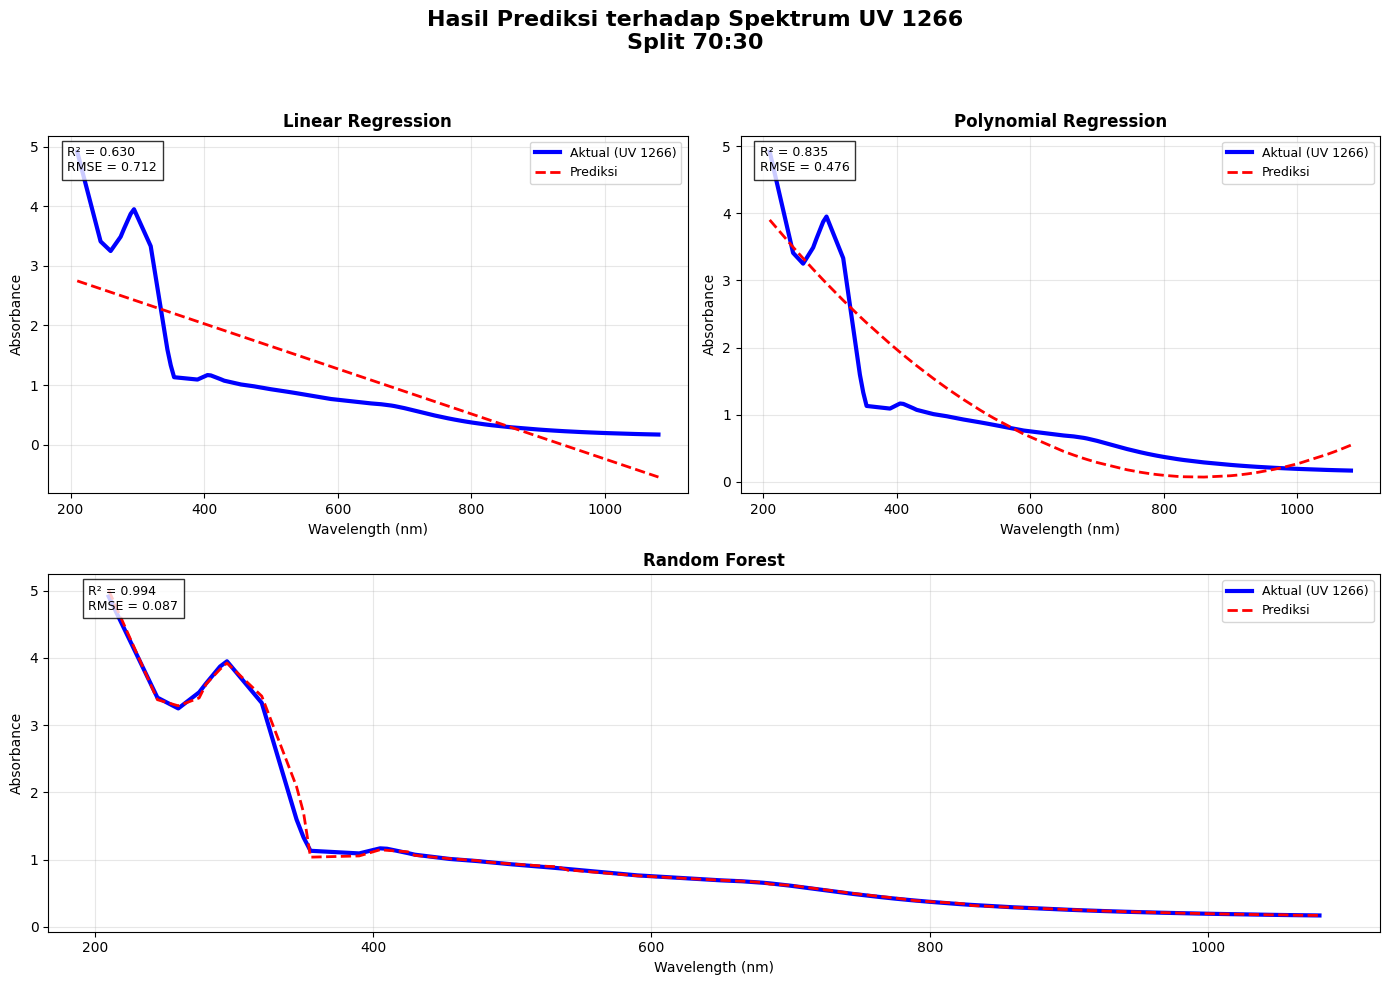

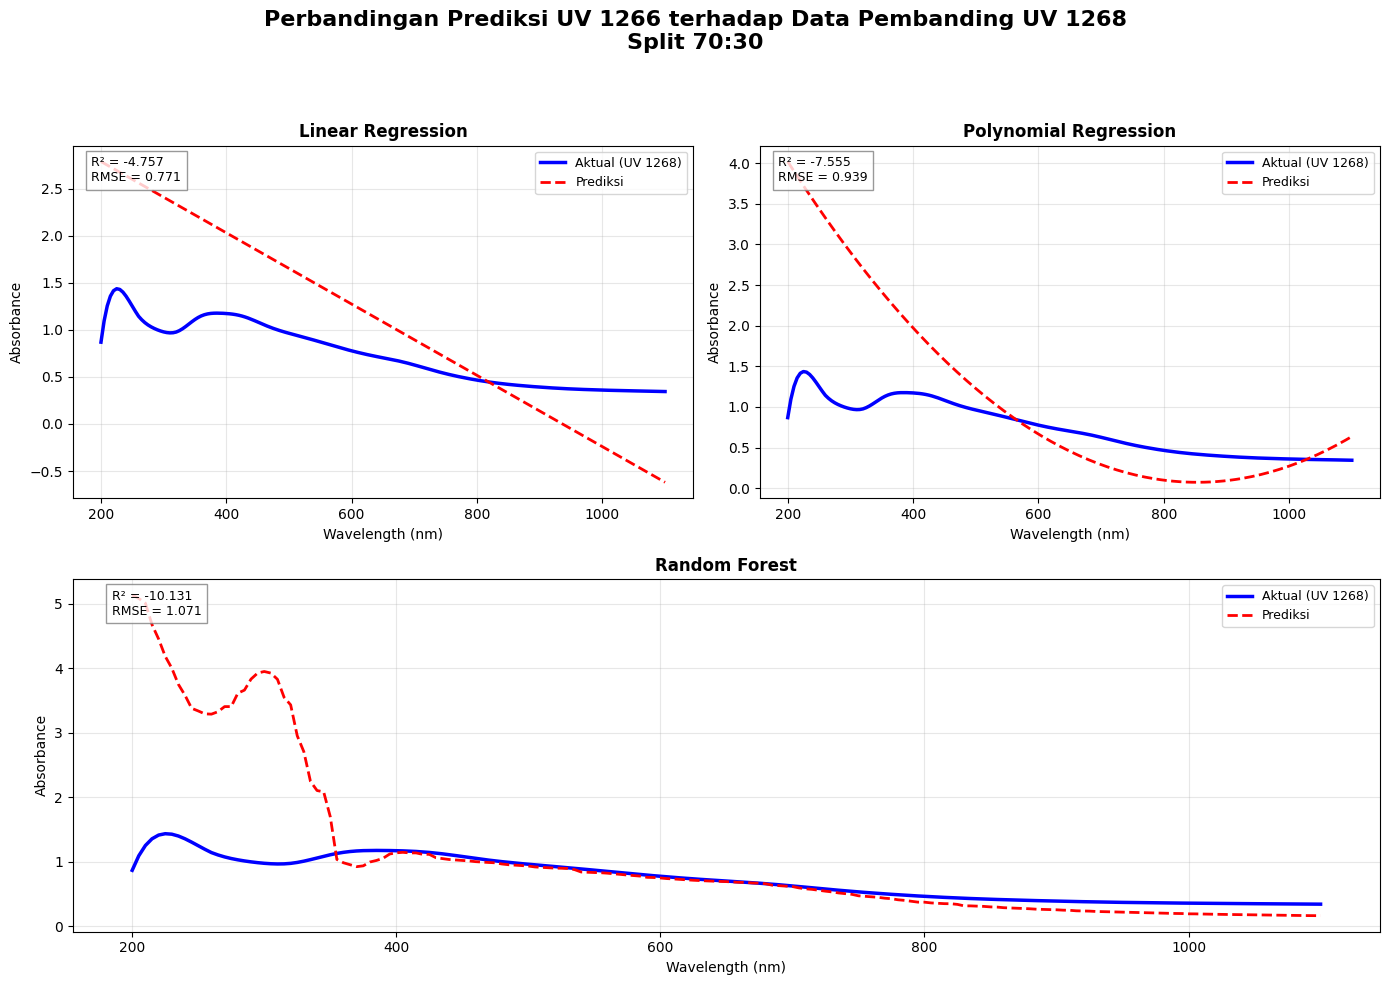

,Scenario,Sample,Comparison,Split,Model,R2,RMSE
0,Scenario 2,UV 1266,UV 1268,70:30,Linear Regression,-4.757306,0.770599
1,Scenario 2,UV 1266,UV 1268,70:30,Polynomial Regression,-7.554536,0.939327
2,Scenario 2,UV 1266,UV 1268,70:30,Random Forest,-10.131044,1.071487




SAMPEL : UV 1266
Shape X : (181, 1)
Shape y : (181,)

TRAIN DATA


,Wavelength,Absorbance
0,525,0.8874
1,535,0.8695
2,355,1.1318
3,260,3.2495
4,405,1.168
...,...,...
139,730,0.5294
140,270,3.3737
141,660,0.6833
142,1095,0.1661



TEST DATA


,Wavelength,Absorbance
0,295,3.9506
1,410,1.162
2,965,0.2112
3,590,0.7658
4,925,0.2352
5,275,3.4888
6,320,3.3315
7,540,0.8603
8,765,0.442
9,790,0.3906



HASIL EVALUASI


,Sample,Split,Model,R2,RMSE
0,UV 1266,80:20,Linear Regression,0.669266,0.668227
1,UV 1266,80:20,Polynomial Regression,0.854393,0.443380
2,UV 1266,80:20,Random Forest,0.996787,0.065862


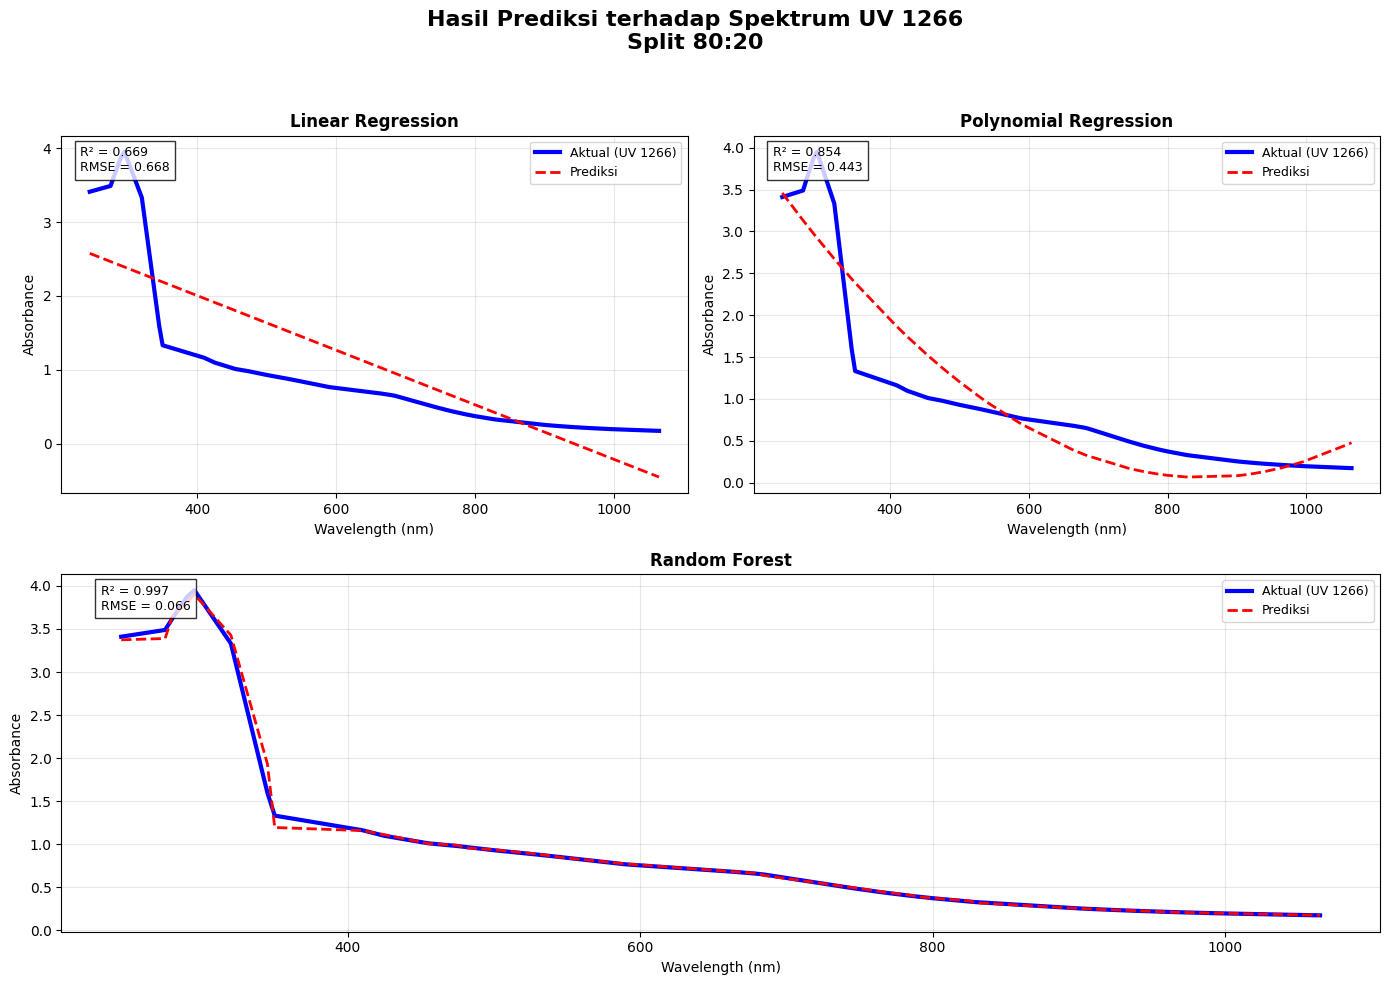

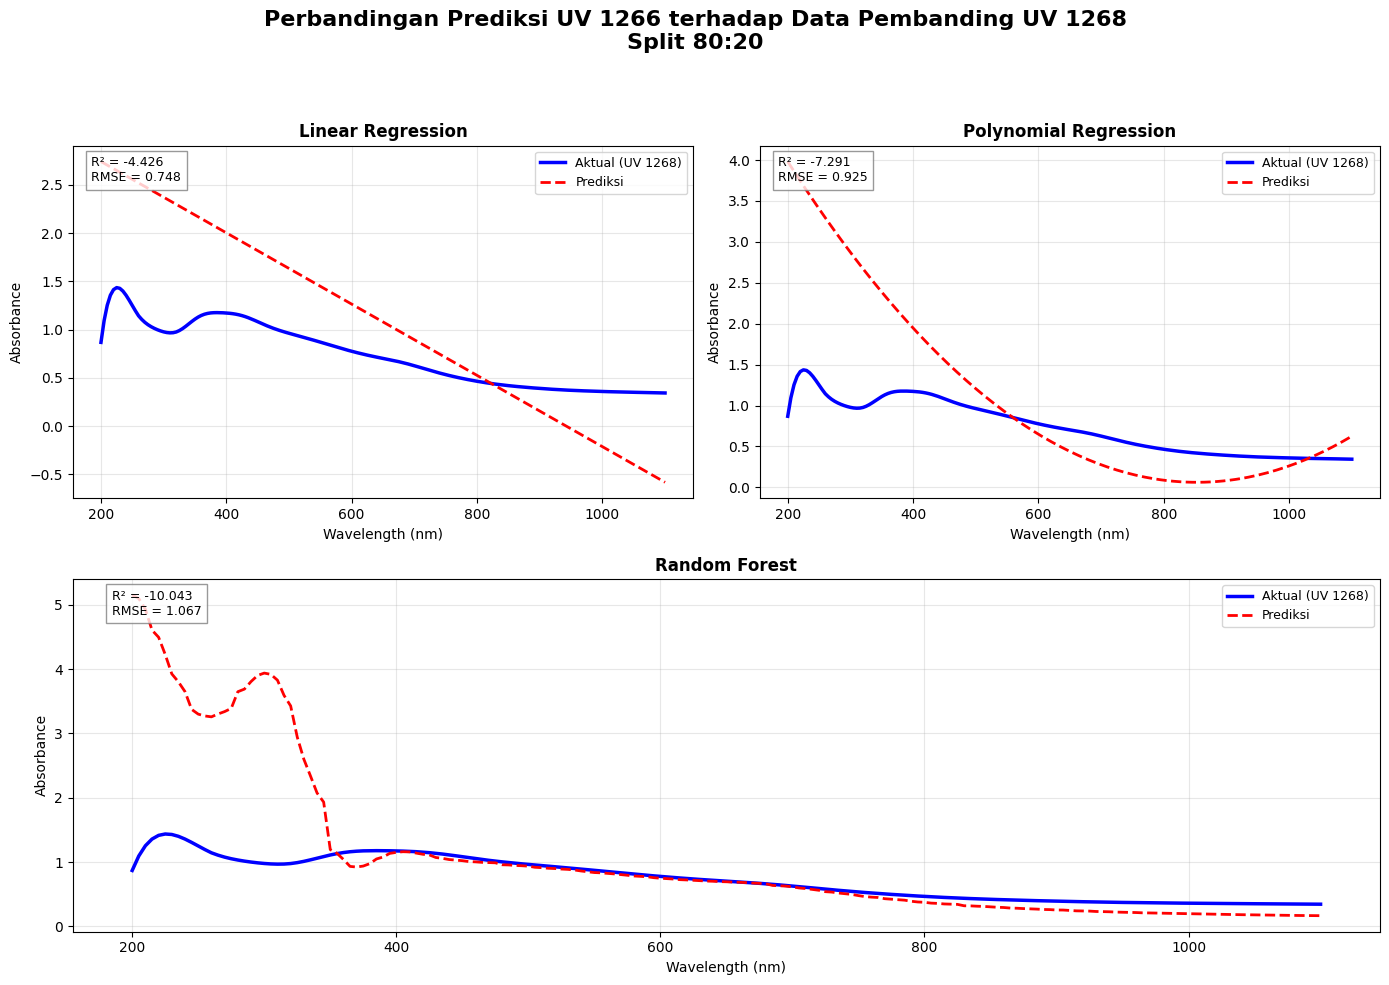

,Scenario,Sample,Comparison,Split,Model,R2,RMSE
0,Scenario 2,UV 1266,UV 1268,80:20,Linear Regression,-4.426129,0.748107
1,Scenario 2,UV 1266,UV 1268,80:20,Polynomial Regression,-7.290917,0.924741
2,Scenario 2,UV 1266,UV 1268,80:20,Random Forest,-10.043128,1.067247




SAMPEL : UV 1266
Shape X : (181, 1)
Shape y : (181,)

TRAIN DATA


,Wavelength,Absorbance
0,480,0.9685
1,685,0.6471
2,800,0.3727
3,915,0.2424
4,350,1.332
...,...,...
157,730,0.5294
158,270,3.3737
159,660,0.6833
160,1095,0.1661



TEST DATA


,Wavelength,Absorbance
0,295,3.9506
1,410,1.162
2,965,0.2112
3,590,0.7658
4,925,0.2352
5,275,3.4888
6,320,3.3315
7,540,0.8603
8,765,0.442
9,790,0.3906



HASIL EVALUASI


,Sample,Split,Model,R2,RMSE
0,UV 1266,90:10,Linear Regression,0.680302,0.710859
1,UV 1266,90:10,Polynomial Regression,0.877780,0.439526
2,UV 1266,90:10,Random Forest,0.998843,0.042772


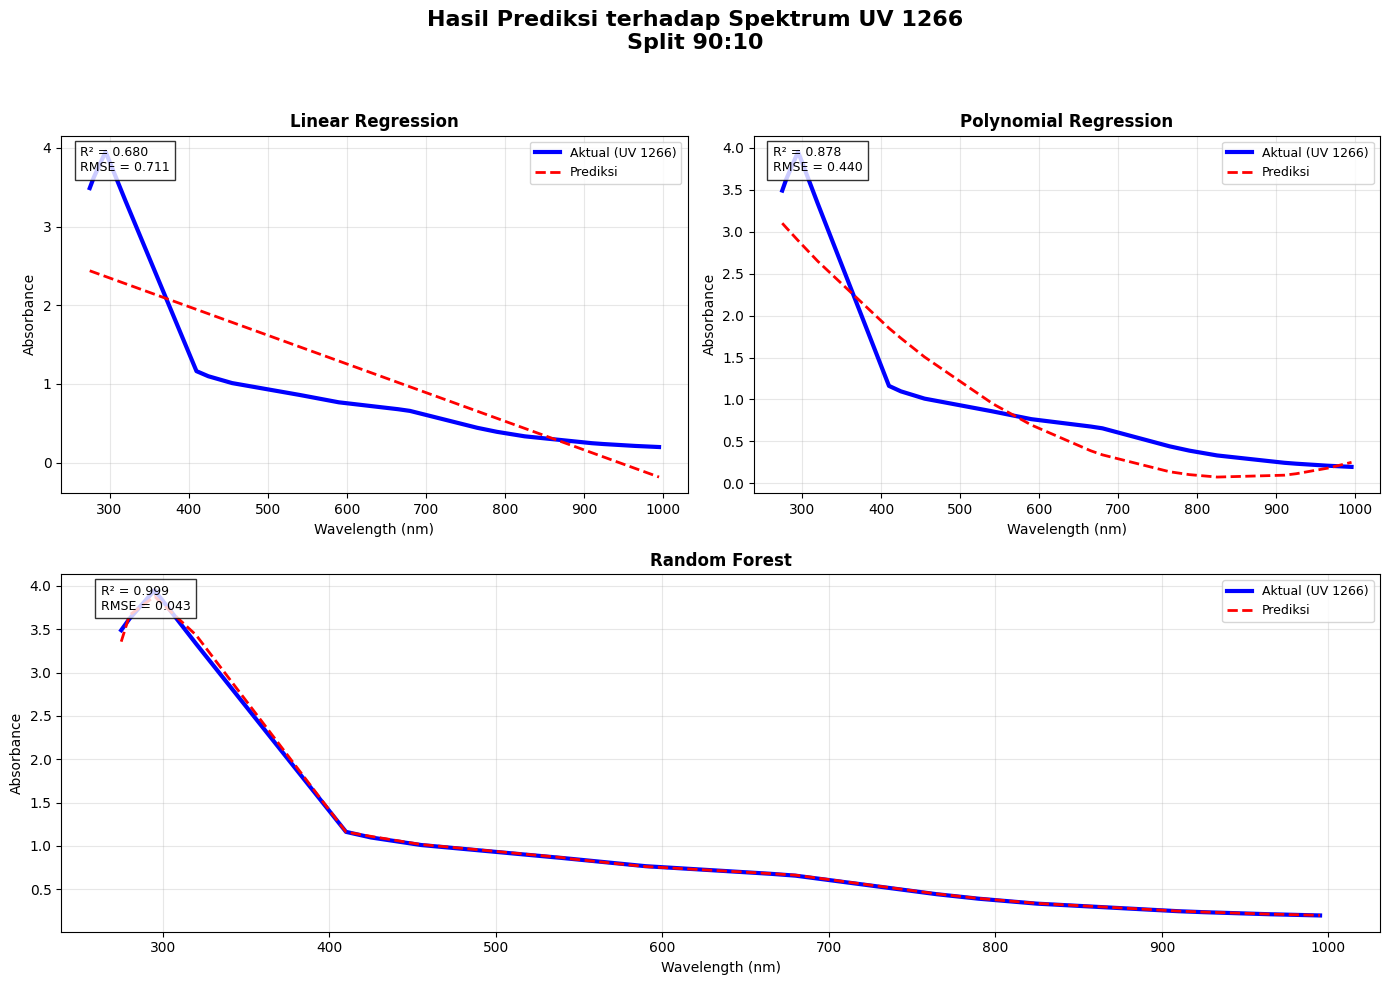

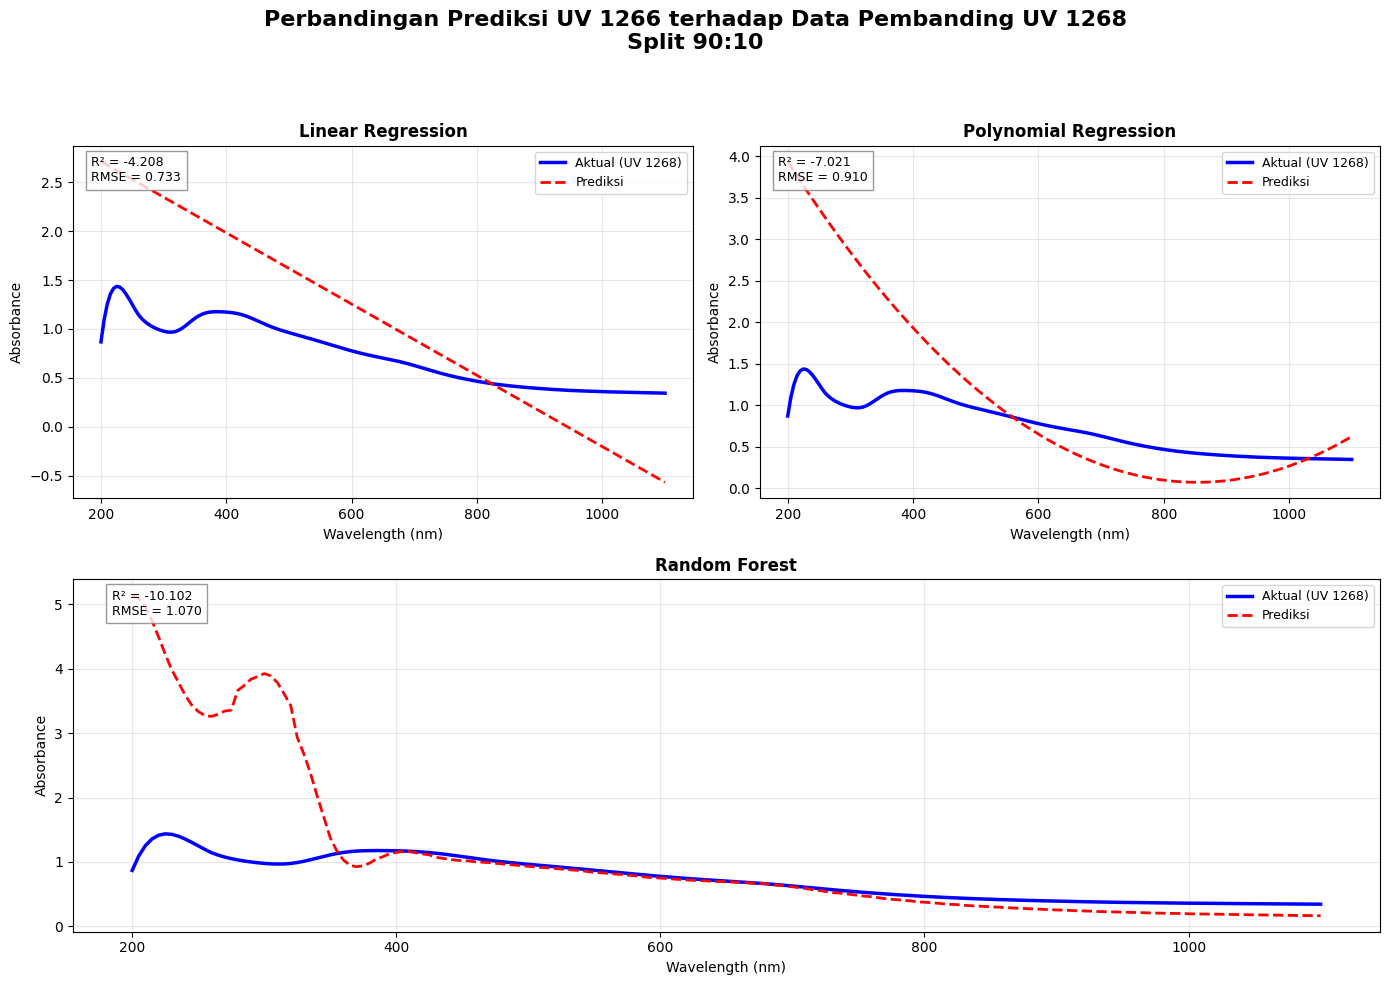

,Scenario,Sample,Comparison,Split,Model,R2,RMSE
0,Scenario 2,UV 1266,UV 1268,90:10,Linear Regression,-4.207999,0.732916
1,Scenario 2,UV 1266,UV 1268,90:10,Polynomial Regression,-7.020714,0.909547
2,Scenario 2,UV 1266,UV 1268,90:10,Random Forest,-10.101552,1.070066




SAMPEL : UV 1267
Shape X : (181, 1)
Shape y : (181,)

TRAIN DATA


,Wavelength,Absorbance
0,760,0.4412
1,220,1.2108
2,360,1.067
3,705,0.5976
4,840,0.2988
...,...,...
103,730,0.5205
104,270,1.1977
105,660,0.6942
106,1095,0.1378



TEST DATA


,Wavelength,Absorbance
0,295,1.2434
1,410,1.0881
2,965,0.1896
3,590,0.7697
4,925,0.216
...,...,...
68,575,0.796
69,930,0.2122
70,255,1.0994
71,230,1.1279



HASIL EVALUASI


,Sample,Split,Model,R2,RMSE
0,UV 1267,60:40,Linear Regression,0.967204,0.069083
1,UV 1267,60:40,Polynomial Regression,0.966597,0.069720
2,UV 1267,60:40,Random Forest,0.998948,0.012370


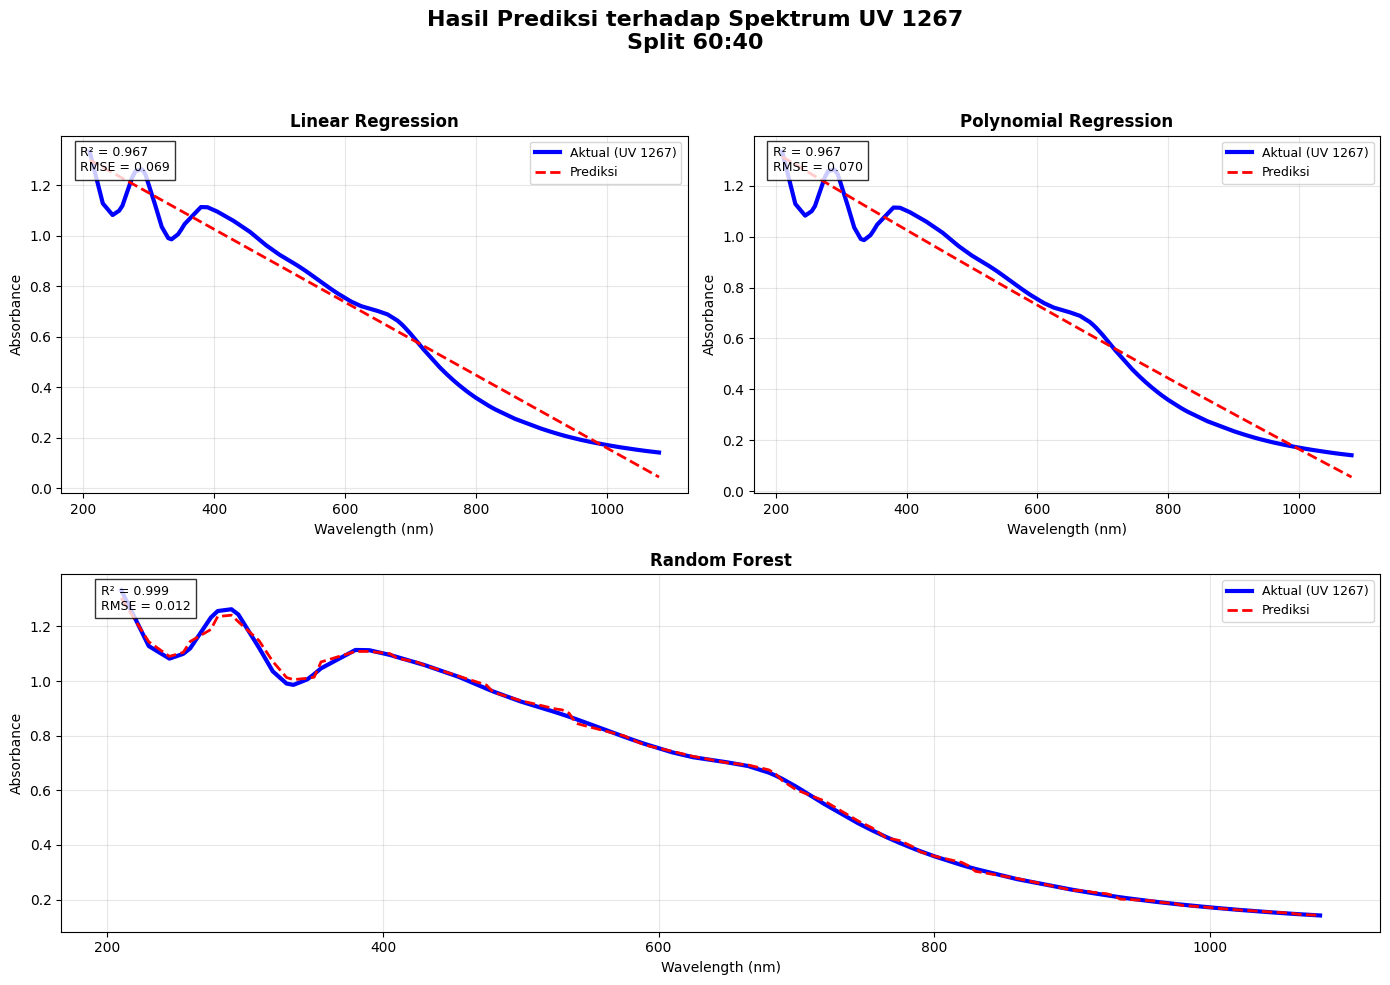

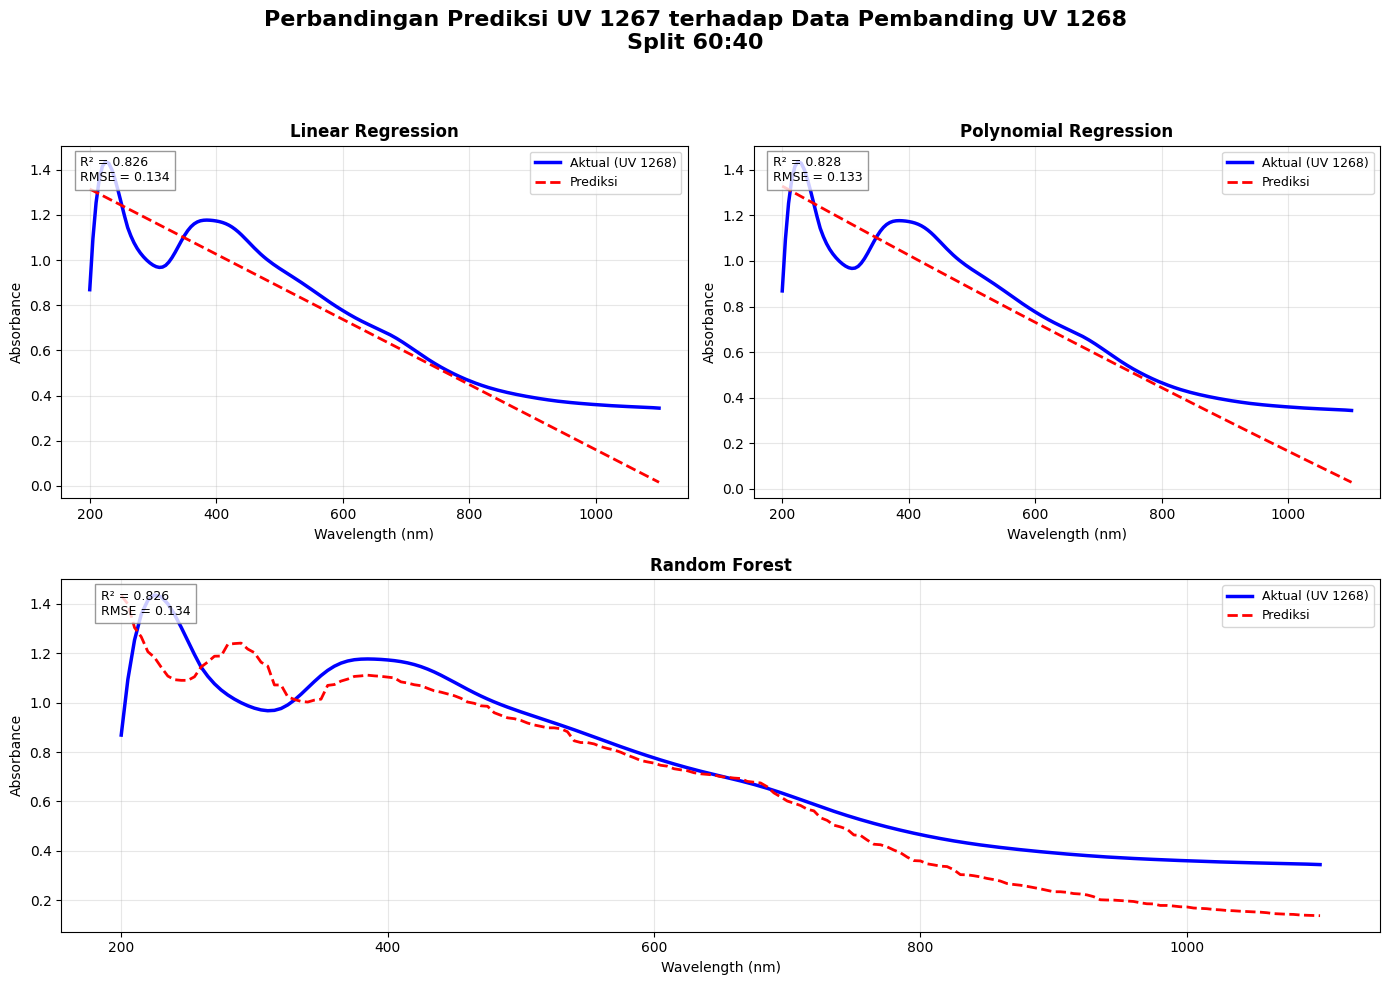

,Scenario,Sample,Comparison,Split,Model,R2,RMSE
0,Scenario 2,UV 1267,UV 1268,60:40,Linear Regression,0.825754,0.134060
1,Scenario 2,UV 1267,UV 1268,60:40,Polynomial Regression,0.827810,0.133267
2,Scenario 2,UV 1267,UV 1268,60:40,Random Forest,0.826273,0.133861




SAMPEL : UV 1267
Shape X : (181, 1)
Shape y : (181,)

TRAIN DATA


,Wavelength,Absorbance
0,625,0.7211
1,960,0.1924
2,610,0.7388
3,935,0.2086
4,330,0.9906
...,...,...
121,730,0.5205
122,270,1.1977
123,660,0.6942
124,1095,0.1378



TEST DATA


,Wavelength,Absorbance
0,295,1.2434
1,410,1.0881
2,965,0.1896
3,590,0.7697
4,925,0.216
5,275,1.2319
6,320,1.0354
7,540,0.8607
8,765,0.4295
9,790,0.377



HASIL EVALUASI


,Sample,Split,Model,R2,RMSE
0,UV 1267,70:30,Linear Regression,0.968946,0.068795
1,UV 1267,70:30,Polynomial Regression,0.968980,0.068757
2,UV 1267,70:30,Random Forest,0.998960,0.012589


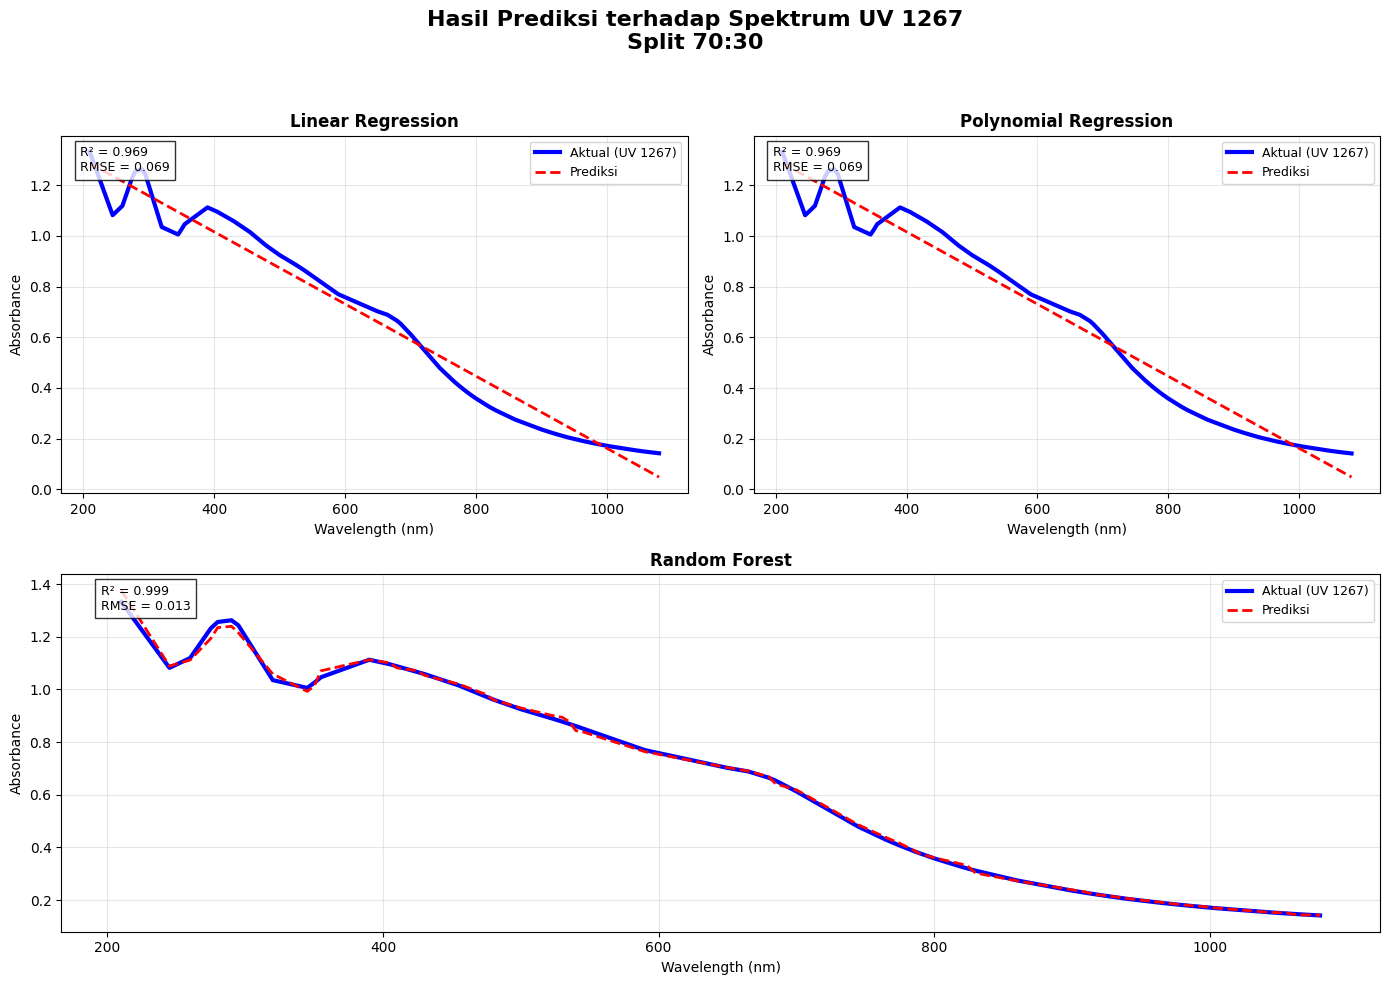

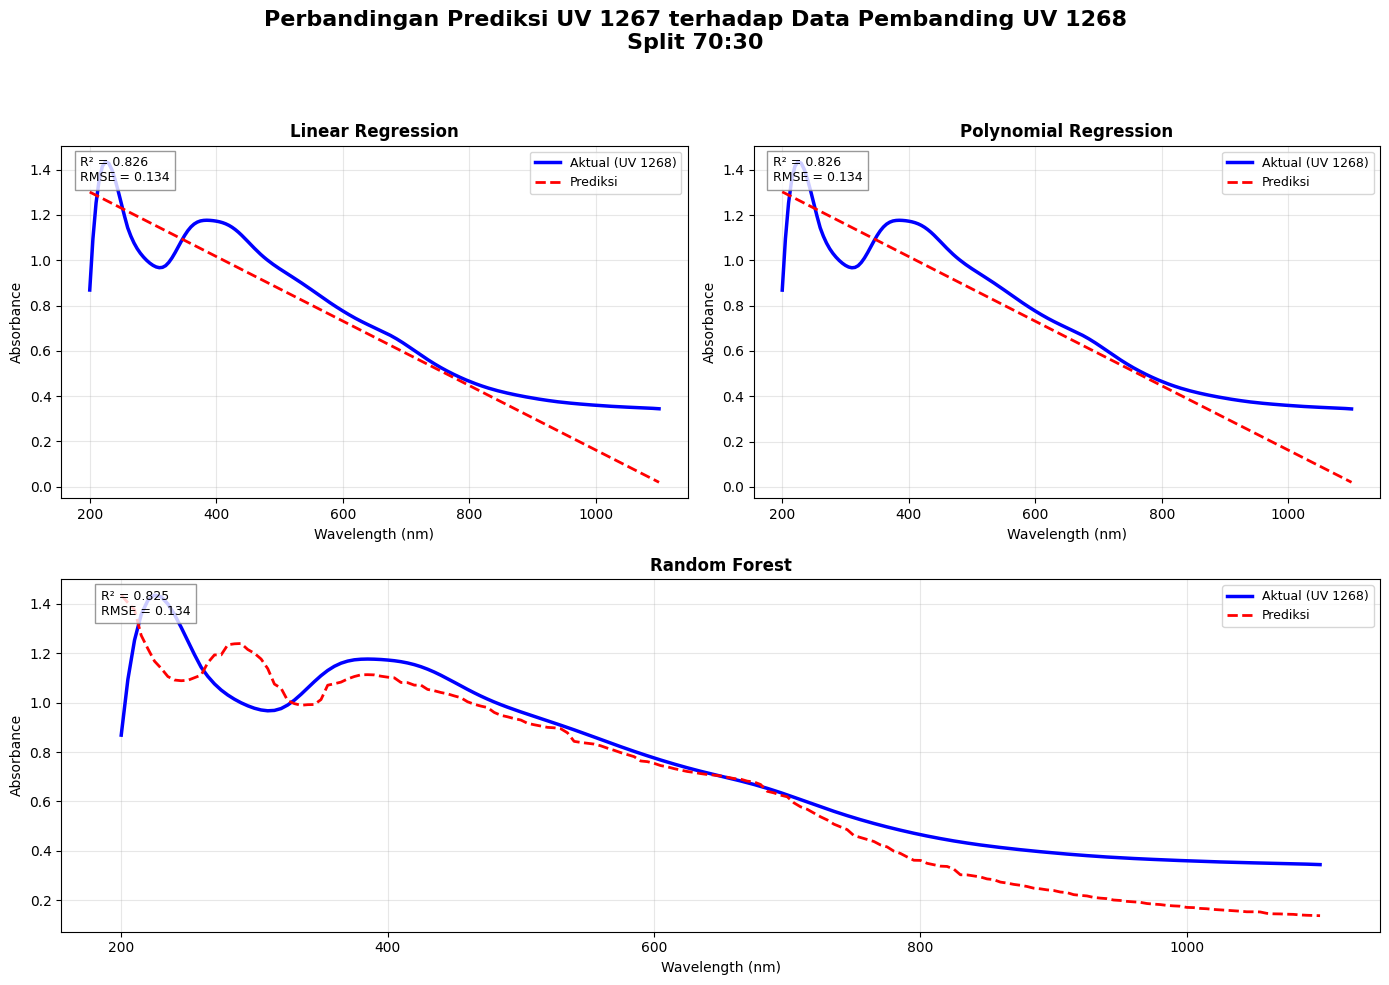

,Scenario,Sample,Comparison,Split,Model,R2,RMSE
0,Scenario 2,UV 1267,UV 1268,70:30,Linear Regression,0.825562,0.134134
1,Scenario 2,UV 1267,UV 1268,70:30,Polynomial Regression,0.825743,0.134065
2,Scenario 2,UV 1267,UV 1268,70:30,Random Forest,0.824784,0.134433




SAMPEL : UV 1267
Shape X : (181, 1)
Shape y : (181,)

TRAIN DATA


,Wavelength,Absorbance
0,525,0.8861
1,535,0.8694
2,355,1.0464
3,260,1.1193
4,405,1.0955
...,...,...
139,730,0.5205
140,270,1.1977
141,660,0.6942
142,1095,0.1378



TEST DATA


,Wavelength,Absorbance
0,295,1.2434
1,410,1.0881
2,965,0.1896
3,590,0.7697
4,925,0.216
5,275,1.2319
6,320,1.0354
7,540,0.8607
8,765,0.4295
9,790,0.377



HASIL EVALUASI


,Sample,Split,Model,R2,RMSE
0,UV 1267,80:20,Linear Regression,0.965782,0.070226
1,UV 1267,80:20,Polynomial Regression,0.965834,0.070173
2,UV 1267,80:20,Random Forest,0.999131,0.011188


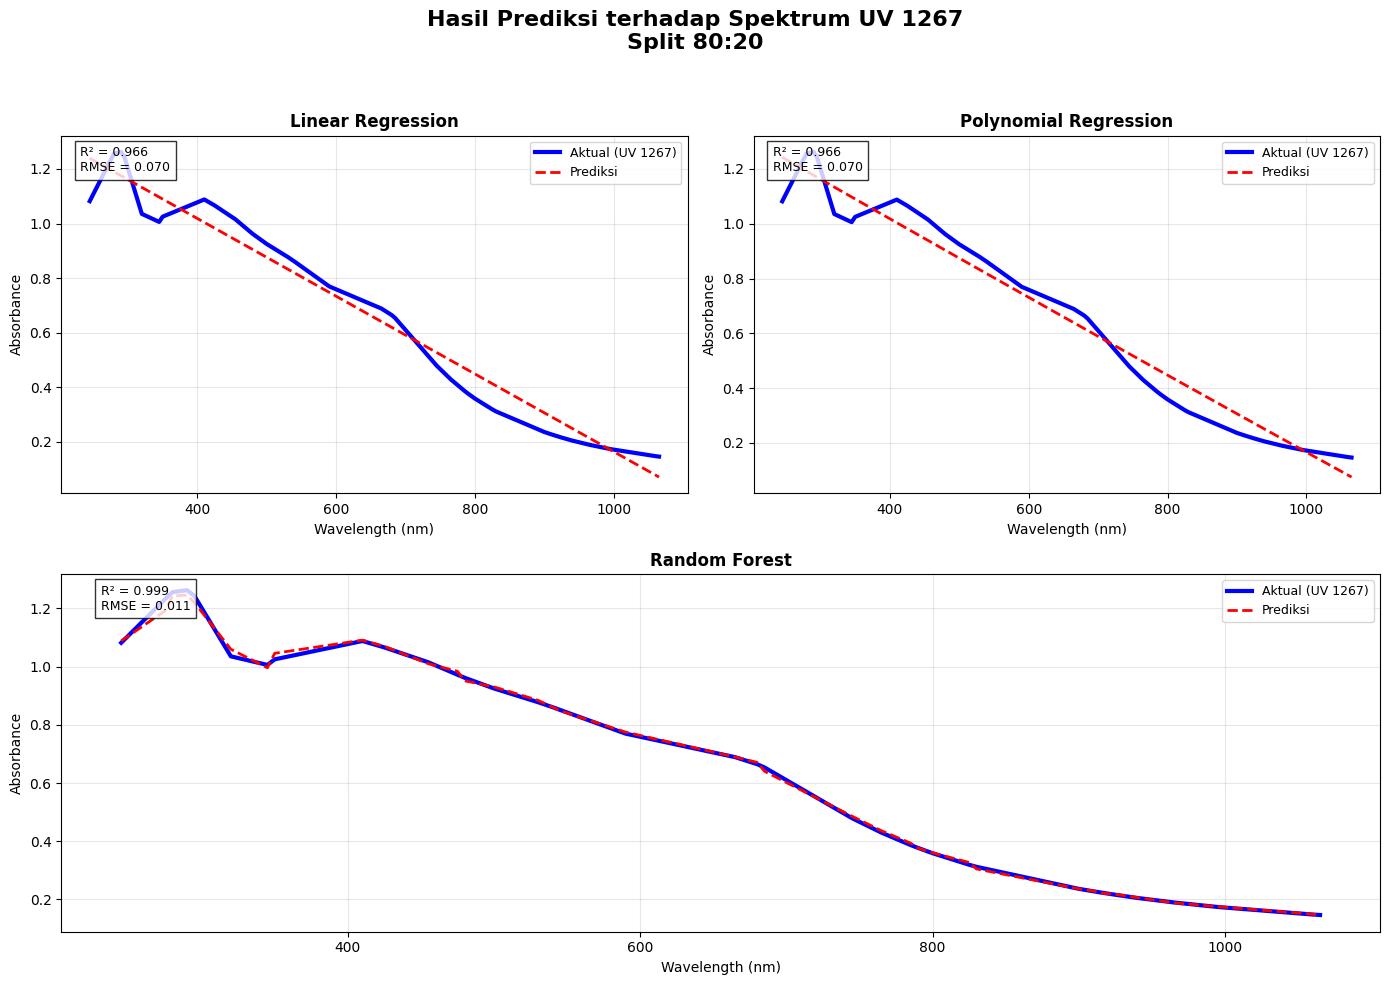

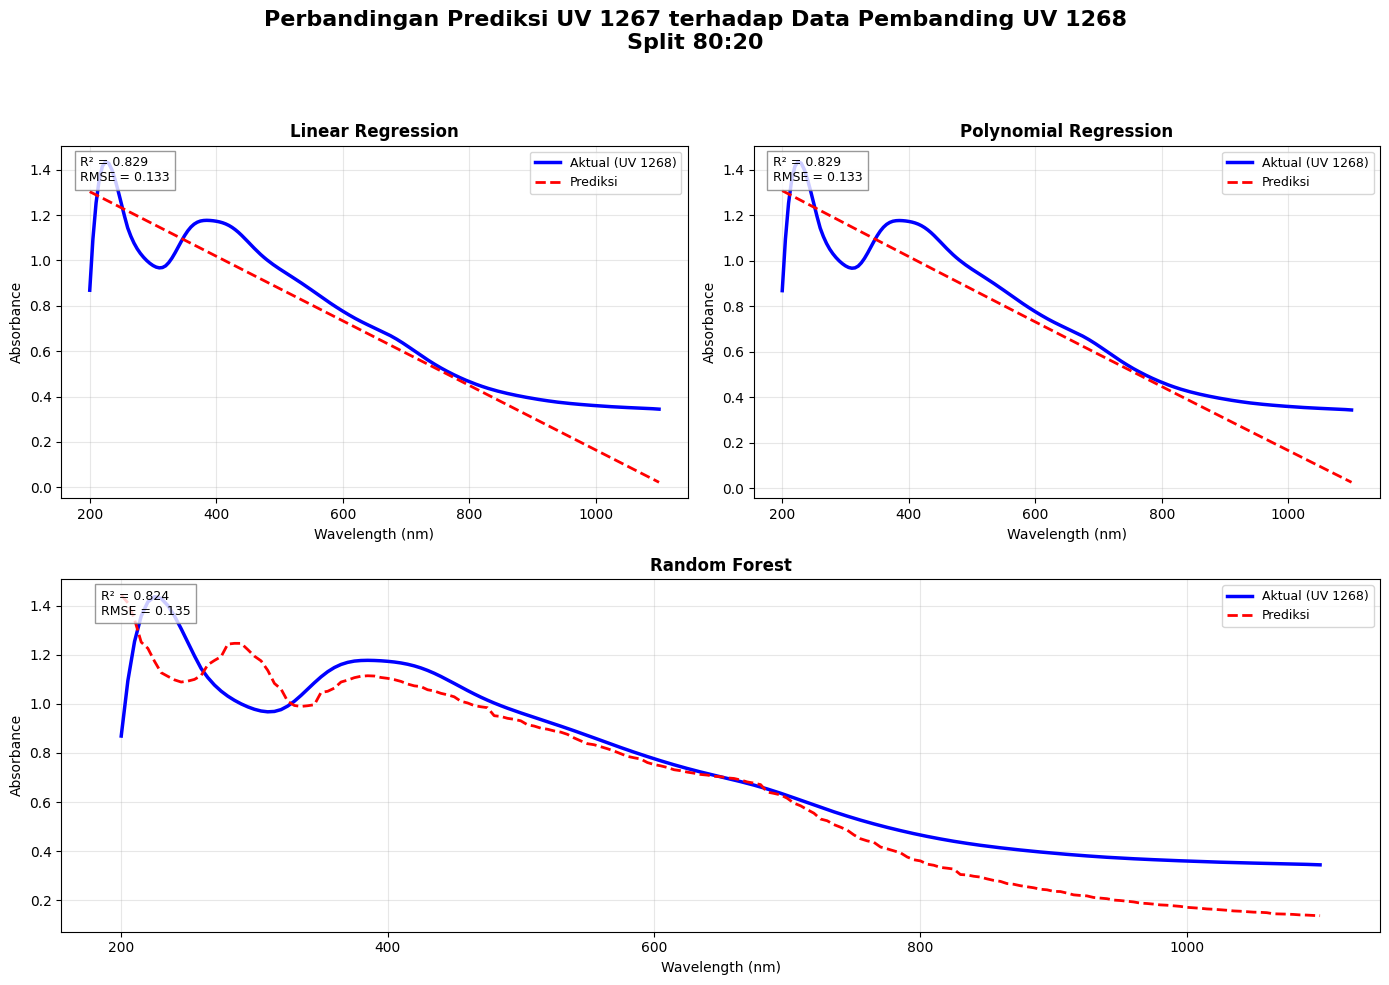

,Scenario,Sample,Comparison,Split,Model,R2,RMSE
0,Scenario 2,UV 1267,UV 1268,80:20,Linear Regression,0.828566,0.132974
1,Scenario 2,UV 1267,UV 1268,80:20,Polynomial Regression,0.829306,0.132687
2,Scenario 2,UV 1267,UV 1268,80:20,Random Forest,0.824143,0.134679




SAMPEL : UV 1267
Shape X : (181, 1)
Shape y : (181,)

TRAIN DATA


,Wavelength,Absorbance
0,480,0.9616
1,685,0.6536
2,800,0.3587
3,915,0.2238
4,350,1.0251
...,...,...
157,730,0.5205
158,270,1.1977
159,660,0.6942
160,1095,0.1378



TEST DATA


,Wavelength,Absorbance
0,295,1.2434
1,410,1.0881
2,965,0.1896
3,590,0.7697
4,925,0.216
5,275,1.2319
6,320,1.0354
7,540,0.8607
8,765,0.4295
9,790,0.377



HASIL EVALUASI


,Sample,Split,Model,R2,RMSE
0,UV 1267,90:10,Linear Regression,0.971481,0.064214
1,UV 1267,90:10,Polynomial Regression,0.971498,0.064195
2,UV 1267,90:10,Random Forest,0.998755,0.013418


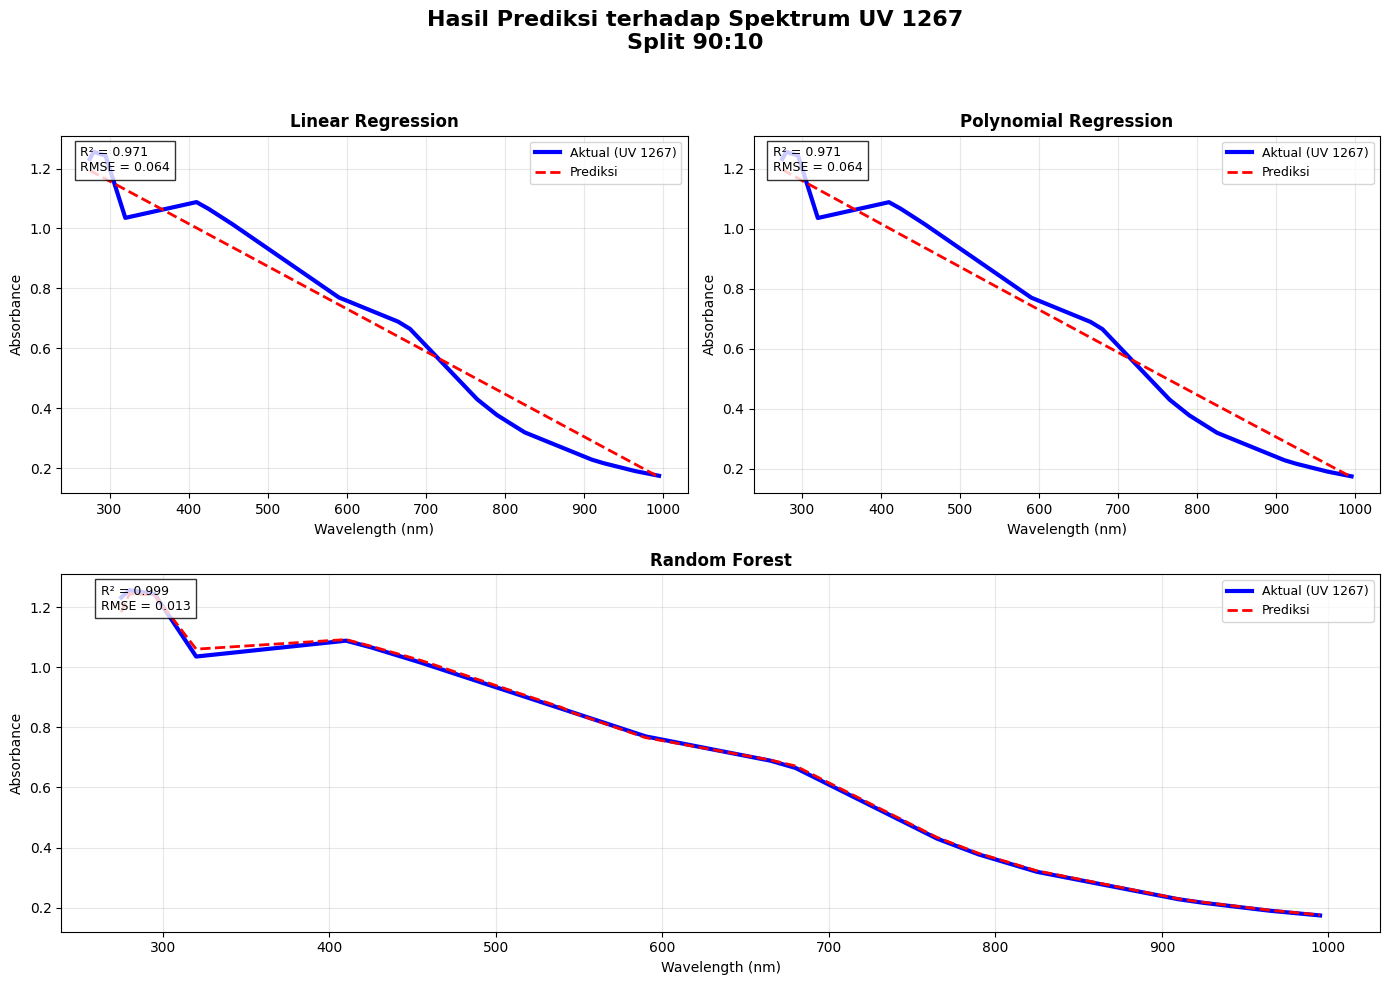

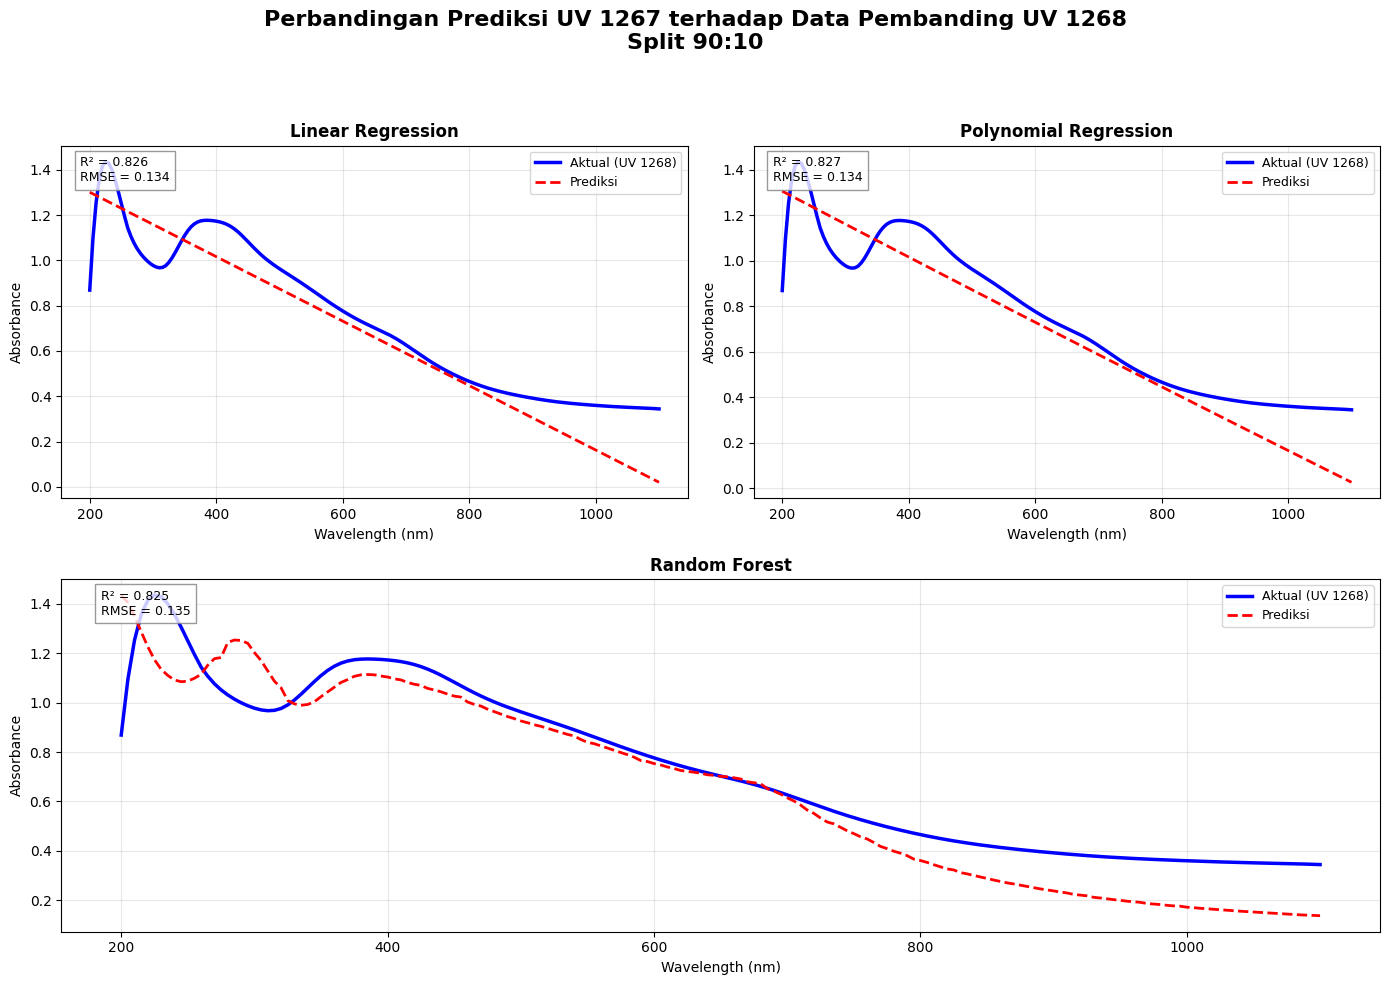

,Scenario,Sample,Comparison,Split,Model,R2,RMSE
0,Scenario 2,UV 1267,UV 1268,90:10,Linear Regression,0.826207,0.133886
1,Scenario 2,UV 1267,UV 1268,90:10,Polynomial Regression,0.827009,0.133577
2,Scenario 2,UV 1267,UV 1268,90:10,Random Forest,0.824598,0.134504


In [40]:
hasil_s2 = []

scenario2_samples = [
    'UV 1264',
    'UV 1265',
    'UV 1266',
    'UV 1267'
]

comparison = sample_data['UV 1268']

for sample in scenario2_samples:

    data = sample_data[sample]

    for ts in split_list:

        # =============================
        # Training
        # =============================

        hasil, models, scaler = run_sample(
            sample_name=sample,
            transformed_data=data,
            test_size=ts,
            show_plot=False
        )

        # =============================
        # Data Pembanding
        # =============================

        X_compare = comparison[['Wavelength']].values

        X_compare_scaled = scaler.transform(X_compare)

        predictions = {}

        comparison_results = []

        # =============================
        # Prediksi semua model
        # =============================

        for model_name, model in models.items():

            pred = model.predict(X_compare_scaled)

            predictions[model_name] = pred

            r2 = r2_score(
                comparison['Absorbance'],
                pred
            )

            rmse = np.sqrt(
                mean_squared_error(
                    comparison['Absorbance'],
                    pred
                )
            )

            comparison_results.append({

                "Scenario": "Scenario 2",

                "Sample": sample,

                "Comparison": "UV 1268",

                "Split": f"{int((1-ts)*100)}:{int(ts*100)}",

                "Model": model_name,

                "R2": r2,

                "RMSE": rmse

            })

        # =============================
        # Grafik 1x3
        # =============================

        evaluation_df = pd.DataFrame(comparison_results)

        plot_comparison_grid(
            comparison_df=comparison,
            predictions=predictions,
            evaluation_df=evaluation_df,
            sample_name=sample,
            comparison_name="UV 1268",
            split_label=f"{int((1-ts)*100)}:{int(ts*100)}"
        )

        display(evaluation_df)

        hasil_s2.append(evaluation_df)

In [41]:
hasil_s2 = pd.concat(
    hasil_s2,
    ignore_index=True
)

print("\nHASIL SCENARIO 2")

display(hasil_s2)


HASIL SCENARIO 2


,Scenario,Sample,Comparison,Split,Model,R2,RMSE
0,Scenario 2,UV 1264,UV 1268,60:40,Linear Regression,-1.066267,0.461649
1,Scenario 2,UV 1264,UV 1268,60:40,Polynomial Regression,-2.756468,0.622456
2,Scenario 2,UV 1264,UV 1268,60:40,Random Forest,-3.754618,0.700288
3,Scenario 2,UV 1264,UV 1268,70:30,Linear Regression,-0.867651,0.438901
4,Scenario 2,UV 1264,UV 1268,70:30,Polynomial Regression,-2.275045,0.581202
5,Scenario 2,UV 1264,UV 1268,70:30,Random Forest,-3.823421,0.705336
6,Scenario 2,UV 1264,UV 1268,80:20,Linear Regression,-0.860434,0.438052
7,Scenario 2,UV 1264,UV 1268,80:20,Polynomial Regression,-2.353332,0.588108
8,Scenario 2,UV 1264,UV 1268,80:20,Random Forest,-3.795965,0.703326
9,Scenario 2,UV 1264,UV 1268,90:10,Linear Regression,-0.722830,0.421541


## Skenario 1
Train:
UV 1264, 1265, 1266
Test/Pembanding:
UV 1267

In [ ]:
hasil_s1 = []

scenario1_samples = [

    'UV 1264',
    'UV 1265',
    'UV 1266'

]

for sample in scenario1_samples:

    data = sample_data[sample]

    for ts in split_list:

        hasil, best_model, best_pred = run_sample(
            sample_name=sample,
            transformed_data=data,
            test_size=ts,
            show_plot=True
        )

        hasil.insert(
            0,
            "Scenario",
            "Scenario 1"
        )

        hasil_s1.append(
            hasil
        )
        
best_prediction_s1 = {}

best_prediction_s1[sample] = {

    'model': best_model,

    'prediction': best_pred

}

In [ ]:
hasil_s2_df = pd.concat(

    hasil_s2,

    ignore_index=True

)

print(
    "\nHASIL SKENARIO 2"
)

display(
    hasil_s2_df
)


In [ ]:
uv1267 = sample_data[
    'UV 1267'
]['Absorbance'].values

plt.figure(figsize=(12,6))

plt.plot(
    wavelength,
    uv1267,
    linewidth=4,
    label='UV 1267 Aktual'
)

for sample in best_prediction_s1:

    pred = best_prediction_s1[
        sample
    ]['prediction']

    model = best_prediction_s1[
        sample
    ]['model']

    plt.plot(
        wavelength,
        pred,
        '--',
        label=f'{sample} ({model})'
    )

plt.xlabel('Wavelength (nm)')
plt.ylabel('Absorbance')

plt.title(
    'Skenario 1: Model Terbaik vs UV1267'
)

plt.legend()
plt.grid(True)
plt.show()

In [ ]:
comparison_s1 = []

for sample in best_prediction_s1:

    pred = best_prediction_s1[
        sample
    ]['prediction']

    rmse = np.sqrt(

        mean_squared_error(

            uv1267,

            pred

        )

    )

    comparison_s1.append([

        sample,

        best_prediction_s1[
            sample
        ]['model'],

        rmse

    ])

comparison_s1 = pd.DataFrame(

    comparison_s1,

    columns=[

        'Sample',

        'Best Model',

        'RMSE vs UV1267'

    ]

)

display(
    comparison_s1.sort_values(
        'RMSE vs UV1267'
    )
)

## Skenario 2
Train:
UV 1264, 1265, 1266, 1267
Test:
UV 1268

In [ ]:
hasil_s2 = []

scenario2_samples = [

    'UV 1264',
    'UV 1265',
    'UV 1266', 
    'UV 1267'

]

for sample in scenario2_samples:

    data = sample_data[sample]

    for ts in split_list:

        hasil, best_model, best_pred = run_sample(
            sample_name=sample,
            transformed_data=data,
            test_size=ts,
            show_plot=True
        )

        hasil.insert(
            0,
            "Scenario",
            "Scenario 2"
        )

        hasil_s2.append(
            hasil
        )
        
best_prediction_s2 = {}

best_prediction_s2[sample] = {

    'model': best_model,

    'prediction': best_pred

}

In [ ]:
hasil_s2_df = pd.concat(

    hasil_s2,

    ignore_index=True

)

display(
    hasil_s2_df
)

In [ ]:
uv1268 = sample_data[
    'UV 1268'
]['Absorbance'].values

plt.figure(figsize=(12,6))

plt.plot(
    wavelength,
    uv1268,
    linewidth=4,
    label='UV 1268 Aktual'
)

for sample in best_prediction_s2:

    pred = best_prediction_s2[
        sample
    ]['prediction']

    model = best_prediction_s2[
        sample
    ]['model']

    plt.plot(
        wavelength,
        pred,
        '--',
        label=f'{sample} ({model})'
    )

plt.xlabel('Wavelength (nm)')
plt.ylabel('Absorbance')

plt.title(
    'Skenario 2: Model Terbaik vs UV1268'
)

plt.legend()
plt.grid(True)
plt.show()

In [ ]:
comparison_s2 = []

for sample in best_prediction_s2:

    pred = best_prediction_s2[
        sample
    ]['prediction']

    rmse = np.sqrt(

        mean_squared_error(

            uv1268,

            pred

        )

    )

    comparison_s2.append([

        sample,

        best_prediction_s2[
            sample
        ]['model'],

        rmse

    ])

comparison_s2 = pd.DataFrame(

    comparison_s2,

    columns=[

        'Sample',

        'Best Model',

        'RMSE vs UV1268'

    ]

)

display(
    comparison_s2.sort_values(
        'RMSE vs UV1268'
    )
)

In [ ]:
hasil_all = pd.concat(

    [

        hasil_s1_df,

        hasil_s2_df

    ],

    ignore_index=True

)

print(
    "\nSEMUA HASIL"
)

display(
    hasil_all
)

hasil_all.to_excel(

    "hasil_model_uvvis.xlsx",

    index=False

)

print(
    "File berhasil disimpan"
)

## Skenario 1: Perbandingan Pola Spektrum Antar Sampel

In [ ]:
plt.figure(figsize=(12,6))

uv1267 = sample_data[
    'UV 1267'
]['Absorbance']

plt.plot(

    wavelength,

    uv1267,

    linewidth=3,

    label='UV 1267'

)

for sample in [

    'UV 1264',

    'UV 1265',

    'UV 1266'

]:

    plt.plot(

        wavelength,

        sample_data[sample][
            'Absorbance'
        ],

        label=sample

    )

plt.xlabel(
    'Wavelength (nm)'
)

plt.ylabel(
    'Absorbance'
)

plt.title(
    'Skenario 1: Perbandingan Train dengan UV1267'
)

plt.legend()

plt.grid(True)

plt.show()

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import numpy as np

best_row = comparison_s1.loc[
    comparison_s1['RMSE vs UV1267'].idxmin()
]

best_sample = best_row['Sample']
best_model_name = best_row['Best Model']

print("Sample Terbaik :", best_sample)
print("Model Terbaik  :", best_model_name)

train_data = sample_data[
    best_sample
]

X_train = train_data[
    ['Wavelength']
]

y_train = train_data[
    'Absorbance'
]

uv1267 = sample_data[
    'UV 1267'
]

X_uv1267 = uv1267[
    ['Wavelength']
]

y_uv1267 = uv1267[
    'Absorbance'
]

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_uv1267_scaled = scaler.transform(
    X_uv1267
)

if best_model_name == 'Linear Regression':

    model = LinearRegression()

elif best_model_name == 'Polynomial Regression':

    model = Pipeline([

        (
            'poly',
            PolynomialFeatures(
                degree=2
            )
        ),

        (
            'linear',
            LinearRegression()
        )

    ])

else:

    model = RandomForestRegressor(

        n_estimators=100,

        random_state=42

    )

    model.fit(

    X_train_scaled,

    y_train

)

pred_uv1267 = model.predict(
    X_uv1267_scaled
)

rmse_uv1267 = np.sqrt(

    mean_squared_error(

        y_uv1267,

        pred_uv1267

    )

)

print(
    f"RMSE terhadap UV1267 = {rmse_uv1267:.6f}"
)

plt.figure(figsize=(12,6))

plt.plot(

    wavelength,

    y_uv1267,

    linewidth=3,

    label='UV1267 Aktual'

)

plt.plot(

    wavelength,

    pred_uv1267,

    '--',

    linewidth=2,

    label='Prediksi Model'

)

plt.xlabel(
    'Wavelength (nm)'
)

plt.ylabel(
    'Absorbance'
)

plt.title(
    f'Perbandingan Prediksi {best_model_name} terhadap UV1267'
)

plt.legend()

plt.grid(True)

plt.show()

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

import pandas as pd
import numpy as np

results_uv1267 = []

# data pembanding

uv1267 = sample_data['UV 1267']

X_compare = uv1267[['Wavelength']]
y_compare = uv1267['Absorbance']

# sampel training

samples = [

    'UV 1264',
    'UV 1265',
    'UV 1266'

]

models = {

    'Linear Regression':
        LinearRegression(),

    'Polynomial Regression':
        Pipeline([

            (
                'poly',
                PolynomialFeatures(
                    degree=2
                )
            ),

            (
                'linear',
                LinearRegression()
            )

        ]),

    'Random Forest':
        RandomForestRegressor(

            n_estimators=100,

            random_state=42

        )

}

for sample in samples:

    train_data = sample_data[
        sample
    ]

    X_train = train_data[
        ['Wavelength']
    ]

    y_train = train_data[
        'Absorbance'
    ]

    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(
        X_train
    )

    X_compare_scaled = scaler.transform(
        X_compare
    )

    for model_name, model in models.items():

        model.fit(

            X_train_scaled,

            y_train

        )

        pred = model.predict(
            X_compare_scaled
        )

        rmse = np.sqrt(

            mean_squared_error(

                y_compare,

                pred

            )

        )

        results_uv1267.append({

            'Sample':
                sample,

            'Model':
                model_name,

            'RMSE vs UV1267':
                rmse

        })

comparison_uv1267 = pd.DataFrame(
    results_uv1267
)

comparison_uv1267 = comparison_uv1267.sort_values(
    by='RMSE vs UV1267'
)

comparison_uv1267

In [ ]:
best_uv1267 = comparison_uv1267.iloc[0]

print("=== MODEL TERBAIK TERHADAP UV1267 ===")
print(f"Sample : {best_uv1267['Sample']}")
print(f"Model  : {best_uv1267['Model']}")
print(f"RMSE   : {best_uv1267['RMSE vs UV1267']:.6f}")

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.bar(

    comparison_uv1267['Sample']
    + " - "
    + comparison_uv1267['Model'],

    comparison_uv1267['RMSE vs UV1267']

)

plt.xticks(
    rotation=45,
    ha='right'
)

plt.ylabel(
    'RMSE'
)

plt.title(
    'Perbandingan RMSE terhadap UV1267'
)

plt.tight_layout()

plt.show()

## Testing atau Perbandingan Skenario 2 dengan UV 1268

In [ ]:
plt.figure(figsize=(12,6))

uv1268 = sample_data[
    'UV 1268'
]['Absorbance']

plt.plot(

    wavelength,

    uv1268,

    linewidth=3,

    label='UV 1268'

)

for sample in [

    'UV 1264',

    'UV 1265',

    'UV 1266',

    'UV 1267'

]:

    plt.plot(

        wavelength,

        sample_data[sample][
            'Absorbance'
        ],

        label=sample

    )

plt.xlabel(
    'Wavelength (nm)'
)

plt.ylabel(
    'Absorbance'
)

plt.title(
    'Skenario 2: Perbandingan Train dengan UV1268'
)

plt.legend()

plt.grid(True)

plt.show()

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import numpy as np

best_row = comparison_s2.loc[
    comparison_s2['RMSE vs UV1268'].idxmin()
]

best_sample = best_row['Sample']
best_model_name = best_row['Best Model']

print("Sample Terbaik :", best_sample)
print("Model Terbaik  :", best_model_name)

train_data = sample_data[
    best_sample
]

X_train = train_data[
    ['Wavelength']
]

y_train = train_data[
    'Absorbance'
]

uv1268 = sample_data[
    'UV 1268'
]

X_uv1268 = uv1268[
    ['Wavelength']
]

y_uv1268 = uv1268[
    'Absorbance'
]

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_uv1268_scaled = scaler.transform(
    X_uv1268
)

if best_model_name == 'Linear Regression':

    model = LinearRegression()

elif best_model_name == 'Polynomial Regression':

    model = Pipeline([

        (
            'poly',
            PolynomialFeatures(
                degree=2
            )
        ),

        (
            'linear',
            LinearRegression()
        )

    ])

else:

    model = RandomForestRegressor(

        n_estimators=100,

        random_state=42

    )

    model.fit(

    X_train_scaled,

    y_train

)

pred_uv1268 = model.predict(
    X_uv1268_scaled
)

rmse_uv1268 = np.sqrt(

    mean_squared_error(

        y_uv1268,

        pred_uv1268

    )

)

print(
    f"RMSE terhadap UV1268 = {rmse_uv1268:.6f}"
)

plt.figure(figsize=(12,6))

plt.plot(

    wavelength,

    y_uv1268,

    linewidth=3,

    label='UV1268 Aktual'

)

plt.plot(

    wavelength,

    pred_uv1268,

    '--',

    linewidth=2,

    label='Prediksi Model'

)

plt.xlabel(
    'Wavelength (nm)'
)

plt.ylabel(
    'Absorbance'
)

plt.title(
    f'Perbandingan Prediksi {best_model_name} terhadap UV1268'
)

plt.legend()

plt.grid(True)

plt.show()

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

import pandas as pd
import numpy as np

results_uv1268 = []

# data pembanding

uv1268 = sample_data['UV 1268']

X_compare = uv1268[['Wavelength']]
y_compare = uv1268['Absorbance']

samples = [

    'UV 1264',

    'UV 1265',

    'UV 1266',

    'UV 1267'

]

models = {

    'Linear Regression':
        LinearRegression(),

    'Polynomial Regression':
        Pipeline([

            (
                'poly',
                PolynomialFeatures(
                    degree=2
                )
            ),

            (
                'linear',
                LinearRegression()
            )

        ]),

    'Random Forest':
        RandomForestRegressor(

            n_estimators=100,

            random_state=42

        )

}

for sample in samples:

    train_data = sample_data[
        sample
    ]

    X_train = train_data[
        ['Wavelength']
    ]

    y_train = train_data[
        'Absorbance'
    ]

    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(
        X_train
    )

    X_compare_scaled = scaler.transform(
        X_compare
    )

    for model_name, model in models.items():

        model.fit(

            X_train_scaled,

            y_train

        )

        pred = model.predict(
            X_compare_scaled
        )

        rmse = np.sqrt(

            mean_squared_error(

                y_compare,

                pred

            )

        )

        results_uv1268.append({

            'Sample':
                sample,

            'Model':
                model_name,

            'RMSE vs UV1268':
                rmse

        })

comparison_uv1268 = pd.DataFrame(
    results_uv1268
)

comparison_uv1268 = comparison_uv1268.sort_values(
    by='RMSE vs UV1268'
)

comparison_uv1268

In [ ]:
best_uv1268 = comparison_uv1268.iloc[0]

print("=== MODEL TERBAIK TERHADAP UV1268 ===")
print(f"Sample : {best_uv1268['Sample']}")
print(f"Model  : {best_uv1268['Model']}")
print(f"RMSE   : {best_uv1268['RMSE vs UV1268']:.6f}")

In [ ]:
best_sample = best_uv1268['Sample']
best_model_name = best_uv1268['Model']

In [ ]:
train_data = sample_data[
    best_sample
]

X_train = train_data[
    ['Wavelength']
]

y_train = train_data[
    'Absorbance'
]

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_uv1268_scaled = scaler.transform(
    X_compare
)

if best_model_name == 'Linear Regression':

    model = LinearRegression()

elif best_model_name == 'Polynomial Regression':

    model = Pipeline([

        (
            'poly',
            PolynomialFeatures(
                degree=2
            )
        ),

        (
            'linear',
            LinearRegression()
        )

    ])

else:

    model = RandomForestRegressor(

        n_estimators=100,

        random_state=42

    )

model.fit(
    X_train_scaled,
    y_train
)

pred_uv1268 = model.predict(
    X_uv1268_scaled
)

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(

    wavelength,

    y_compare,

    linewidth=3,

    label='UV1268 Aktual'

)

plt.plot(

    wavelength,

    pred_uv1268,

    '--',

    linewidth=2,

    label='Prediksi Model'

)

plt.xlabel(
    'Wavelength (nm)'
)

plt.ylabel(
    'Absorbance'
)

plt.title(
    f'Perbandingan Prediksi {best_model_name} terhadap UV1268'
)

plt.legend()

plt.grid(True)

plt.show()

In [ ]:
print("Jumlah eksperimen :", len(hasil_all))

display(
    hasil_all.sort_values(
        by=["Scenario", "Sample", "Split", "Model"]
    )
)

In [ ]:
best_r2 = hasil_all.loc[
    hasil_all.groupby(
        ['Scenario', 'Sample']
    )['R2'].idxmax()
]

print("MODEL TERBAIK BERDASARKAN R²")

display(best_r2)

In [ ]:
best_rmse = hasil_all.loc[
    hasil_all.groupby(
        ['Scenario', 'Sample']
    )['RMSE'].idxmin()
]

print("MODEL TERBAIK BERDASARKAN RMSE")

display(best_rmse)

In [ ]:
mean_result = hasil_all.groupby(
    ['Model']
)[['R2', 'RMSE']].mean()

display(
    mean_result
)

In [ ]:
for model in hasil_all['Model'].unique():

    plt.figure(figsize=(8,5))

    data = hasil_all[
        hasil_all['Model'] == model
    ]

    mean_split = data.groupby(
        'Split'
    )['R2'].mean()

    plt.plot(
        mean_split.index,
        mean_split.values,
        marker='o'
    )

    plt.title(
        f'R² vs Split - {model}'
    )

    plt.xlabel('Split')
    plt.ylabel('R²')

    plt.grid(True)

    plt.show()

In [ ]:
for model in hasil_all['Model'].unique():

    plt.figure(figsize=(8,5))

    data = hasil_all[
        hasil_all['Model'] == model
    ]

    mean_split = data.groupby(
        'Split'
    )['RMSE'].mean()

    plt.plot(
        mean_split.index,
        mean_split.values,
        marker='o'
    )

    plt.title(
        f'RMSE vs Split - {model}'
    )

    plt.xlabel('Split')
    plt.ylabel('RMSE')

    plt.grid(True)

    plt.show()

In [ ]:
split_summary = hasil_all.groupby(
    'Split'
)[['R2', 'RMSE']].mean()

display(
    split_summary
)

best_split = split_summary[
    split_summary['R2']
    ==
    split_summary['R2'].max()
]

print("Split terbaik:")

display(best_split)

In [ ]:
hasil_all.to_excel(
    "hasil_model_uvvis.xlsx",
    index=False
)

comparison_s1.to_excel(
    "comparison_s1.xlsx",
    index=False
)

comparison_s2.to_excel(
    "comparison_s2.xlsx",
    index=False
)

In [ ]:
print(hasil_all.columns.tolist())
print(comparison_s1.columns.tolist())
print(comparison_s2.columns.tolist())

In [ ]:
print(df.columns.tolist())

In [ ]:
output_file = "hasil_split_dataset.xlsx"

splits = {
    "60_40": 0.4,
    "70_30": 0.3,
    "80_20": 0.2,
    "90_10": 0.1
}

with pd.ExcelWriter(output_file) as writer:

    for i in range(len(df_clean)):

        sample_name, transformed = transform_sample(
            df_clean,
            i
        )

        X = transformed[['Wavelength']]
        y = transformed[['Absorbance']]

        for split_name, test_size in splits.items():

            X_train, X_test, y_train, y_test = train_test_split(

                X,
                y,

                test_size=test_size,

                random_state=42,

                shuffle=True

            )

            split_df = pd.DataFrame({

                'Wavelength_Train':
                pd.Series(
                    X_train['Wavelength'].values
                ),

                'Absorbance_Train':
                pd.Series(
                    y_train['Absorbance'].values
                ),

                'Wavelength_Test':
                pd.Series(
                    X_test['Wavelength'].values
                ),

                'Absorbance_Test':
                pd.Series(
                    y_test['Absorbance'].values
                )

            })

            sheet_name = f"{sample_name}_{split_name}"

            split_df.to_excel(

                writer,

                sheet_name=sheet_name[:31],

                index=False

            )

print(
    f"Hasil split tersimpan di {output_file}"
)

In [ ]:
scenario1 = hasil_all[
    hasil_all['Scenario'] == 'Scenario 1'
]

best_model_s1 = scenario1.sort_values(
    by=['R2','RMSE'],
    ascending=[False,True]
).iloc[0]

best_model_s1

In [ ]:
idx_uv1267 = df_clean[
    df_clean['Name'] == 'UV 1267'
].index[0]

_, uv1267 = transform_sample(
    df_clean,
    idx_uv1267
)

X_uv1267 = uv1267[['Wavelength']]
y_uv1267 = uv1267['Absorbance']

In [ ]:
train_samples = []

for sample in [
    'UV 1264',
    'UV 1265',
    'UV 1266'
]:

    idx = df_clean[
        df_clean['Name'] == sample
    ].index[0]

    _, temp = transform_sample(
        df_clean,
        idx
    )

    train_samples.append(temp)

train_df = pd.concat(
    train_samples,
    ignore_index=True
)

In [ ]:
X_train = train_df[
    ['Wavelength']
]

y_train = train_df[
    'Absorbance'
]

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_uv1267_scaled = scaler.transform(
    X_uv1267
)

In [ ]:
model_name = best_model_s1['Model']

from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import RandomForestRegressor

if model_name == "Linear Regression":

    model = LinearRegression()

elif model_name == "Polynomial Regression":

    model = Pipeline([

        (
            'poly',
            PolynomialFeatures(
                degree=2
            )
        ),

        (
            'linear',
            LinearRegression()
        )

    ])

else:

    model = RandomForestRegressor(

        n_estimators=100,

        random_state=42

    )

    model.fit(
    X_train_scaled,
    y_train
)

In [ ]:
pred_uv1267 = model.predict(
    X_uv1267_scaled
)

In [ ]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse_uv1267 = np.sqrt(

    mean_squared_error(

        y_uv1267,

        pred_uv1267

    )

)

print(
    f"RMSE vs UV1267 = {rmse_uv1267:.4f}"
)

In [ ]:
import matplotlib.pyplot as plt

plt.figure(
    figsize=(12,6)
)

plt.plot(

    uv1267['Wavelength'],

    y_uv1267,

    label='Aktual UV1267'

)

plt.plot(

    uv1267['Wavelength'],

    pred_uv1267,

    '--',

    label=f'Prediksi {model_name}'

)

plt.xlabel(
    'Wavelength (nm)'
)

plt.ylabel(
    'Absorbance'
)

plt.title(
    'Perbandingan UV1267 dengan Best Model Skenario 1'
)

plt.legend()

plt.grid()

plt.show()

In [ ]:
print(model)